# Search: Solving a Maze Using a Goal-based Agent

Student Name: Dhruvil

I have used the following AI tools:

I understand that my submission needs to be my own work: 49375423

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file.


## Introduction

The agent must use a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. This is a planing exercise for a goal-based agent, so you do not need to implement an environment, just use the map to search for a path. Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the path and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent
that ignores all percepts and just follows the plan. We do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.**
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state.
* **Discrete** means that we have a **finite set of states.** The maze has a finite set
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible.

Several mazes for this exercise are stored as text files. Here is the small example maze:

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`.

In [13]:
import os
print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/Colab Notebooks
['19dcs050.ipynb', 'Untitled0.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', '2.Reshape and random number generator.ipynb', '4.Operations on multiple array.ipynb', '5.Array Sorting.ipynb', '6.Array merging.ipynb', '7.Array Slicing.ipynb', '8.Automate using numpy.ipynb', '3.Arithmetic operations on array.ipynb', '1. Introduction to numpy.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Untitled5.ipynb', 'Lab2.ipynb', 'Untitled6.ipynb', 'Langchain for llm developemt', 'langchain_chat_with_your_data.ipynb', 'finetune_llm_model.ipynb', 'llm_chat_with_data_QA_CHATBOT.ipynb', 'llm_chat_with_data_QA and Chatbot.ipynb', 'ChatBot_llm.ipynb', 'Dhruvil_Vaccum.ipynb', 'Dhruvil_Robot_Vaccum.ipynb', 'robot_vacuum.ipynb', 'Copy of Maze.ipynb', 'small_maze.txt', 'maze_helper.py']


In [14]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

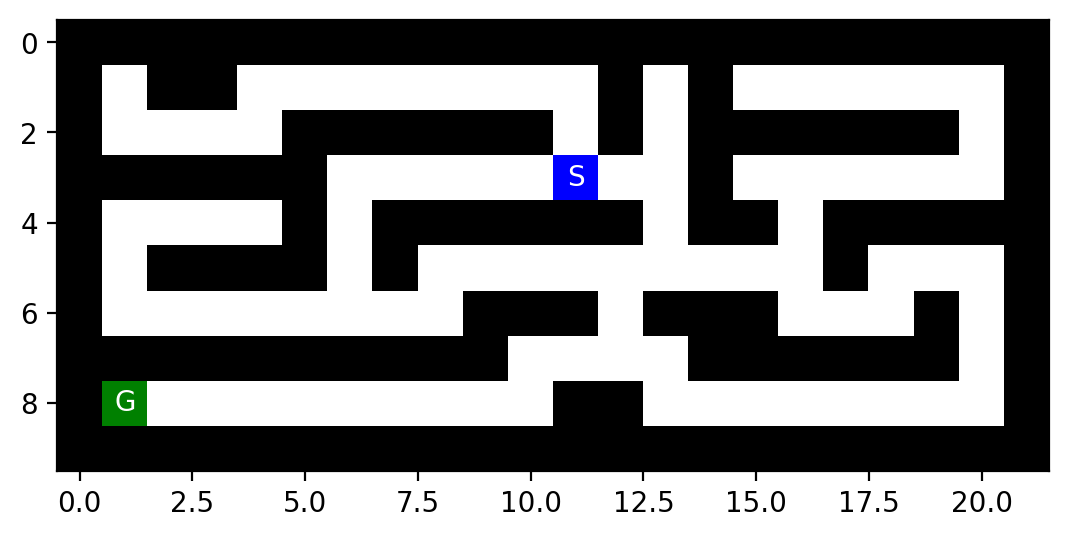

In [15]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [16]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (3, 11)
Goal location: (8, 1)


Helper function documentation.

In [17]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment by Michael Hahsler
    Usage: 
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        Build an animation from a list of mazes. Assumes that results has the elements:
        path, reached, actions and maze_anim with a list of maze arrays.
    
    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one. 
        Caution: there is no error checking!
        
        Parameters:
        maze: a array with characters prodced by parse_maze()
        what: the letter to be found ('S' for start and 'G' for goal)
        
        Returns:
        a tupple (x, y) for the found position.
    
    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).
    
    maze_to_matrix(maze)
        convert a maze a numeric numpy array for visualization via imshow.
    
 

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## Tree structure

Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [18]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)

        path.reverse()

        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the
    - [small maze](small_maze.txt),
    - [medium maze](medium_maze.txt),
    - [large maze](large_maze.txt),
    - [open maze](open_maze.txt),
    - [wall maze](wall_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty 2_maze](empty_2_maze.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate.

*Note:* You can swich the next block from code to Markdown and use formating.

In [19]:
# Your answer goes here
# Initial State - The initial state represents the starting position of the agent in the maze.
# It is denoted by the variable 'startCoordinates', which marks the point from which the agent begins navigation.

# Actions - The actions define the possible moves an agent can take within the environment.
# In this maze scenario, the actions are represented as:
# actions = {"north": (-1,0), "south": (1,0), "east": (0,1), "west": (0,-1)}
# These movements allow the agent to navigate through the maze.

# Transition Model - The transition model describes how the agent moves to a new position when an action is performed.
# In this scenario, it is defined by the 'frontier' variable, which stores the node containing the updated position
# after applying an action.

# Goal State - The goal state represents the final target location that the agent must reach in the maze.
# It is identified by the variable 'goalCoordinates', which marks the endpoint of the agent’s journey.

# Path Cost - Path cost refers to the total cost incurred by the agent while transitioning from the initial state
# to the goal state. It measures the effort required to navigate the maze, often represented as the number of moves
# or a weighted cost assigned to each step.


Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determin these values for a given maze.

In [ ]:
# Your answer goes here
# State Space Size - This defines the overall size of the maze and is determined by the variable 'treeSize'.
# It represents the total number of possible states the agent can explore within the maze.

# Maximum Depth of Tree - This indicates the deepest level that the search algorithm will explore.
# It is represented by the variable 'maxDepth' in our code.

# Maximum Branching Factor - This denotes the highest number of child nodes that a single node can have in the search tree.
# In our implementation, it is represented by the variable 'maxBranchingFactor'.


## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking.
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



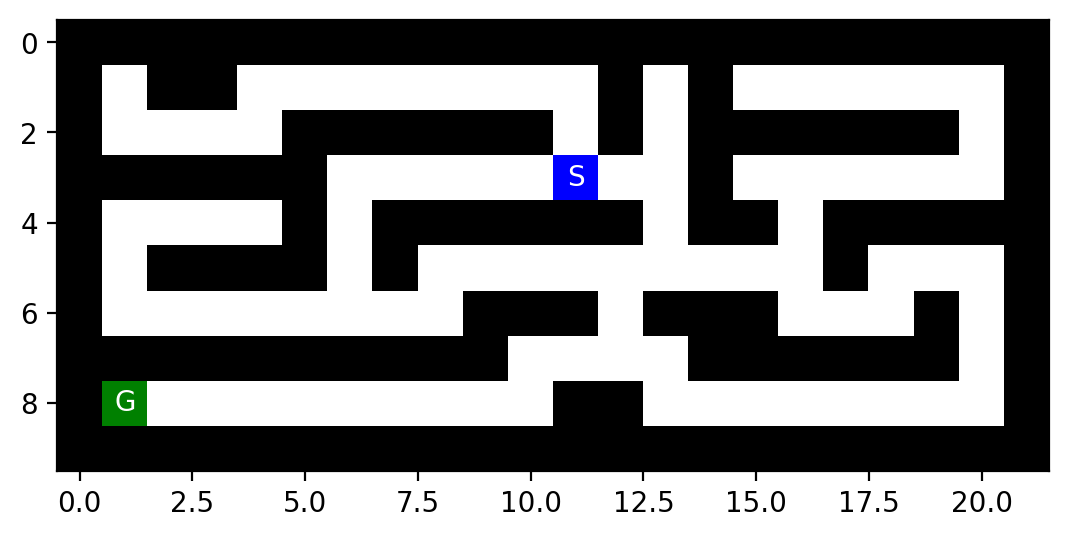

The Maximum Frontier Size is 9
The Maximum Depth of the tree is 19
The cost for the Path is 19
The Maximum tree size is 96
The maximum Branching Factor is  94
Path from origin to target:
(3, 11)
(3, 12)
(3, 13)
(4, 13)
(5, 13)
(5, 12)
(6, 12)
(7, 12)
(7, 11)
(7, 10)
(8, 10)
(8, 9)
(8, 8)
(8, 7)
(8, 6)
(8, 5)
(8, 4)
(8, 3)
(8, 2)
(8, 1)
Cost: 19


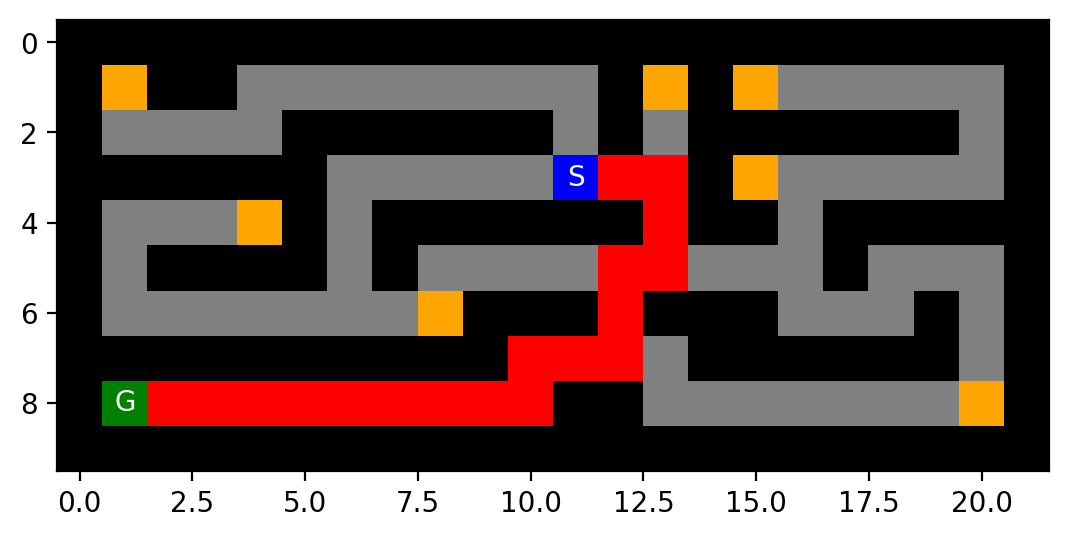

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X                                 SX
X XXXXXXXXXXXXXXXXXXXXXXX XXXXXXXX X
X XX   X   X      XXXXXXX   XX     X
X XX X X X X XXXX XXXXXXXXX XX XXXXX
X XX X X X X             XX XX     X
X XX X X X X X XXXX  XXX    XXXXXX X
X X  X X X   X    XX XXXXXXXX      X
X XX X X XXXXXXXX XX        XX XXXXX
X XX X   XX       XXXXXXXXX XX     X
X    XXXXXX XXXXXXX      XX XXXXXX X
XXXXXX      X       XXXX XX X      X
X      XXXXXX XXXXX X    XX XX XXXXX
X XXXXXX      X       XXXXX XX     X
X        XXXXXX XXXXXXXXXXX XX  XX X
XXXXXXXXXX                  XXXXXX X
XG         XXXXXXXXXXXXXXXX        X
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX




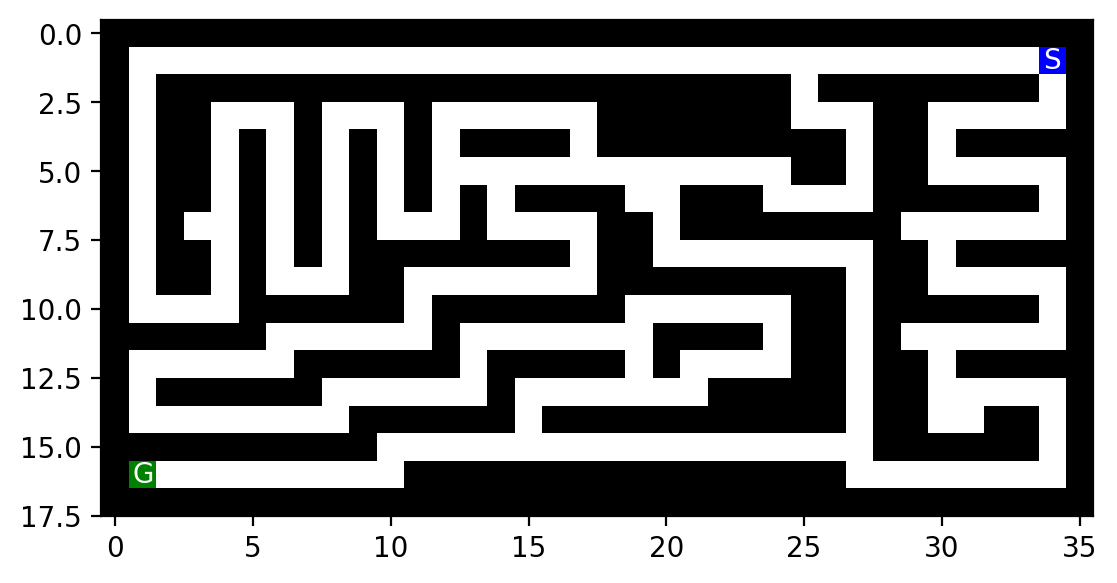

The Maximum Frontier Size is 9
The Maximum Depth of the tree is 68
The cost for the Path is 68
The Maximum tree size is 278
The maximum Branching Factor is  275
Path from origin to target:
(1, 34)
(1, 33)
(1, 32)
(1, 31)
(1, 30)
(1, 29)
(1, 28)
(1, 27)
(1, 26)
(1, 25)
(2, 25)
(3, 25)
(3, 26)
(3, 27)
(4, 27)
(5, 27)
(6, 27)
(6, 26)
(6, 25)
(6, 24)
(5, 24)
(5, 23)
(5, 22)
(5, 21)
(5, 20)
(6, 20)
(7, 20)
(8, 20)
(8, 21)
(8, 22)
(8, 23)
(8, 24)
(8, 25)
(8, 26)
(8, 27)
(9, 27)
(10, 27)
(11, 27)
(12, 27)
(13, 27)
(14, 27)
(15, 27)
(15, 26)
(15, 25)
(15, 24)
(15, 23)
(15, 22)
(15, 21)
(15, 20)
(15, 19)
(15, 18)
(15, 17)
(15, 16)
(15, 15)
(15, 14)
(15, 13)
(15, 12)
(15, 11)
(15, 10)
(16, 10)
(16, 9)
(16, 8)
(16, 7)
(16, 6)
(16, 5)
(16, 4)
(16, 3)
(16, 2)
(16, 1)
Cost: 68


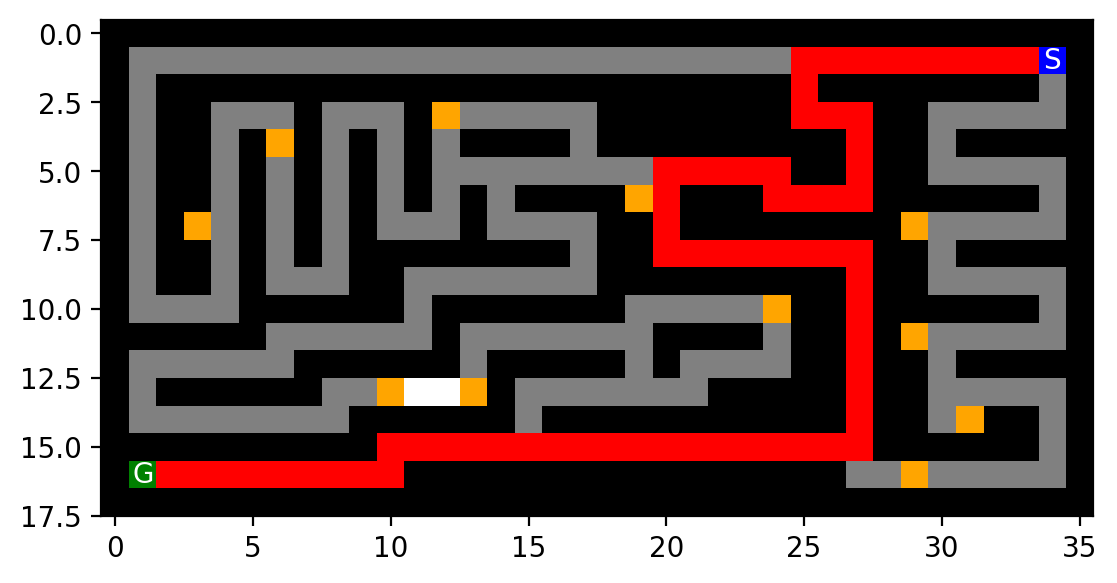

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X       X X X           X   X     X X
X XXXXXXX X XXX X XXX XXX XXXXXXX X X
X       X       X X     X     X X   X
XXXXX XXXXX XXX X X X XXX XXXXX X XXX
X   X X X X   X X X X   X X   X X   X
X XXX X X X XXX XXXXX XXX X XXX XXX X
X       X     X   X   X     X X X   X
XXX XXXXXXXXX XXXXXXX XXX XXX X X X X
X             X       X X   X     X X
X X XXXXX X XXX X X XXX X XXX XXX X X
X X X     X X X X X     X   X X X X X
X X X XXXXXXX X XXXXXXXXX XXX X XXX X
X X X X     X   X     X     X   X   X
XXX XXX X XXXXX XXXXX XXX XXX XXXXX X
X     X X X     X X     X X   X X X X
X X X X X XXX XXX XXX XXX X X X X X X
X X X X X                 X X X     X
XXX XXXXXXX X X XXXXX XXX X XXX XXXXX
X       X X X X     X   X     X X   X
XXXXX X X XXXXXXXXX XXXXXXXXXXX X XXX
X   X X           X X     X   X X   X
X XXX XXXXX XXXXXXXXX XXXXX X X XXX X
X X   X      X        X     X       X
X X X XXXXX XXX X X X X XXXXXXXXXXXXX
X X X   X     X X X X       X   X X X
X X XXX XXX 

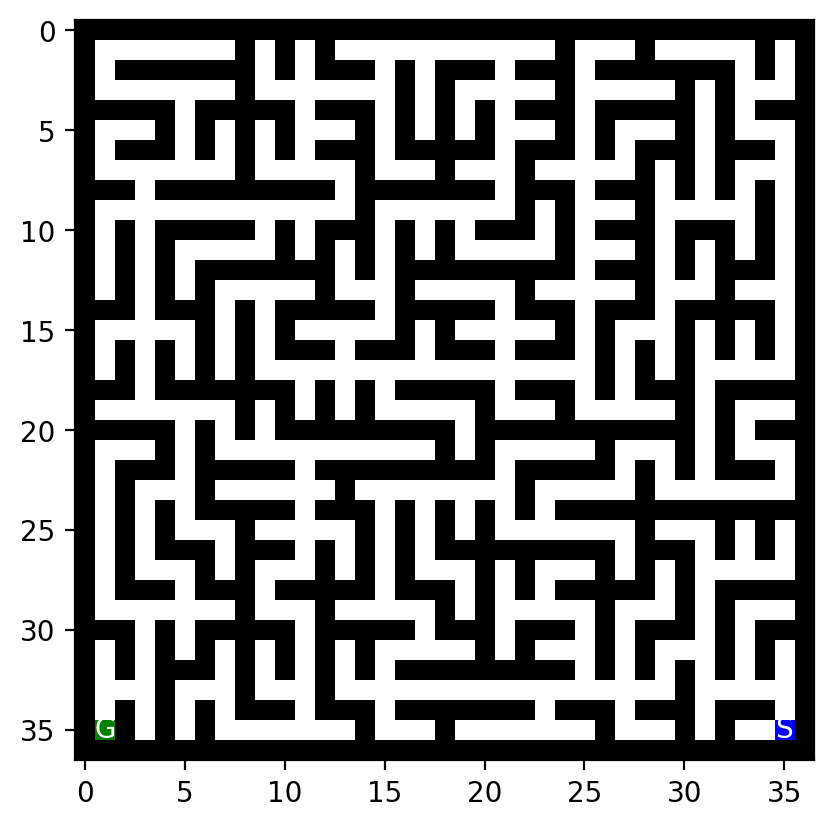

The Maximum Frontier Size is 8
The Maximum Depth of the tree is 210
The cost for the Path is 210
The Maximum tree size is 623
The maximum Branching Factor is  620
Path from origin to target:
(35, 35)
(34, 35)
(33, 35)
(33, 34)
(33, 33)
(33, 32)
(33, 31)
(32, 31)
(31, 31)
(31, 30)
(31, 29)
(32, 29)
(33, 29)
(33, 28)
(33, 27)
(33, 26)
(33, 25)
(33, 24)
(33, 23)
(33, 22)
(33, 21)
(33, 20)
(33, 19)
(33, 18)
(33, 17)
(33, 16)
(33, 15)
(32, 15)
(31, 15)
(31, 16)
(31, 17)
(30, 17)
(29, 17)
(29, 16)
(29, 15)
(28, 15)
(27, 15)
(26, 15)
(25, 15)
(24, 15)
(23, 15)
(23, 16)
(23, 17)
(23, 18)
(23, 19)
(23, 20)
(23, 21)
(24, 21)
(25, 21)
(25, 22)
(25, 23)
(24, 23)
(23, 23)
(23, 24)
(23, 25)
(23, 26)
(23, 27)
(22, 27)
(21, 27)
(21, 28)
(21, 29)
(22, 29)
(23, 29)
(23, 30)
(23, 31)
(22, 31)
(21, 31)
(20, 31)
(19, 31)
(18, 31)
(17, 31)
(17, 32)
(17, 33)
(17, 34)
(17, 35)
(16, 35)
(15, 35)
(14, 35)
(13, 35)
(12, 35)
(11, 35)
(10, 35)
(9, 35)
(8, 35)
(7, 35)
(7, 34)
(7, 33)
(8, 33)
(9, 33)
(9, 32)
(9, 31)

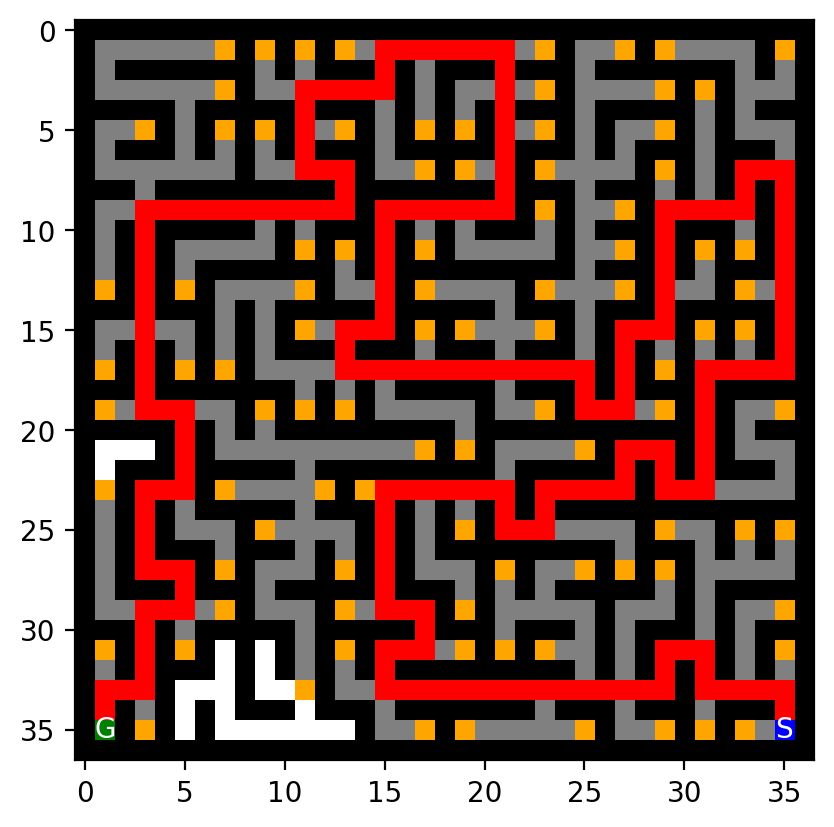

XXXXXXXXXXXX
XG         X
X        X X
XXXXXXXX X X
X      X X X
X    X X X X
X    X X   X
X    X X X X
X    X X X X
XXXX X X X X
XS         X
XXXXXXXXXXXX



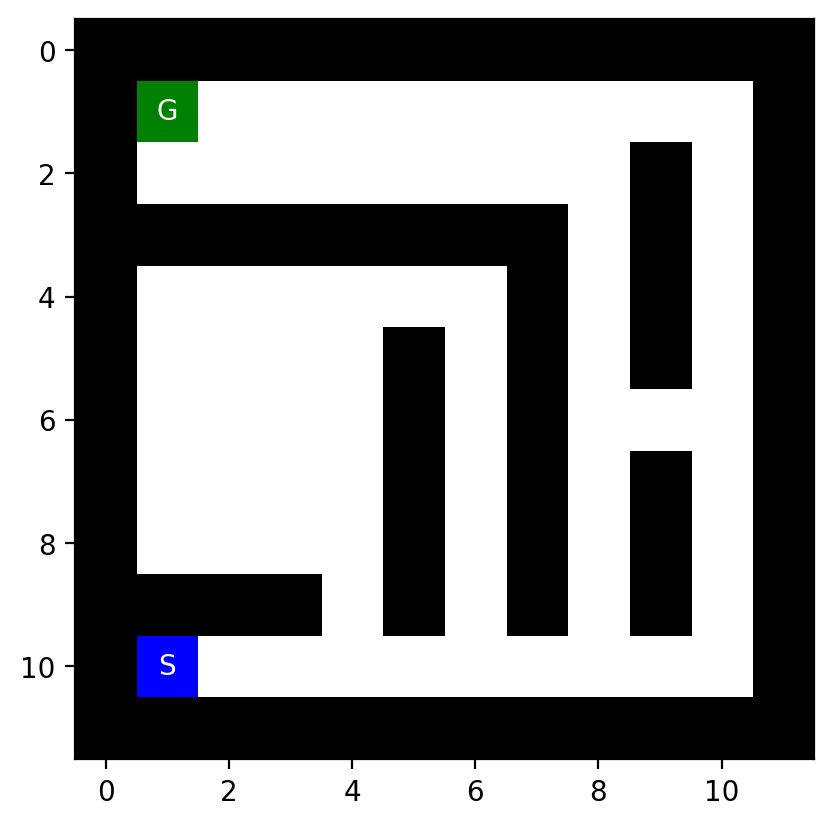

The Maximum Frontier Size is 39
The Maximum Depth of the tree is 23
The cost for the Path is 23
The Maximum tree size is 213
The maximum Branching Factor is  205
Path from origin to target:
(10, 1)
(10, 2)
(10, 3)
(10, 4)
(10, 5)
(10, 6)
(10, 7)
(10, 8)
(9, 8)
(8, 8)
(7, 8)
(6, 8)
(5, 8)
(4, 8)
(3, 8)
(2, 8)
(1, 8)
(1, 7)
(1, 6)
(1, 5)
(1, 4)
(1, 3)
(1, 2)
(1, 1)
Cost: 23


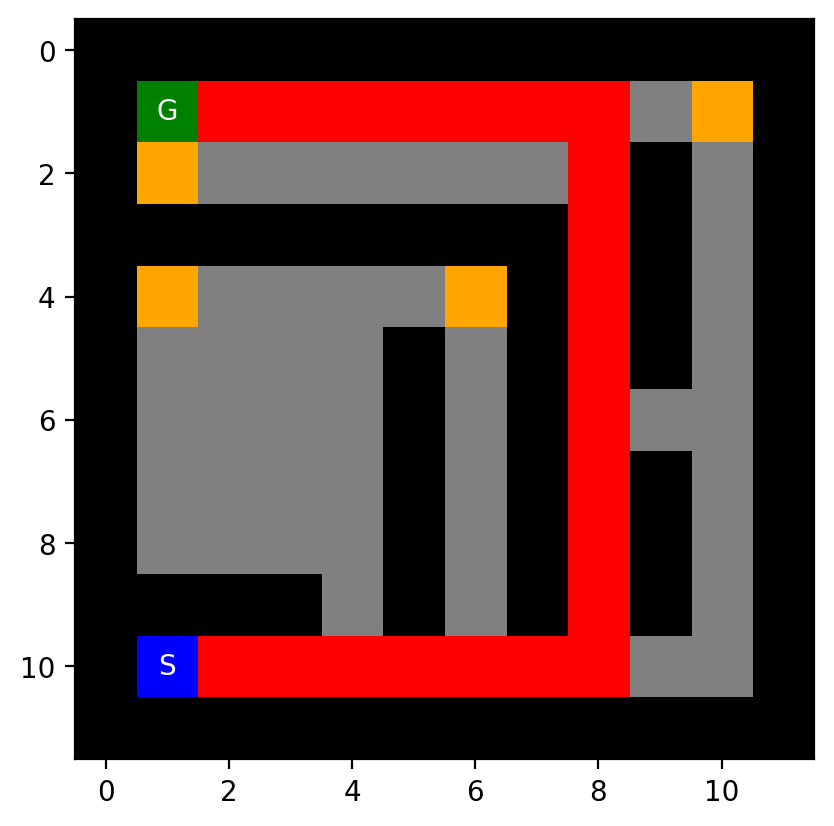

XXXXXXXXXXXX
X          X
X        G X
X          X
X   XXXX   X
X      X   X
X      X   X
X      X   X
X          X
X S        X
X          X
XXXXXXXXXXXX



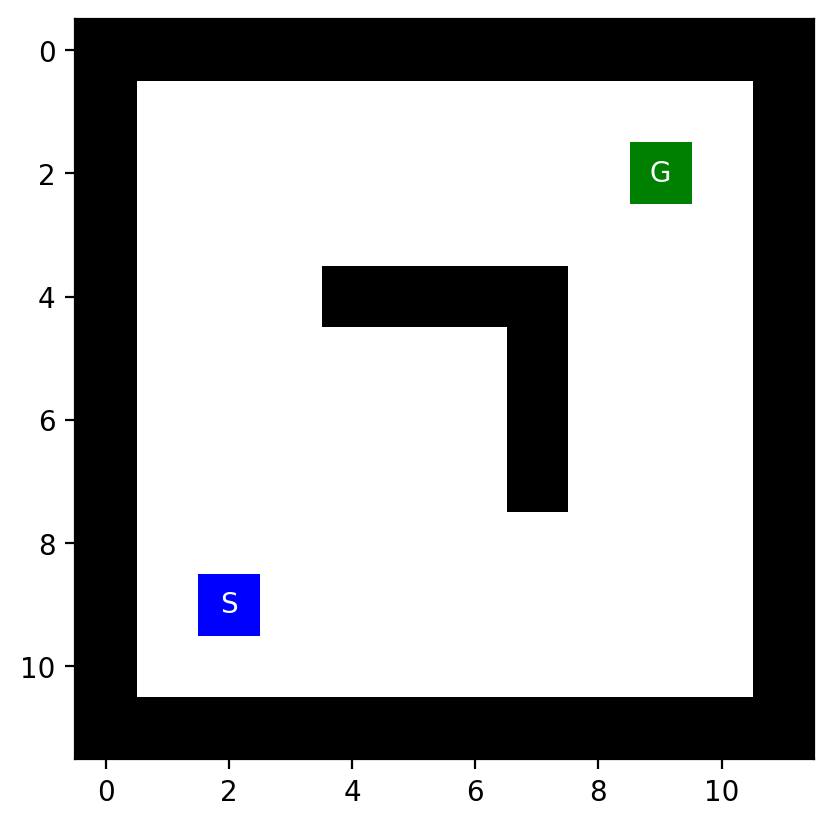

The Maximum Frontier Size is 422
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 1726
The maximum Branching Factor is  1304
Path from origin to target:
(9, 2)
(8, 2)
(7, 2)
(6, 2)
(5, 2)
(4, 2)
(3, 2)
(2, 2)
(2, 3)
(2, 4)
(2, 5)
(2, 6)
(2, 7)
(2, 8)
(2, 9)
Cost: 14


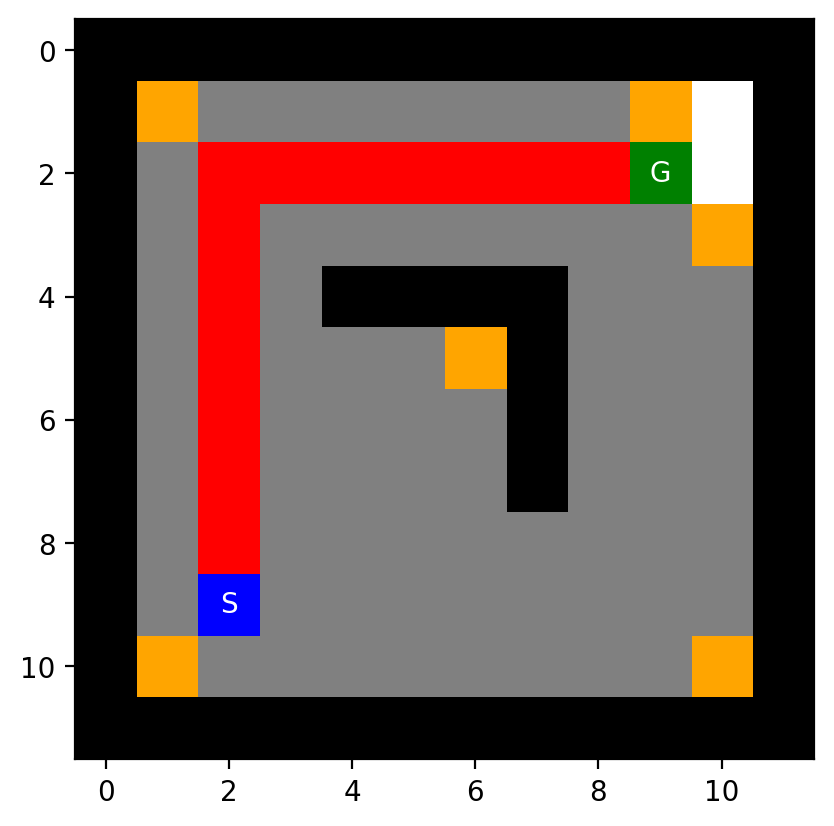

XXXXXXXXXXXX
X          X
X        G X
X          X
X          X
X          X
X          X
X          X
X          X
X S        X
X          X
XXXXXXXXXXXX



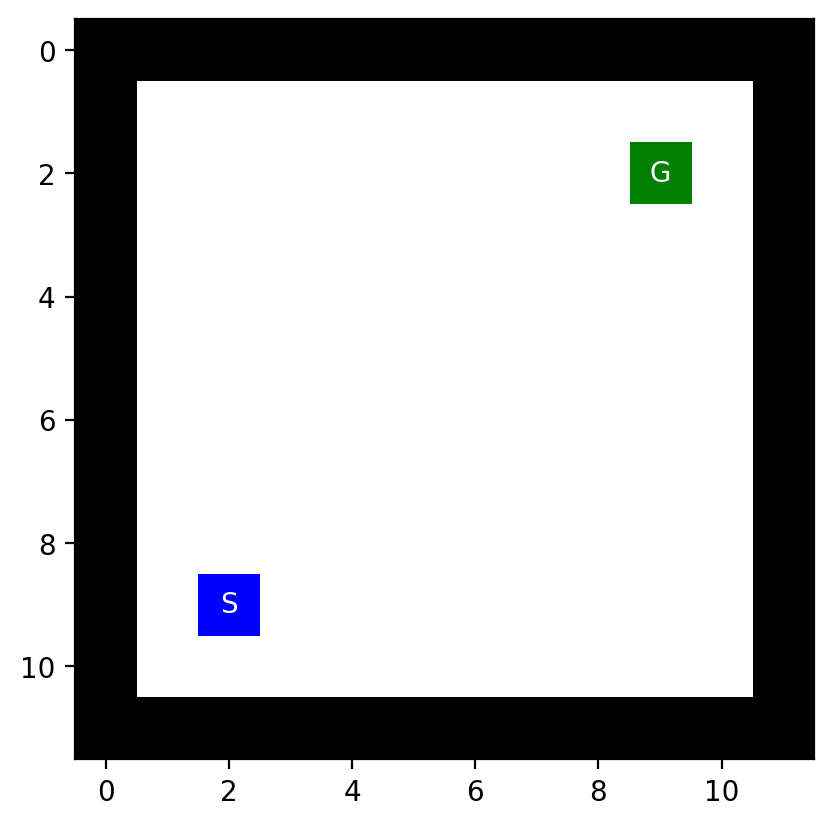

The Maximum Frontier Size is 9438
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 22978
The maximum Branching Factor is  13540
Path from origin to target:
(9, 2)
(8, 2)
(7, 2)
(6, 2)
(5, 2)
(4, 2)
(3, 2)
(2, 2)
(2, 3)
(2, 4)
(2, 5)
(2, 6)
(2, 7)
(2, 8)
(2, 9)
Cost: 14


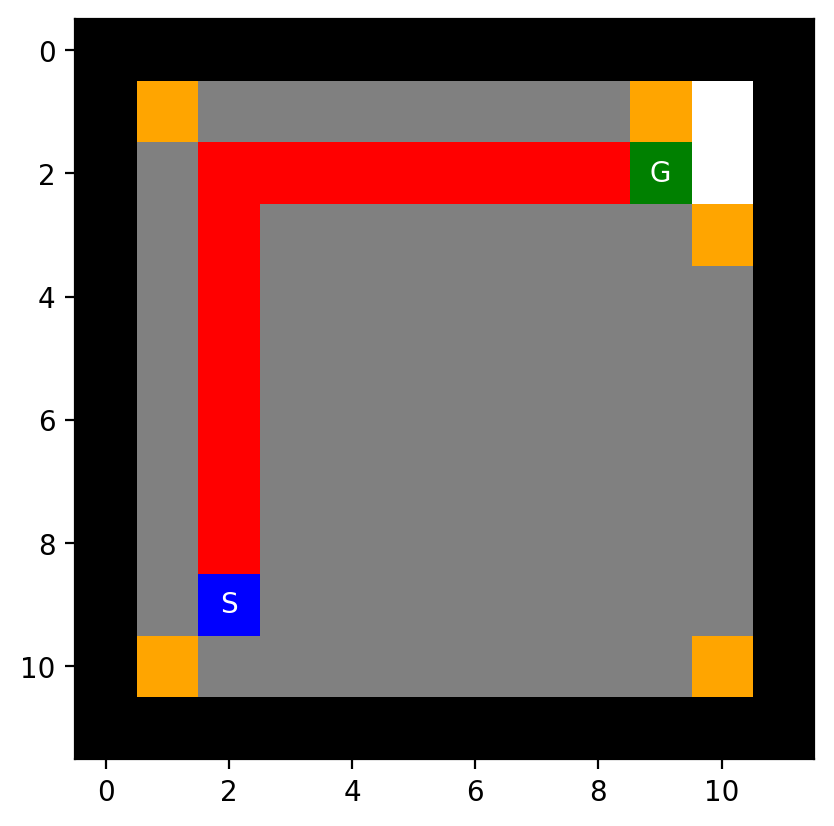

XXXXXXXXXXXX
X          X
X        S X
X          X
X          X
X          X
X          X
X          X
X          X
X G        X
X          X
XXXXXXXXXXXX



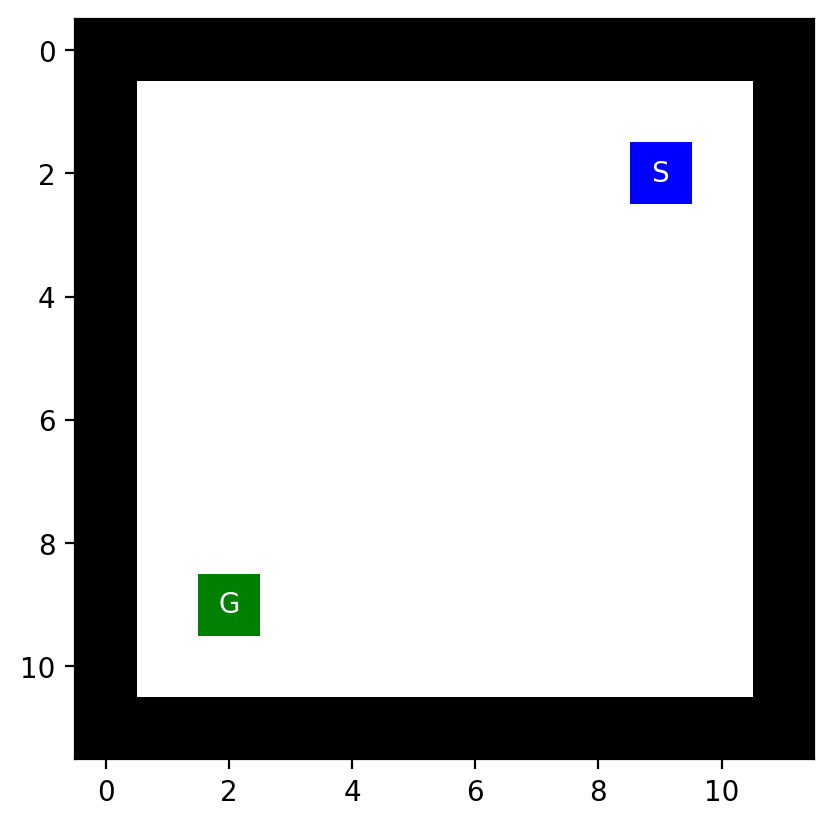

The Maximum Frontier Size is 9438
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 22978
The maximum Branching Factor is  13540
Path from origin to target:
(2, 9)
(3, 9)
(4, 9)
(5, 9)
(6, 9)
(7, 9)
(8, 9)
(9, 9)
(9, 8)
(9, 7)
(9, 6)
(9, 5)
(9, 4)
(9, 3)
(9, 2)
Cost: 14


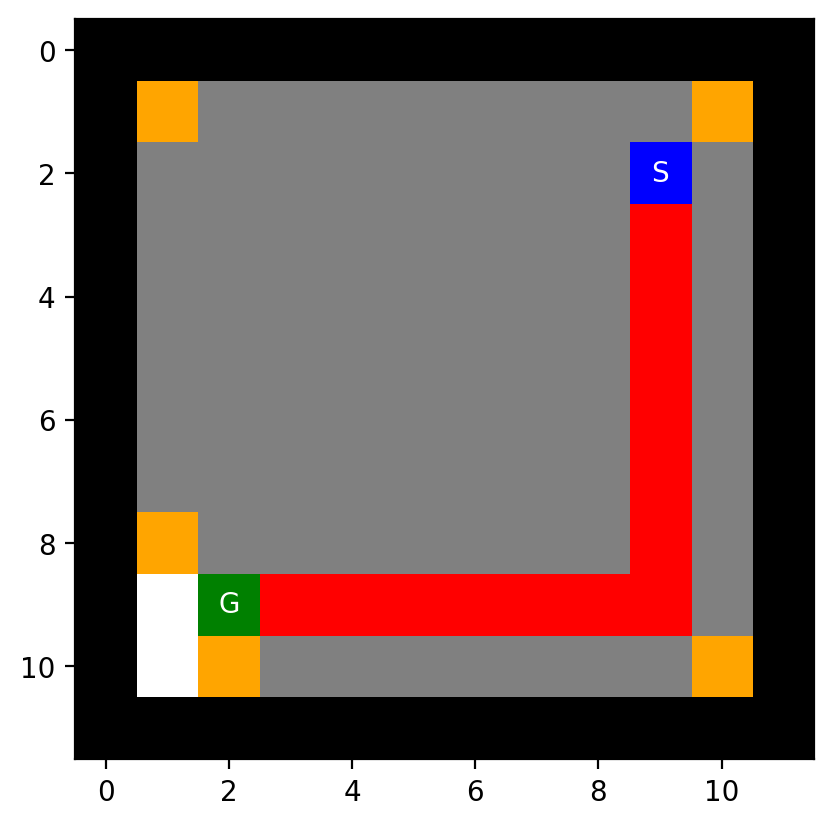

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



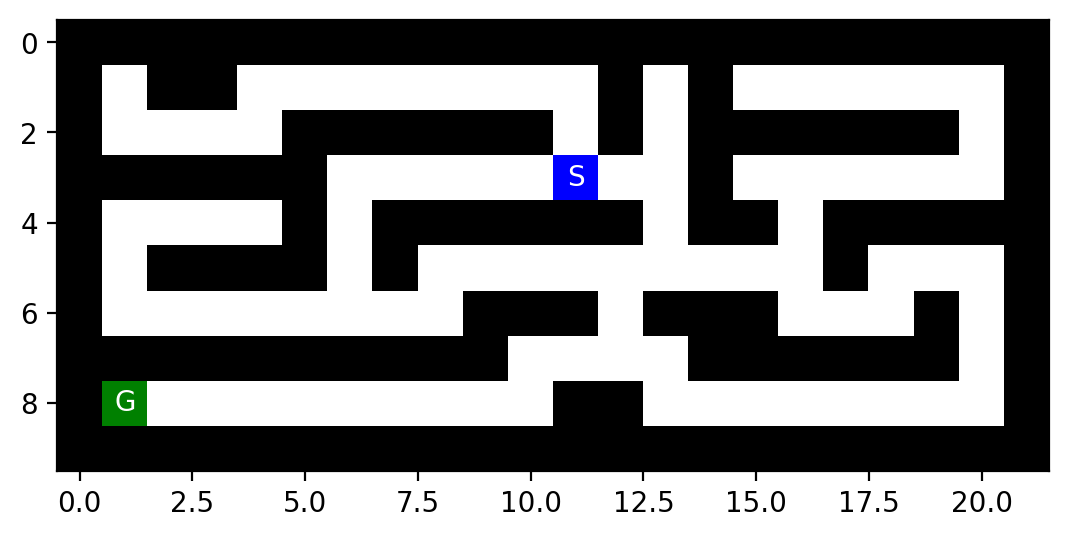

The Maximum Frontier Size is 7
The Maximum Depth of the tree is 49
The cost for the Path is 49
The Maximum tree size is 66
The maximum Branching Factor is  59
Path from origin to target:
(3, 11)
(3, 10)
(3, 9)
(3, 8)
(3, 7)
(3, 6)
(4, 6)
(5, 6)
(6, 6)
(6, 7)
(6, 8)
(5, 8)
(5, 9)
(5, 10)
(5, 11)
(5, 12)
(5, 13)
(5, 14)
(5, 15)
(5, 16)
(6, 16)
(6, 17)
(6, 18)
(5, 18)
(5, 19)
(5, 20)
(6, 20)
(7, 20)
(8, 20)
(8, 19)
(8, 18)
(8, 17)
(8, 16)
(8, 15)
(8, 14)
(8, 13)
(7, 13)
(7, 12)
(7, 11)
(7, 10)
(8, 10)
(8, 9)
(8, 8)
(8, 7)
(8, 6)
(8, 5)
(8, 4)
(8, 3)
(8, 2)
(8, 1)
Cost: 49


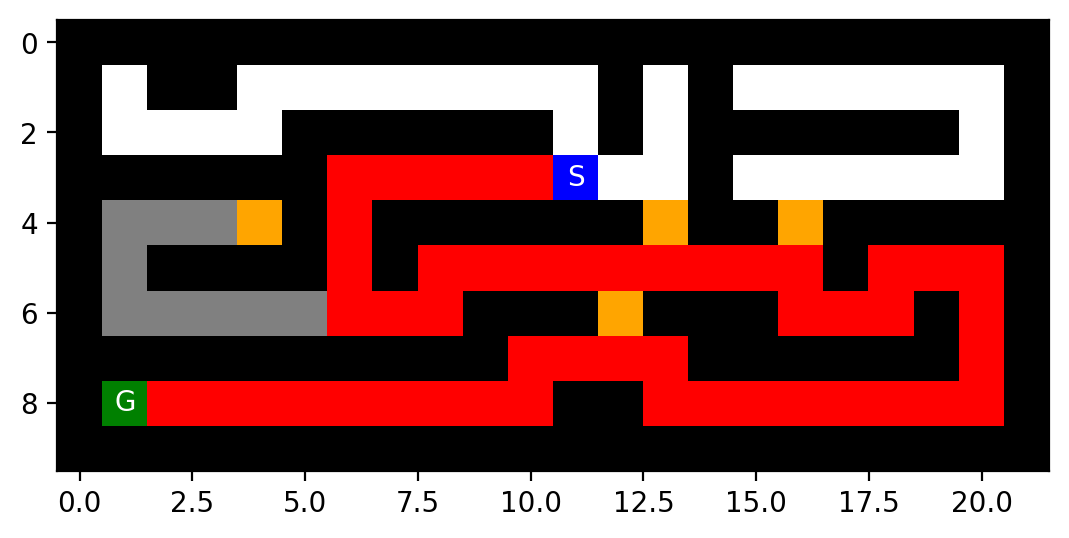

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X                                 SX
X XXXXXXXXXXXXXXXXXXXXXXX XXXXXXXX X
X XX   X   X      XXXXXXX   XX     X
X XX X X X X XXXX XXXXXXXXX XX XXXXX
X XX X X X X             XX XX     X
X XX X X X X X XXXX  XXX    XXXXXX X
X X  X X X   X    XX XXXXXXXX      X
X XX X X XXXXXXXX XX        XX XXXXX
X XX X   XX       XXXXXXXXX XX     X
X    XXXXXX XXXXXXX      XX XXXXXX X
XXXXXX      X       XXXX XX X      X
X      XXXXXX XXXXX X    XX XX XXXXX
X XXXXXX      X       XXXXX XX     X
X        XXXXXX XXXXXXXXXXX XX  XX X
XXXXXXXXXX                  XXXXXX X
XG         XXXXXXXXXXXXXXXX        X
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX




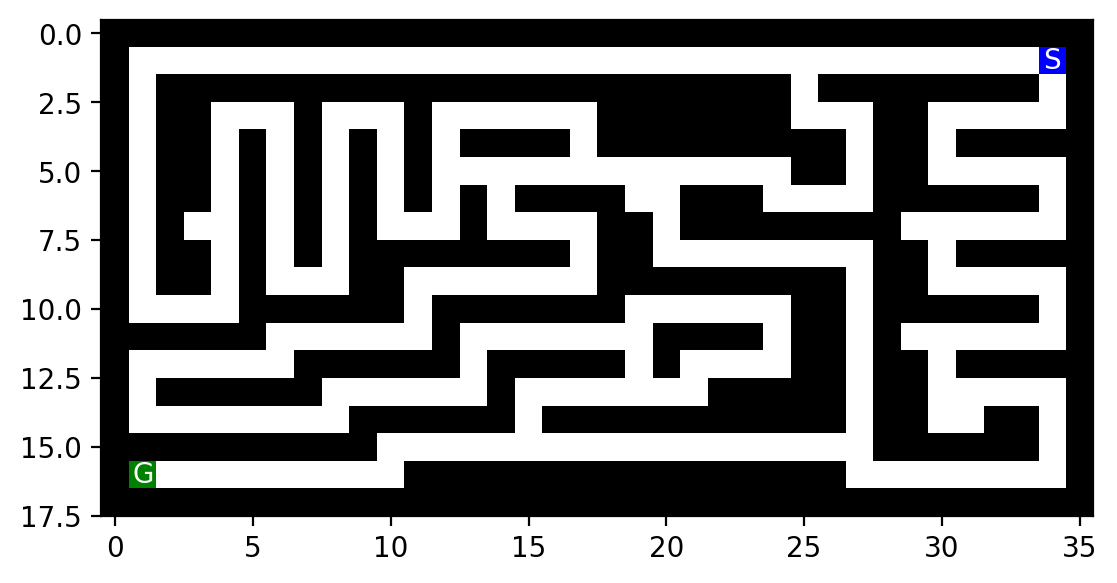

The Maximum Frontier Size is 9
The Maximum Depth of the tree is 130
The cost for the Path is 130
The Maximum tree size is 155
The maximum Branching Factor is  146
Path from origin to target:
(1, 34)
(1, 33)
(1, 32)
(1, 31)
(1, 30)
(1, 29)
(1, 28)
(1, 27)
(1, 26)
(1, 25)
(1, 24)
(1, 23)
(1, 22)
(1, 21)
(1, 20)
(1, 19)
(1, 18)
(1, 17)
(1, 16)
(1, 15)
(1, 14)
(1, 13)
(1, 12)
(1, 11)
(1, 10)
(1, 9)
(1, 8)
(1, 7)
(1, 6)
(1, 5)
(1, 4)
(1, 3)
(1, 2)
(1, 1)
(2, 1)
(3, 1)
(4, 1)
(5, 1)
(6, 1)
(7, 1)
(8, 1)
(9, 1)
(10, 1)
(10, 2)
(10, 3)
(10, 4)
(9, 4)
(8, 4)
(7, 4)
(6, 4)
(5, 4)
(4, 4)
(3, 4)
(3, 5)
(3, 6)
(4, 6)
(5, 6)
(6, 6)
(7, 6)
(8, 6)
(9, 6)
(9, 7)
(9, 8)
(8, 8)
(7, 8)
(6, 8)
(5, 8)
(4, 8)
(3, 8)
(3, 9)
(3, 10)
(4, 10)
(5, 10)
(6, 10)
(7, 10)
(7, 11)
(7, 12)
(6, 12)
(5, 12)
(5, 13)
(5, 14)
(5, 15)
(5, 16)
(5, 17)
(5, 18)
(5, 19)
(5, 20)
(6, 20)
(7, 20)
(8, 20)
(8, 21)
(8, 22)
(8, 23)
(8, 24)
(8, 25)
(8, 26)
(8, 27)
(9, 27)
(10, 27)
(11, 27)
(12, 27)
(13, 27)
(14, 27)
(15, 27)
(15, 26)
(15

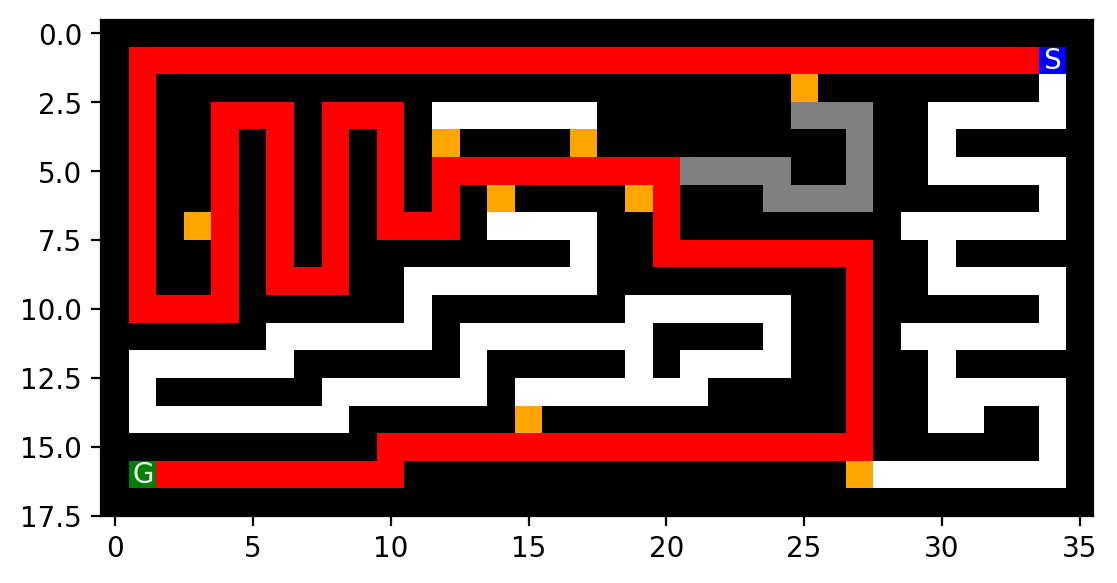

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X       X X X           X   X     X X
X XXXXXXX X XXX X XXX XXX XXXXXXX X X
X       X       X X     X     X X   X
XXXXX XXXXX XXX X X X XXX XXXXX X XXX
X   X X X X   X X X X   X X   X X   X
X XXX X X X XXX XXXXX XXX X XXX XXX X
X       X     X   X   X     X X X   X
XXX XXXXXXXXX XXXXXXX XXX XXX X X X X
X             X       X X   X     X X
X X XXXXX X XXX X X XXX X XXX XXX X X
X X X     X X X X X     X   X X X X X
X X X XXXXXXX X XXXXXXXXX XXX X XXX X
X X X X     X   X     X     X   X   X
XXX XXX X XXXXX XXXXX XXX XXX XXXXX X
X     X X X     X X     X X   X X X X
X X X X X XXX XXX XXX XXX X X X X X X
X X X X X                 X X X     X
XXX XXXXXXX X X XXXXX XXX X XXX XXXXX
X       X X X X     X   X     X X   X
XXXXX X X XXXXXXXXX XXXXXXXXXXX X XXX
X   X X           X X     X   X X   X
X XXX XXXXX XXXXXXXXX XXXXX X X XXX X
X X   X      X        X     X       X
X X X XXXXX XXX X X X X XXXXXXXXXXXXX
X X X   X     X X X X       X   X X X
X X XXX XXX 

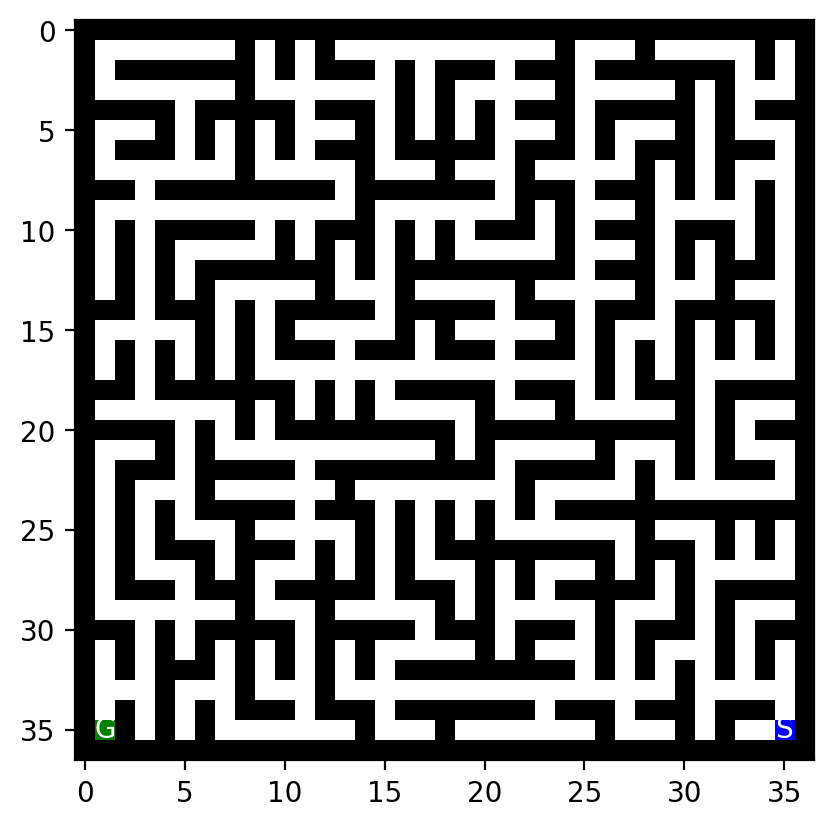

The Maximum Frontier Size is 38
The Maximum Depth of the tree is 222
The cost for the Path is 210
The Maximum tree size is 428
The maximum Branching Factor is  390
Path from origin to target:
(35, 35)
(34, 35)
(33, 35)
(33, 34)
(33, 33)
(33, 32)
(33, 31)
(32, 31)
(31, 31)
(31, 30)
(31, 29)
(32, 29)
(33, 29)
(33, 28)
(33, 27)
(33, 26)
(33, 25)
(33, 24)
(33, 23)
(33, 22)
(33, 21)
(33, 20)
(33, 19)
(33, 18)
(33, 17)
(33, 16)
(33, 15)
(32, 15)
(31, 15)
(31, 16)
(31, 17)
(30, 17)
(29, 17)
(29, 16)
(29, 15)
(28, 15)
(27, 15)
(26, 15)
(25, 15)
(24, 15)
(23, 15)
(23, 16)
(23, 17)
(23, 18)
(23, 19)
(23, 20)
(23, 21)
(24, 21)
(25, 21)
(25, 22)
(25, 23)
(24, 23)
(23, 23)
(23, 24)
(23, 25)
(23, 26)
(23, 27)
(22, 27)
(21, 27)
(21, 28)
(21, 29)
(22, 29)
(23, 29)
(23, 30)
(23, 31)
(22, 31)
(21, 31)
(20, 31)
(19, 31)
(18, 31)
(17, 31)
(17, 32)
(17, 33)
(17, 34)
(17, 35)
(16, 35)
(15, 35)
(14, 35)
(13, 35)
(12, 35)
(11, 35)
(10, 35)
(9, 35)
(8, 35)
(7, 35)
(7, 34)
(7, 33)
(8, 33)
(9, 33)
(9, 32)
(9, 31

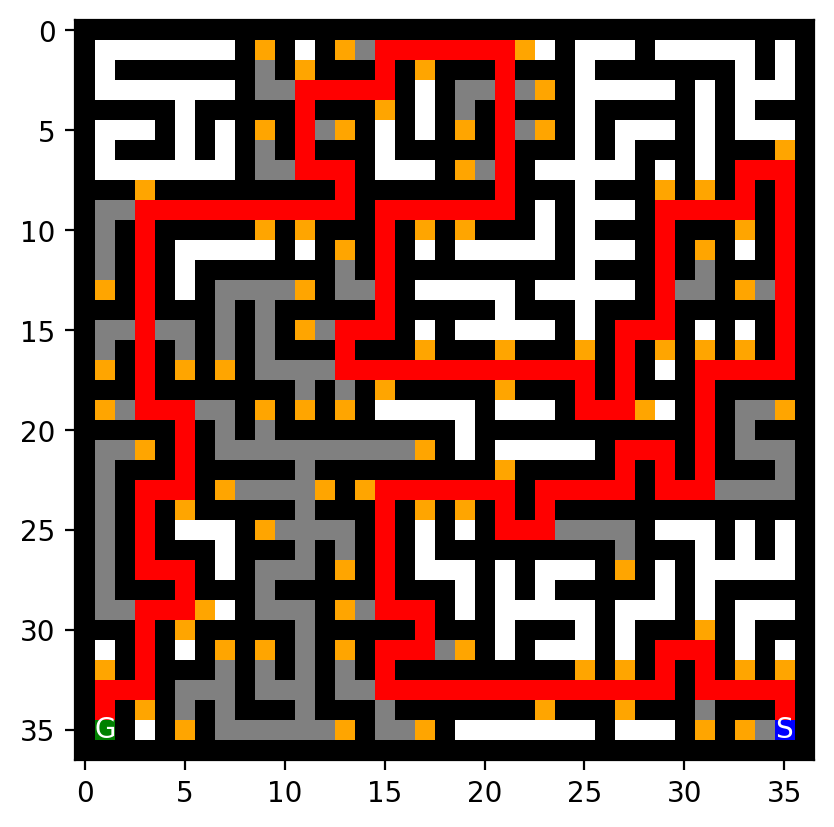

XXXXXXXXXXXX
XG         X
X        X X
XXXXXXXX X X
X      X X X
X    X X X X
X    X X   X
X    X X X X
X    X X X X
XXXX X X X X
XS         X
XXXXXXXXXXXX



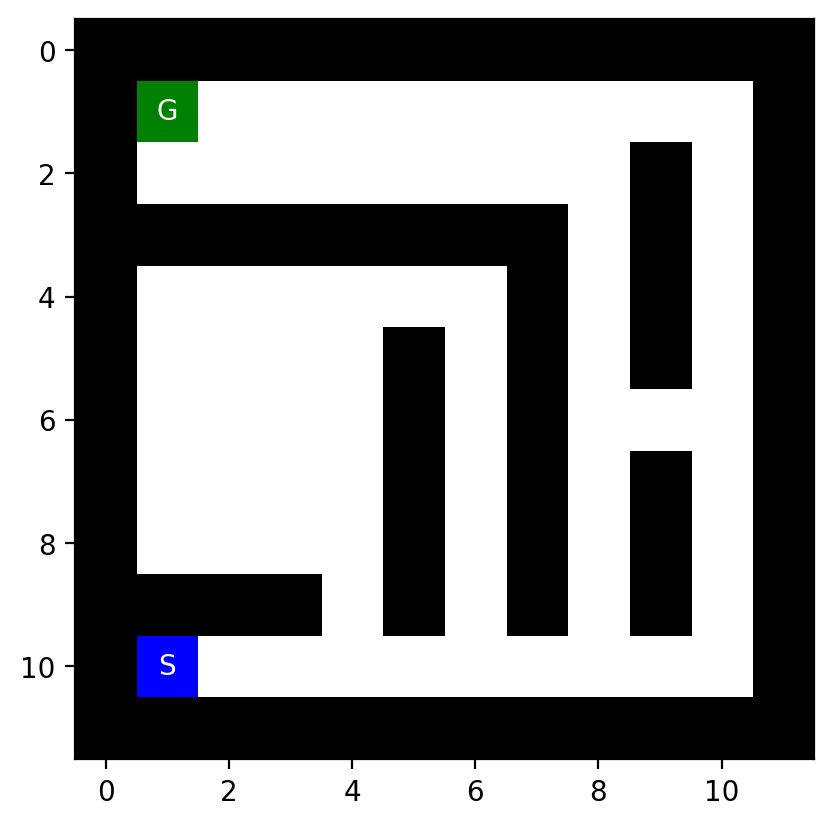

The Maximum Frontier Size is 12
The Maximum Depth of the tree is 27
The cost for the Path is 27
The Maximum tree size is 42
The maximum Branching Factor is  30
Path from origin to target:
(10, 1)
(10, 2)
(10, 3)
(10, 4)
(10, 5)
(10, 6)
(10, 7)
(10, 8)
(10, 9)
(10, 10)
(9, 10)
(8, 10)
(7, 10)
(6, 10)
(6, 9)
(6, 8)
(5, 8)
(4, 8)
(3, 8)
(2, 8)
(2, 7)
(2, 6)
(2, 5)
(2, 4)
(2, 3)
(2, 2)
(2, 1)
(1, 1)
Cost: 27


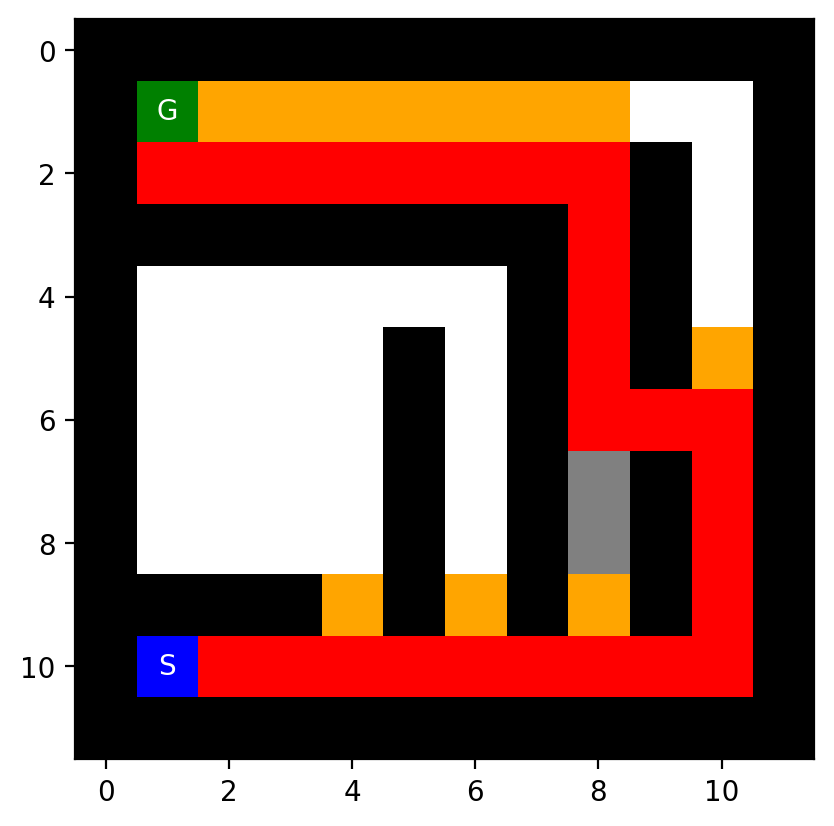

XXXXXXXXXXXX
X          X
X        G X
X          X
X   XXXX   X
X      X   X
X      X   X
X      X   X
X          X
X S        X
X          X
XXXXXXXXXXXX



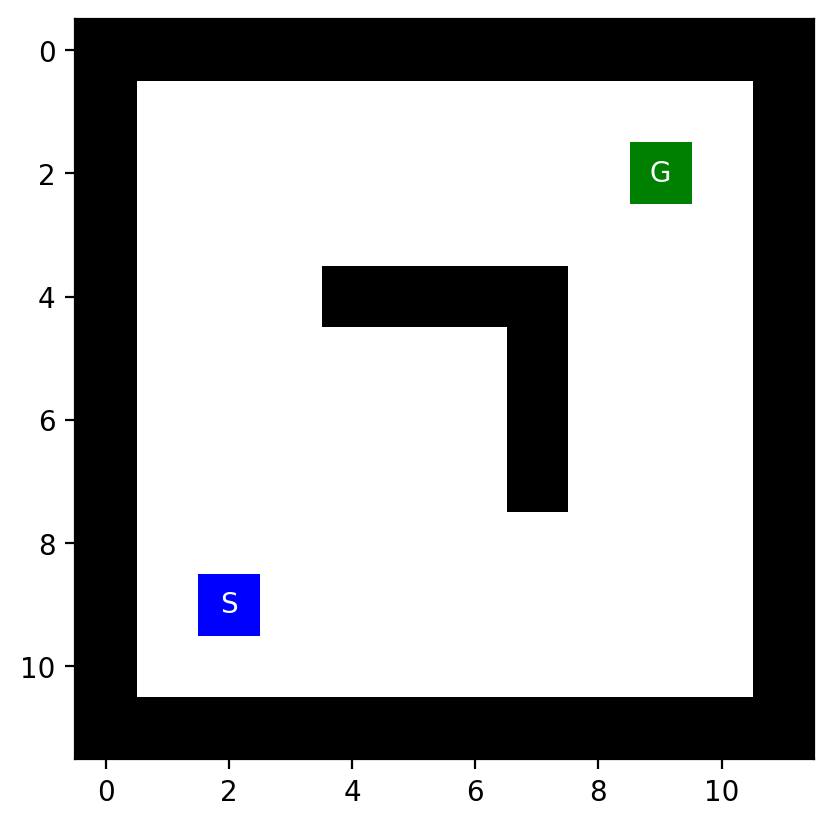

The Maximum Frontier Size is 59
The Maximum Depth of the tree is 70
The cost for the Path is 64
The Maximum tree size is 147
The maximum Branching Factor is  88
Path from origin to target:
(9, 2)
(9, 1)
(10, 1)
(10, 2)
(10, 3)
(10, 4)
(10, 5)
(10, 6)
(10, 7)
(10, 8)
(10, 9)
(10, 10)
(9, 10)
(9, 9)
(9, 8)
(9, 7)
(9, 6)
(9, 5)
(9, 4)
(9, 3)
(8, 3)
(8, 2)
(8, 1)
(7, 1)
(7, 2)
(7, 3)
(7, 4)
(7, 5)
(7, 6)
(8, 6)
(8, 7)
(8, 8)
(8, 9)
(8, 10)
(7, 10)
(7, 9)
(7, 8)
(6, 8)
(6, 9)
(6, 10)
(5, 10)
(5, 9)
(5, 8)
(4, 8)
(4, 9)
(4, 10)
(3, 10)
(3, 9)
(3, 8)
(3, 7)
(3, 6)
(3, 5)
(3, 4)
(3, 3)
(3, 2)
(3, 1)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(2, 5)
(2, 6)
(2, 7)
(2, 8)
(2, 9)
Cost: 64


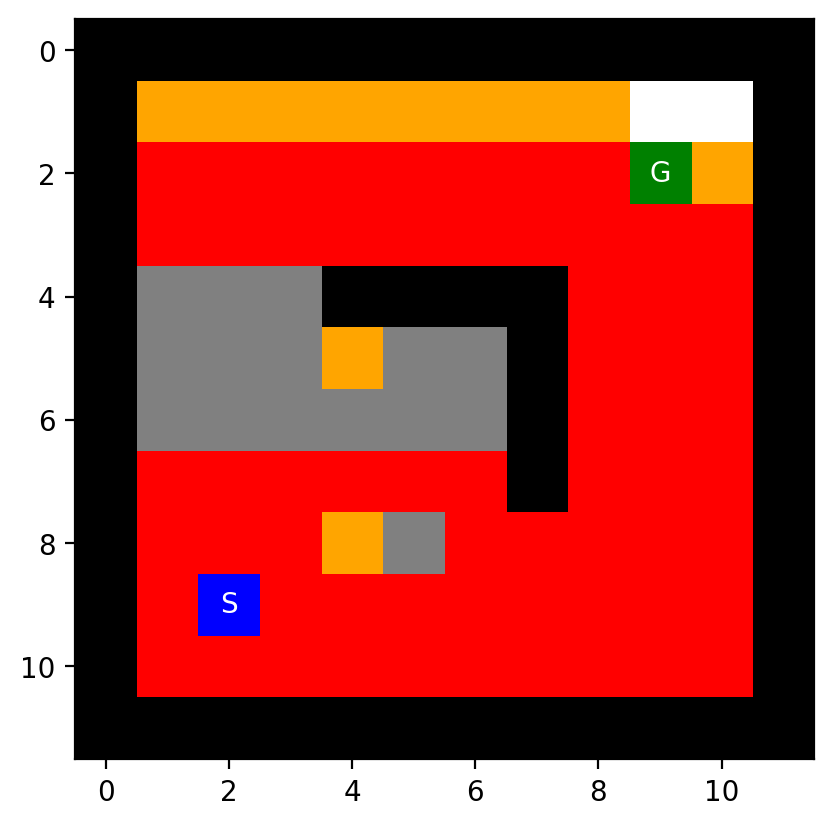

XXXXXXXXXXXX
X          X
X        G X
X          X
X          X
X          X
X          X
X          X
X          X
X S        X
X          X
XXXXXXXXXXXX



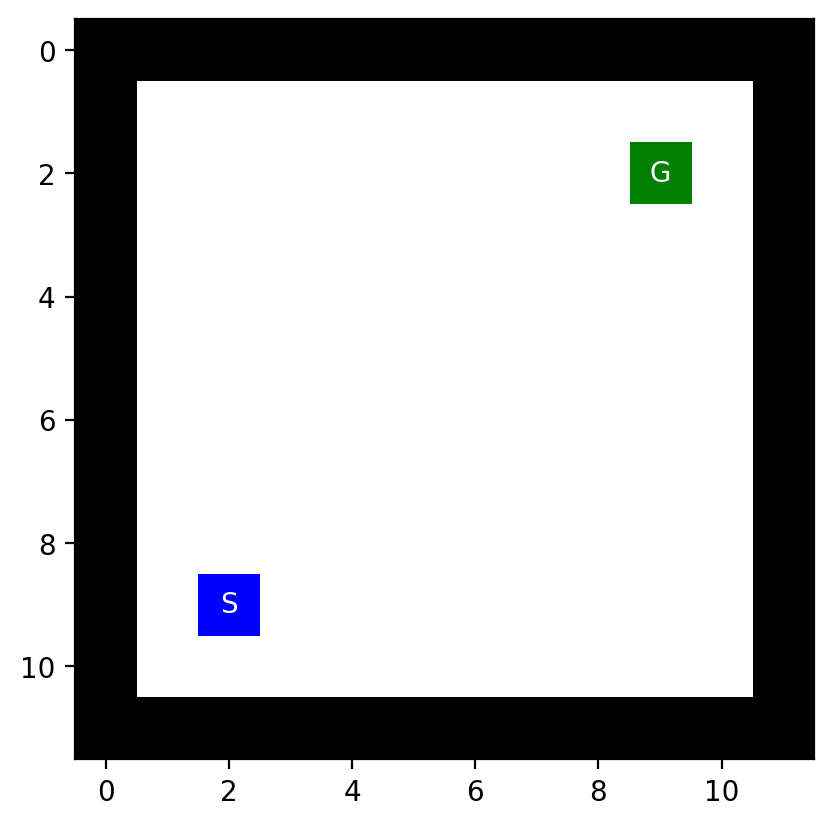

The Maximum Frontier Size is 74
The Maximum Depth of the tree is 74
The cost for the Path is 74
The Maximum tree size is 155
The maximum Branching Factor is  81
Path from origin to target:
(9, 2)
(9, 1)
(10, 1)
(10, 2)
(10, 3)
(10, 4)
(10, 5)
(10, 6)
(10, 7)
(10, 8)
(10, 9)
(10, 10)
(9, 10)
(9, 9)
(9, 8)
(9, 7)
(9, 6)
(9, 5)
(9, 4)
(9, 3)
(8, 3)
(8, 2)
(8, 1)
(7, 1)
(7, 2)
(7, 3)
(7, 4)
(7, 5)
(7, 6)
(7, 7)
(7, 8)
(7, 9)
(7, 10)
(6, 10)
(6, 9)
(6, 8)
(6, 7)
(6, 6)
(6, 5)
(6, 4)
(6, 3)
(6, 2)
(6, 1)
(5, 1)
(5, 2)
(5, 3)
(5, 4)
(5, 5)
(5, 6)
(5, 7)
(5, 8)
(5, 9)
(5, 10)
(4, 10)
(4, 9)
(4, 8)
(4, 7)
(4, 6)
(4, 5)
(4, 4)
(4, 3)
(4, 2)
(4, 1)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(3, 5)
(3, 6)
(3, 7)
(3, 8)
(3, 9)
(3, 10)
(2, 10)
(2, 9)
Cost: 74


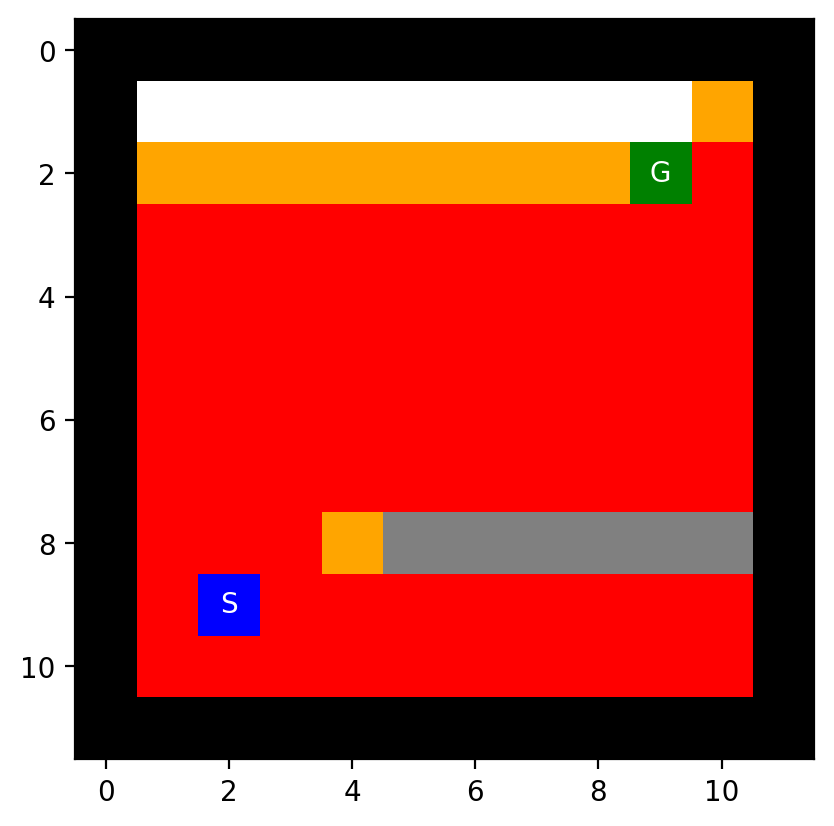

XXXXXXXXXXXX
X          X
X        S X
X          X
X          X
X          X
X          X
X          X
X          X
X G        X
X          X
XXXXXXXXXXXX



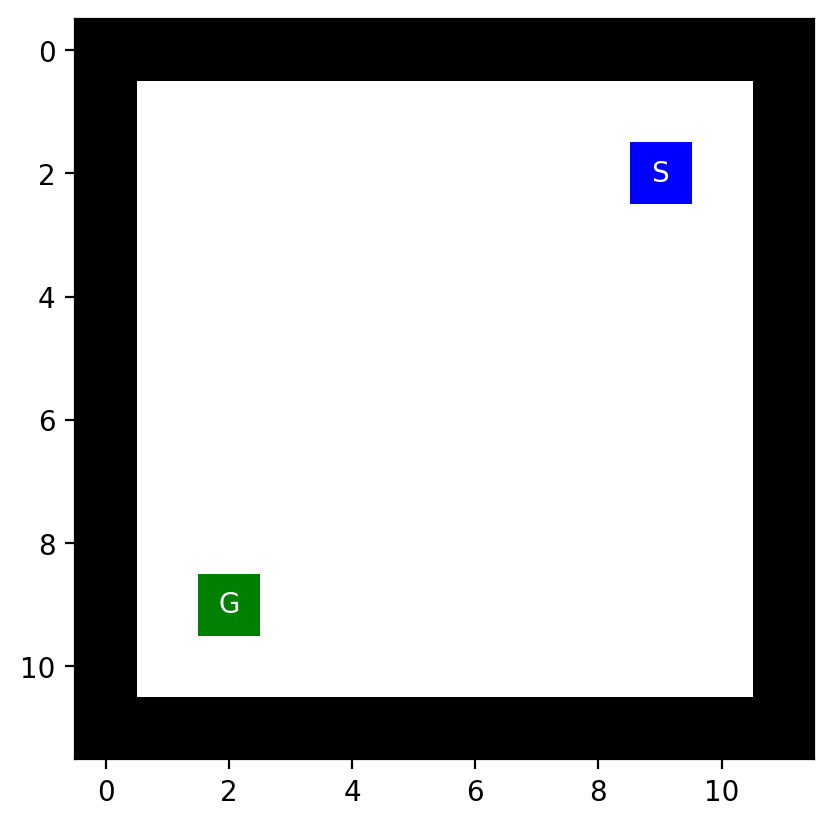

The Maximum Frontier Size is 75
The Maximum Depth of the tree is 70
The cost for the Path is 70
The Maximum tree size is 145
The maximum Branching Factor is  70
Path from origin to target:
(2, 9)
(2, 8)
(2, 7)
(2, 6)
(2, 5)
(2, 4)
(2, 3)
(2, 2)
(2, 1)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(3, 5)
(3, 6)
(3, 7)
(3, 8)
(3, 9)
(3, 10)
(4, 10)
(4, 9)
(4, 8)
(4, 7)
(4, 6)
(4, 5)
(4, 4)
(4, 3)
(4, 2)
(4, 1)
(5, 1)
(5, 2)
(5, 3)
(5, 4)
(5, 5)
(5, 6)
(5, 7)
(5, 8)
(5, 9)
(5, 10)
(6, 10)
(6, 9)
(6, 8)
(6, 7)
(6, 6)
(6, 5)
(6, 4)
(6, 3)
(6, 2)
(6, 1)
(7, 1)
(7, 2)
(7, 3)
(7, 4)
(7, 5)
(7, 6)
(7, 7)
(7, 8)
(7, 9)
(7, 10)
(8, 10)
(8, 9)
(8, 8)
(8, 7)
(8, 6)
(8, 5)
(8, 4)
(8, 3)
(8, 2)
(8, 1)
(9, 1)
(9, 2)
Cost: 70


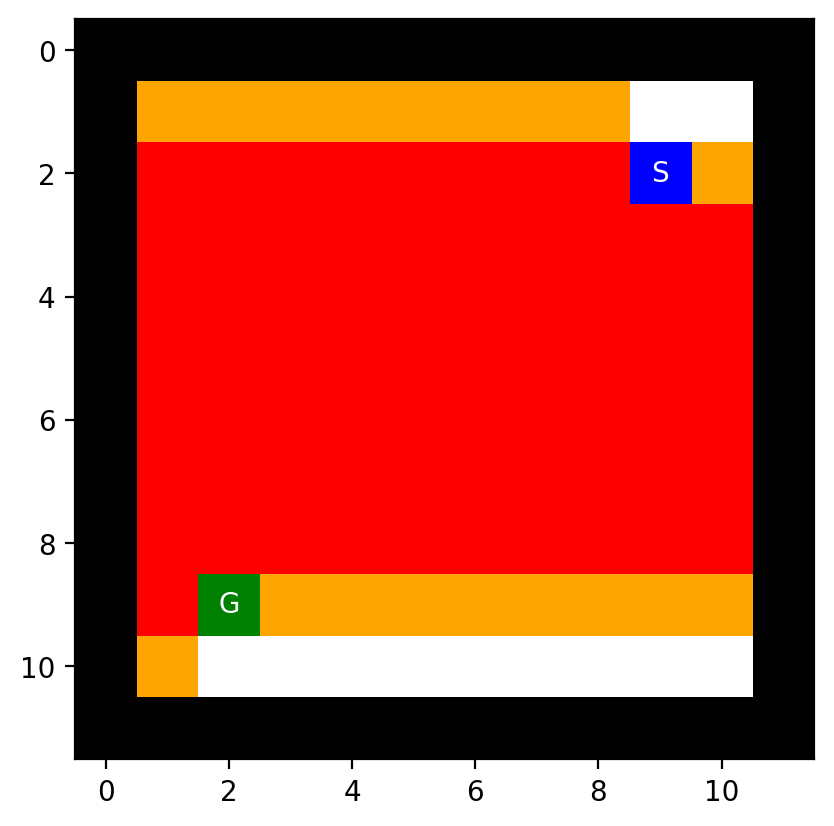

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X                                  SX
X            X                      X
X            X                      X
X            X                      X
X            X                      X
X            X                      X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
XXXXXXXXXXXXXX      XXXXXXXXXXXXXXXXX
X            X                      X
X            X                      X
X            X                      X
X                                   X
X                                   X
X                                   X
XG                                  X
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX



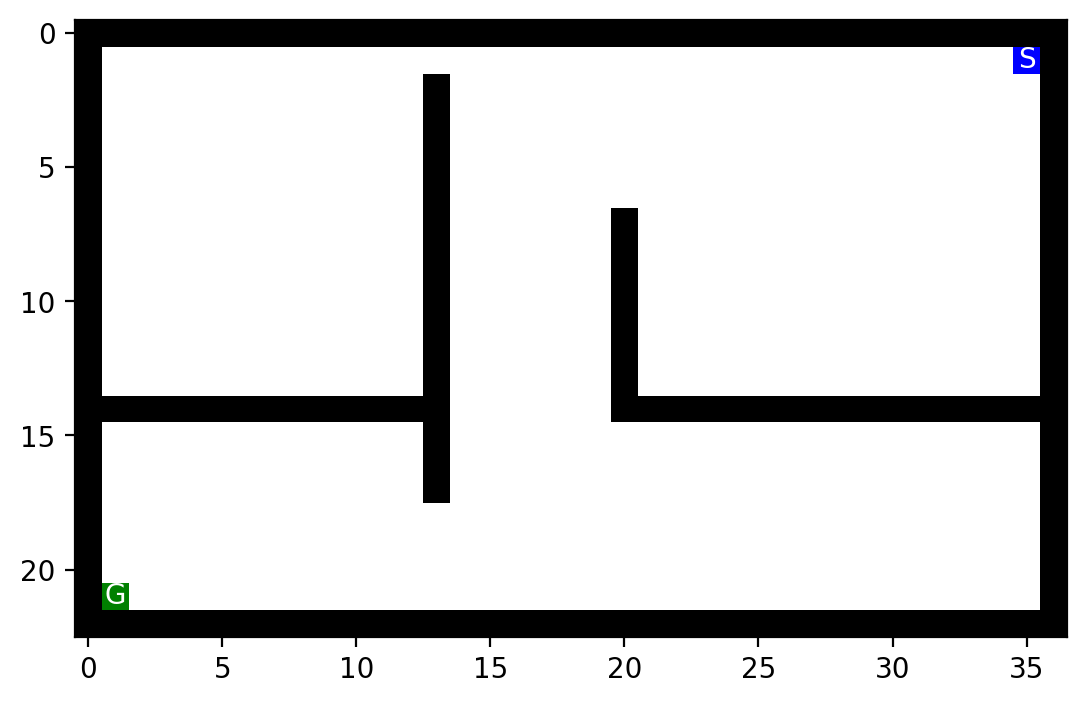

The Maximum Frontier Size is 330
The Maximum Depth of the tree is 298
The cost for the Path is 298
The Maximum tree size is 1136
The maximum Branching Factor is  806
Path from origin to target:
(1, 35)
(1, 34)
(1, 33)
(1, 32)
(1, 31)
(1, 30)
(1, 29)
(1, 28)
(1, 27)
(1, 26)
(1, 25)
(1, 24)
(1, 23)
(1, 22)
(1, 21)
(1, 20)
(1, 19)
(1, 18)
(1, 17)
(1, 16)
(1, 15)
(1, 14)
(2, 14)
(2, 15)
(2, 16)
(2, 17)
(2, 18)
(2, 19)
(2, 20)
(2, 21)
(2, 22)
(2, 23)
(2, 24)
(2, 25)
(2, 26)
(2, 27)
(2, 28)
(2, 29)
(2, 30)
(2, 31)
(2, 32)
(2, 33)
(2, 34)
(2, 35)
(3, 35)
(3, 34)
(3, 33)
(3, 32)
(3, 31)
(3, 30)
(3, 29)
(3, 28)
(3, 27)
(3, 26)
(3, 25)
(3, 24)
(3, 23)
(3, 22)
(3, 21)
(3, 20)
(3, 19)
(3, 18)
(3, 17)
(3, 16)
(3, 15)
(3, 14)
(4, 14)
(4, 15)
(4, 16)
(4, 17)
(4, 18)
(4, 19)
(4, 20)
(4, 21)
(4, 22)
(4, 23)
(4, 24)
(4, 25)
(4, 26)
(4, 27)
(4, 28)
(4, 29)
(4, 30)
(4, 31)
(4, 32)
(4, 33)
(4, 34)
(4, 35)
(5, 35)
(5, 34)
(5, 33)
(5, 32)
(5, 31)
(5, 30)
(5, 29)
(5, 28)
(5, 27)
(5, 26)
(5, 25)
(5, 24)
(5, 23

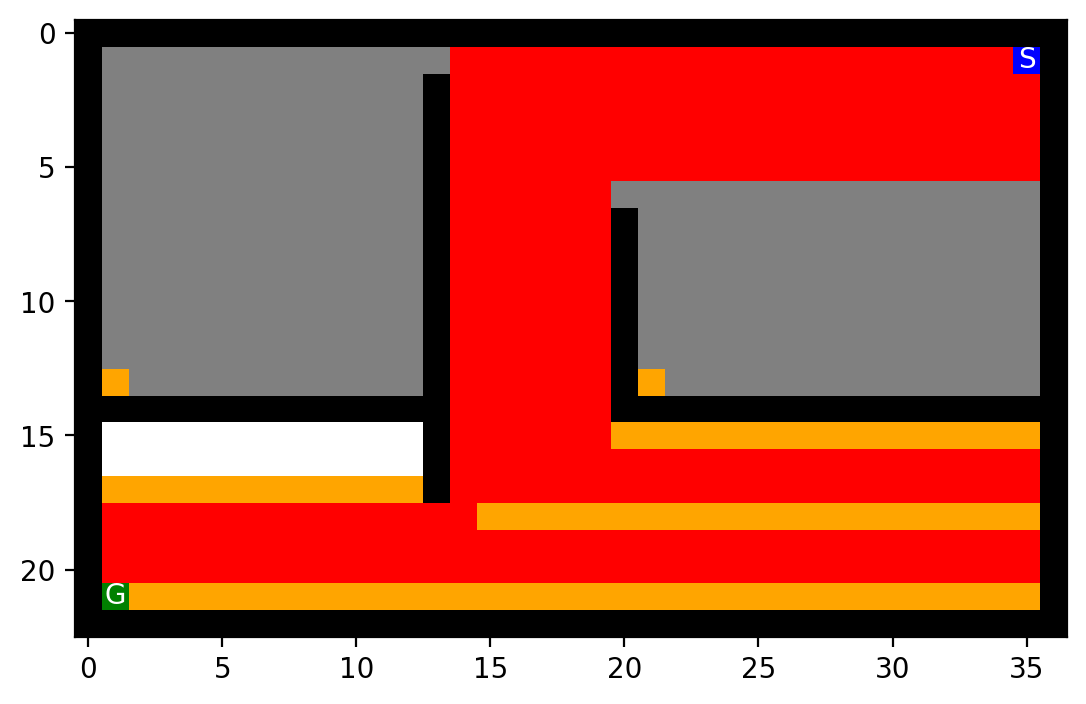

In [21]:
# Your code goes here
import maze_helper as maze_util
import pandas as pd
from queue import PriorityQueue

result_collection = []
current_labyrinth = ""

class LabyrinthPathVertex:
    def __init__(self, location, ancestor, move, path_length, target=None):
        self.location = tuple(location)  # the state; locations are (row,col)
        self.ancestor = ancestor  # reference to ancestor vertex. None means origin vertex.
        self.move = move  # move used in the transition function (origin vertex has None)
        self.path_length = path_length  # for uniform cost this is the depth. It is also g(n) for A* search

        self.target = target  # Keeps the coordinates of the target to later calculate the heuristics for A* and greedy

        # If the target is available then calculate the distance/heuristics
        if target:
            def manhattan_distance(vertex_location, target_location):
                # returns the distance for the target coordinates from the provided vertex coordinates
                return abs(vertex_location[0] - target_location[0]) + abs(vertex_location[1] - target_location[1])

            self.estimate = manhattan_distance(location, target)

    def __str__(self):
        return f"Vertex - location = {self.location}; move = {self.move}; path_length = {self.path_length}"

    # Helps the priority queue to assign the priority based on the heuristics
    def __lt__(self, other):
        return self.estimate < other.estimate

    def trace_path_to_origin(self):
        """returns vertices on the path from the origin to the current vertex."""
        vertex = self
        route = [vertex]
        while not vertex.ancestor is None:
            vertex = vertex.ancestor
            route.append(vertex)
        route.reverse()
        return route

# This method uses the Breadth-First-Search to traverse through the labyrinth/provided board.
# labyrinth variable contains the 2d array of a labyrinth like structure which is referenced in traversing.
# origin contains the origin coordinates, that is, the location to start from.
# destination contains the target coordinates, that is, the location to reach for.
# possible_moves contain the possible moves that an agent/piece can perform.
# origin_vertex contains the starting vertex for the tree to expand from.
def labyrinth_bfs(labyrinth, origin, destination, possible_moves, origin_vertex):
    # explored contains all the locations that the agent/piece has already covered.
    explored = set()

    # FIFO(First In First Out) strategy is used to perform breadth-first-search
    expansion_queue = [origin_vertex]
    steps = 0
    vertex_count = 1
    maximum_depth = 0
    max_branching = 0
    frontier_max_size = len(expansion_queue)

    # while the list/queue is not empty, that is, all the vertices are not explored the loop will keep on running.
    while expansion_queue:
        if frontier_max_size < len(expansion_queue):
            frontier_max_size = len(expansion_queue)

        current_vertex = expansion_queue.pop(0)
        current_location = current_vertex.location

        if current_vertex.path_length > maximum_depth:
            maximum_depth = current_vertex.path_length

        # When the target is reached the loop is forced to end.
        if current_location == destination:
            log_search_metrics(frontier_max_size, maximum_depth, current_vertex.path_length, vertex_count, steps, 'BFS')
            return current_vertex

        explored.add(current_location)

        # Any vertex that is not a wall or obstacle and which is not already explored is added to the queue for further inspection
        for direction in possible_moves.values():
            branch_count = 0
            adjacent_location = (current_location[0] + direction[0], current_location[1] + direction[1])

            if maze_util.look(labyrinth, adjacent_location) != "X" and adjacent_location not in explored:
                child_vertex = LabyrinthPathVertex(adjacent_location, current_vertex, direction, current_vertex.path_length + 1)

                if current_location != origin and current_location != destination and adjacent_location != destination:
                    labyrinth[adjacent_location[0]][adjacent_location[1]] = "F"
                    labyrinth[current_location[0]][current_location[1]] = "."

                vertex_count += 1
                branch_count += 1
                expansion_queue.append(child_vertex)

                if max_branching < branch_count:
                    max_branching = branch_count

        steps += 1
        # maze_util.show_maze(labyrinth)  # Uncomment to see each step

    # If the target cannot be reached or does not exist then None is returned.
    return None

# This method uses the Depth-First-Search to traverse through the labyrinth/provided board.
def labyrinth_dfs(labyrinth, origin, destination, possible_moves, origin_vertex):
    # explored contains all the locations that the agent/piece has already covered.
    explored = set()

    # LIFO(Last In First Out) strategy is used to perform depth-first-search
    expansion_stack = [origin_vertex]
    steps = 0
    vertex_count = 1
    maximum_depth = 0
    max_branching = 0
    frontier_max_size = len(expansion_stack)

    # while the list/stack is not empty, that is, the target is not reached the loop will keep on running.
    while expansion_stack:
        if frontier_max_size < len(expansion_stack):
            frontier_max_size = len(expansion_stack)

        current_vertex = expansion_stack.pop()
        current_location = current_vertex.location

        if current_vertex.path_length > maximum_depth:
            maximum_depth = current_vertex.path_length

        # When the target is reached the loop is forced to end.
        if current_location == destination:
            log_search_metrics(frontier_max_size, maximum_depth, current_vertex.path_length, vertex_count, steps, 'DFS')
            return current_vertex  # Return the target vertex when found

        explored.add(current_location)

        # Any vertex that is not a wall or obstacle and which is not already explored is added to the stack for further inspection
        for direction in possible_moves.values():
            branch_count = 0
            adjacent_location = (current_location[0] + direction[0], current_location[1] + direction[1])

            if maze_util.look(labyrinth, adjacent_location) != "X" and adjacent_location not in explored:
                child_vertex = LabyrinthPathVertex(adjacent_location, current_vertex, direction, current_vertex.path_length + 1)

                if current_location != origin and current_location != destination and adjacent_location != destination:
                    labyrinth[adjacent_location[0]][adjacent_location[1]] = "F"
                    labyrinth[current_location[0]][current_location[1]] = "."

                vertex_count += 1
                branch_count += 1
                expansion_stack.append(child_vertex)

                if max_branching < branch_count:
                    max_branching = branch_count

        steps += 1
        # maze_util.show_maze(labyrinth)  # Uncomment to see each step

    return None  # Return None if target is not found

def log_search_metrics(frontier_max_size, max_depth, path_cost, vertex_count, iteration_count, algorithm_name):
    global result_collection
    global current_labyrinth

    print('The Maximum Frontier Size is', frontier_max_size)
    print('The Maximum Depth of the tree is', max_depth)
    print('The cost for the Path is', path_cost)
    print('The Maximum tree size is', vertex_count)
    print('The maximum Branching Factor is ', iteration_count)

    result_collection.append([current_labyrinth, algorithm_name, frontier_max_size, max_depth, path_cost, vertex_count, iteration_count])

# Executes all the labyrinths in a loop, to provide all the outputs together
def run_all_labyrinths():
    global current_labyrinth

    labyrinth_files = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "loops_maze.txt",
                      "wall_maze.txt", "empty_maze.txt", "empty_2_maze.txt", "open_maze.txt"]

    # Run BFS on all labyrinths
    for maze_file in labyrinth_files:
        if maze_file != "open_maze.txt":
            current_labyrinth = maze_file[:maze_file.find(".")]

            # Getting the text file and parsing the labyrinth from it as a 2d matrix
            with open(maze_file, "r") as file:
                labyrinth_str = file.read()
                print(labyrinth_str)

                parsed_labyrinth = maze_util.parse_maze(labyrinth_str)
                maze_util.show_maze(parsed_labyrinth)
                execute_search_algorithm(parsed_labyrinth, "BFS")

    # Run DFS on all labyrinths
    for maze_file in labyrinth_files:
        current_labyrinth = maze_file[:maze_file.find(".")]

        # Getting the text file and parsing the labyrinth from it as a 2d matrix
        with open(maze_file, "r") as file:
            labyrinth_str = file.read()
            print(labyrinth_str)

            parsed_labyrinth = maze_util.parse_maze(labyrinth_str)
            maze_util.show_maze(parsed_labyrinth)
            execute_search_algorithm(parsed_labyrinth, "DFS")

# Based on the search_type executes the provided search for the given labyrinth
def execute_search_algorithm(labyrinth, search_type="BFS"):
    origin_point = []
    target_point = []

    # Finding the origin coordinates for the labyrinth
    origin_point = maze_util.find_pos(labyrinth)

    # Finding the Target coordinates for the labyrinth
    target_point = maze_util.find_pos(labyrinth, what="G")

    # These are the possible moves at any point for a 2d labyrinth.
    directions = {"north": (-1, 0), "south": (1, 0), "east": (0, 1), "west": (0, -1)}

    start_vertex = LabyrinthPathVertex(origin_point, None, None, 0)

    solution_vertex = None

    if search_type.upper() == "BFS":
        solution_vertex = labyrinth_bfs(labyrinth, origin_point, target_point, directions, start_vertex)
    elif search_type.upper() == "DFS":
        solution_vertex = labyrinth_dfs(labyrinth, origin_point, target_point, directions, start_vertex)
    elif search_type.upper() == "GBFS":
        solution_vertex = greedy_best_first_search(labyrinth, origin_point, target_point, directions)
    elif search_type.upper() == "ASTAR":
        solution_vertex = a_star_search(labyrinth, origin_point, target_point, directions)

    # Extract and print the path
    if solution_vertex:
        path = solution_vertex.trace_path_to_origin()
        print("Path from origin to target:")

        for vertex in path:
            print(vertex.location)
            if vertex.location != origin_point and vertex.location != target_point:
                labyrinth[vertex.location[0]][vertex.location[1]] = "P"

        print("Cost:", solution_vertex.path_length)
    else:
        print("Target not found")

    maze_util.show_maze(labyrinth)

# Main execution
run_all_labyrinths()

How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

In [22]:
# Discussion
#The breadth-first and depth-first search algorithms maintain a record of explored locations to
# handle loops and cycles. When encountering a position that has been previously explored,
#the algorithm bypasses that location and does not incorporate it into the search tree.






Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

In [ ]:
# # Discussion
# #The breadth-first search implementation guarantees both completeness and optimality, while depth-first search provides neither of these guarantees.
# # Whereas breadth-first algorithm systematically examines all adjacent locations before proceeding deeper,
# depth-first search explores a single directional path completely until encountering either a dead end or the target location.
# Both algorithms have worst-case space and time complexities of O(MN), where MN represents the dimensions of the labyrinth,
# since the target might be absent or positioned at the furthest possible location requiring exploration of the entire structure.

## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides).

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



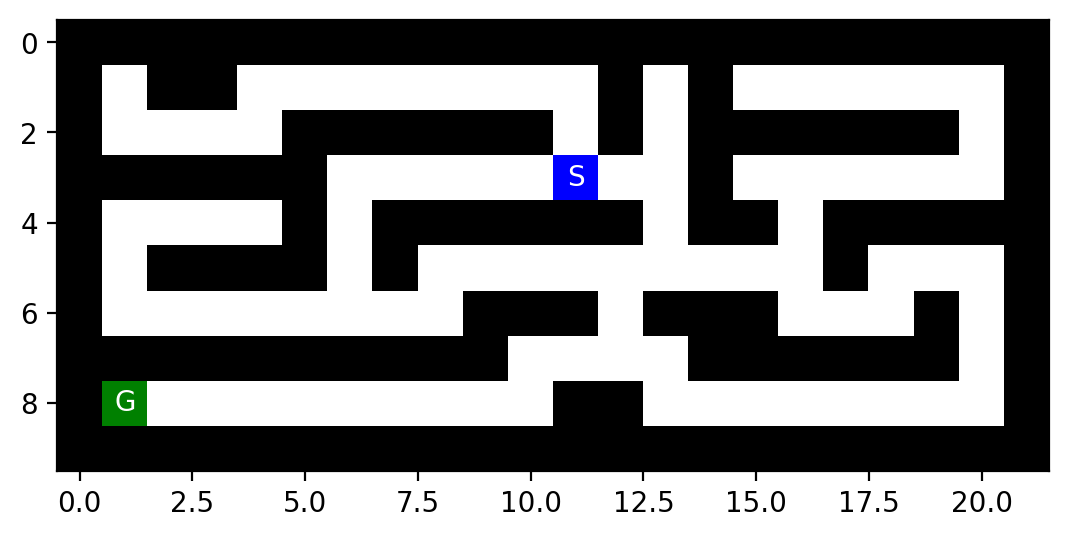

The Maximum Frontier Size is 5
The Maximum Depth of the tree is 29
The cost for the Path is 29
The Maximum tree size is 44
The maximum Branching Factor is  39
Path from origin to target:
(3, 11)
(3, 10)
(3, 9)
(3, 8)
(3, 7)
(3, 6)
(4, 6)
(5, 6)
(6, 6)
(6, 7)
(6, 8)
(5, 8)
(5, 9)
(5, 10)
(5, 11)
(5, 12)
(6, 12)
(7, 12)
(7, 11)
(7, 10)
(8, 10)
(8, 9)
(8, 8)
(8, 7)
(8, 6)
(8, 5)
(8, 4)
(8, 3)
(8, 2)
(8, 1)
Cost: 29


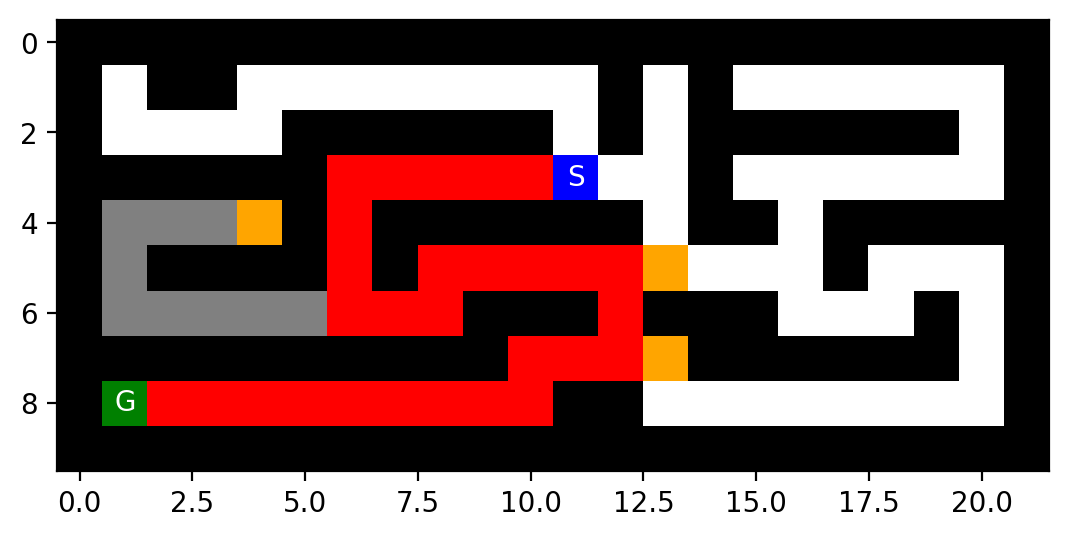

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X                                 SX
X XXXXXXXXXXXXXXXXXXXXXXX XXXXXXXX X
X XX   X   X      XXXXXXX   XX     X
X XX X X X X XXXX XXXXXXXXX XX XXXXX
X XX X X X X             XX XX     X
X XX X X X X X XXXX  XXX    XXXXXX X
X X  X X X   X    XX XXXXXXXX      X
X XX X X XXXXXXXX XX        XX XXXXX
X XX X   XX       XXXXXXXXX XX     X
X    XXXXXX XXXXXXX      XX XXXXXX X
XXXXXX      X       XXXX XX X      X
X      XXXXXX XXXXX X    XX XX XXXXX
X XXXXXX      X       XXXXX XX     X
X        XXXXXX XXXXXXXXXXX XX  XX X
XXXXXXXXXX                  XXXXXX X
XG         XXXXXXXXXXXXXXXX        X
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX




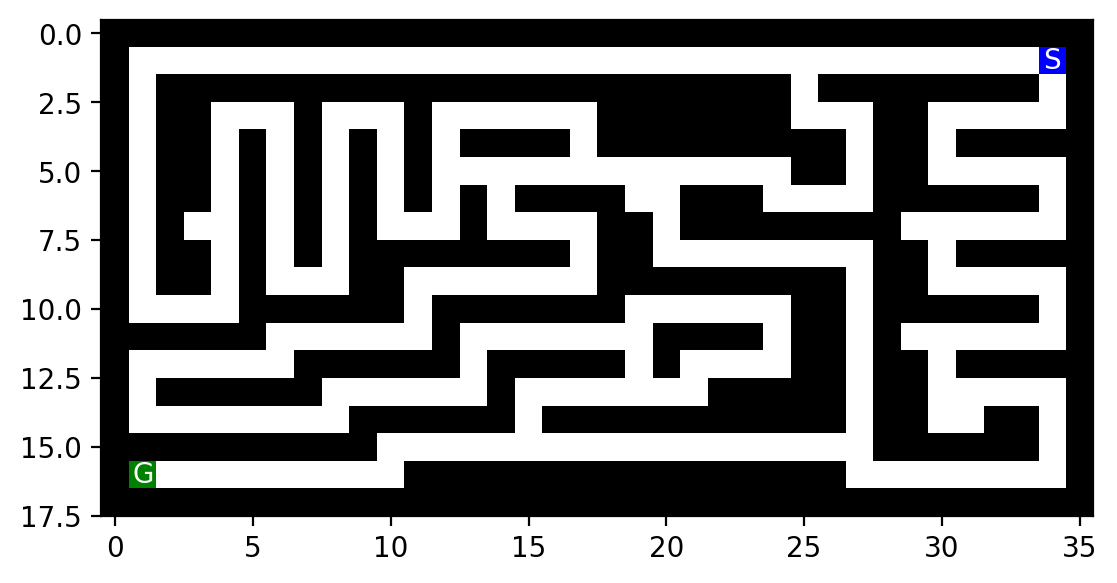

The Maximum Frontier Size is 5
The Maximum Depth of the tree is 74
The cost for the Path is 74
The Maximum tree size is 86
The maximum Branching Factor is  81
Path from origin to target:
(1, 34)
(2, 34)
(3, 34)
(3, 33)
(3, 32)
(3, 31)
(3, 30)
(4, 30)
(5, 30)
(5, 31)
(5, 32)
(5, 33)
(5, 34)
(6, 34)
(7, 34)
(7, 33)
(7, 32)
(7, 31)
(7, 30)
(8, 30)
(9, 30)
(9, 31)
(9, 32)
(9, 33)
(9, 34)
(10, 34)
(11, 34)
(11, 33)
(11, 32)
(11, 31)
(11, 30)
(12, 30)
(13, 30)
(13, 31)
(13, 32)
(13, 33)
(13, 34)
(14, 34)
(15, 34)
(16, 34)
(16, 33)
(16, 32)
(16, 31)
(16, 30)
(16, 29)
(16, 28)
(16, 27)
(15, 27)
(15, 26)
(15, 25)
(15, 24)
(15, 23)
(15, 22)
(15, 21)
(15, 20)
(15, 19)
(15, 18)
(15, 17)
(15, 16)
(15, 15)
(15, 14)
(15, 13)
(15, 12)
(15, 11)
(15, 10)
(16, 10)
(16, 9)
(16, 8)
(16, 7)
(16, 6)
(16, 5)
(16, 4)
(16, 3)
(16, 2)
(16, 1)
Cost: 74


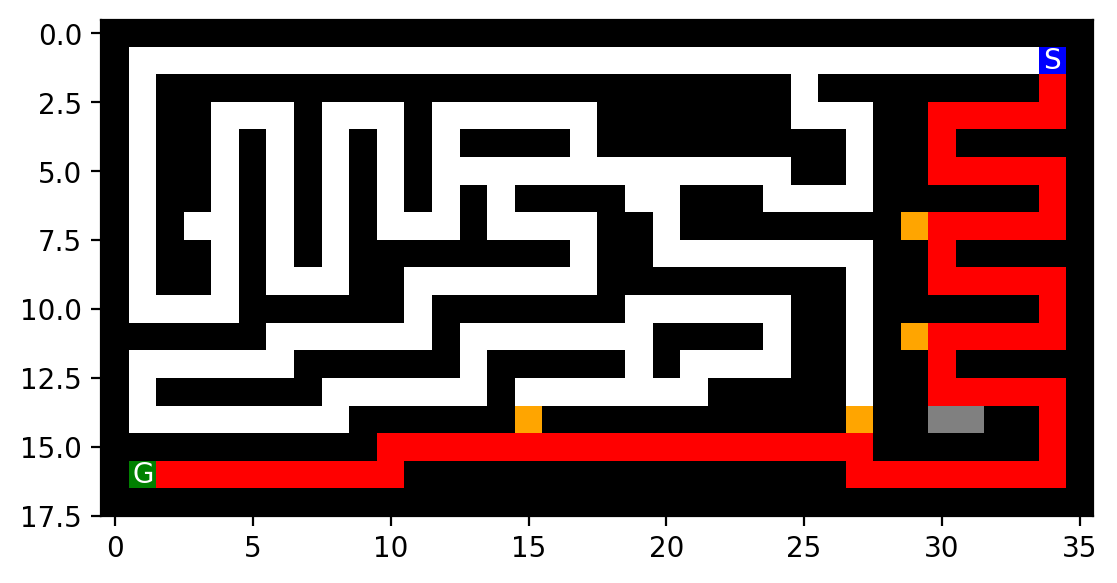

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X       X X X           X   X     X X
X XXXXXXX X XXX X XXX XXX XXXXXXX X X
X       X       X X     X     X X   X
XXXXX XXXXX XXX X X X XXX XXXXX X XXX
X   X X X X   X X X X   X X   X X   X
X XXX X X X XXX XXXXX XXX X XXX XXX X
X       X     X   X   X     X X X   X
XXX XXXXXXXXX XXXXXXX XXX XXX X X X X
X             X       X X   X     X X
X X XXXXX X XXX X X XXX X XXX XXX X X
X X X     X X X X X     X   X X X X X
X X X XXXXXXX X XXXXXXXXX XXX X XXX X
X X X X     X   X     X     X   X   X
XXX XXX X XXXXX XXXXX XXX XXX XXXXX X
X     X X X     X X     X X   X X X X
X X X X X XXX XXX XXX XXX X X X X X X
X X X X X                 X X X     X
XXX XXXXXXX X X XXXXX XXX X XXX XXXXX
X       X X X X     X   X     X X   X
XXXXX X X XXXXXXXXX XXXXXXXXXXX X XXX
X   X X           X X     X   X X   X
X XXX XXXXX XXXXXXXXX XXXXX X X XXX X
X X   X      X        X     X       X
X X X XXXXX XXX X X X X XXXXXXXXXXXXX
X X X   X     X X X X       X   X X X
X X XXX XXX 

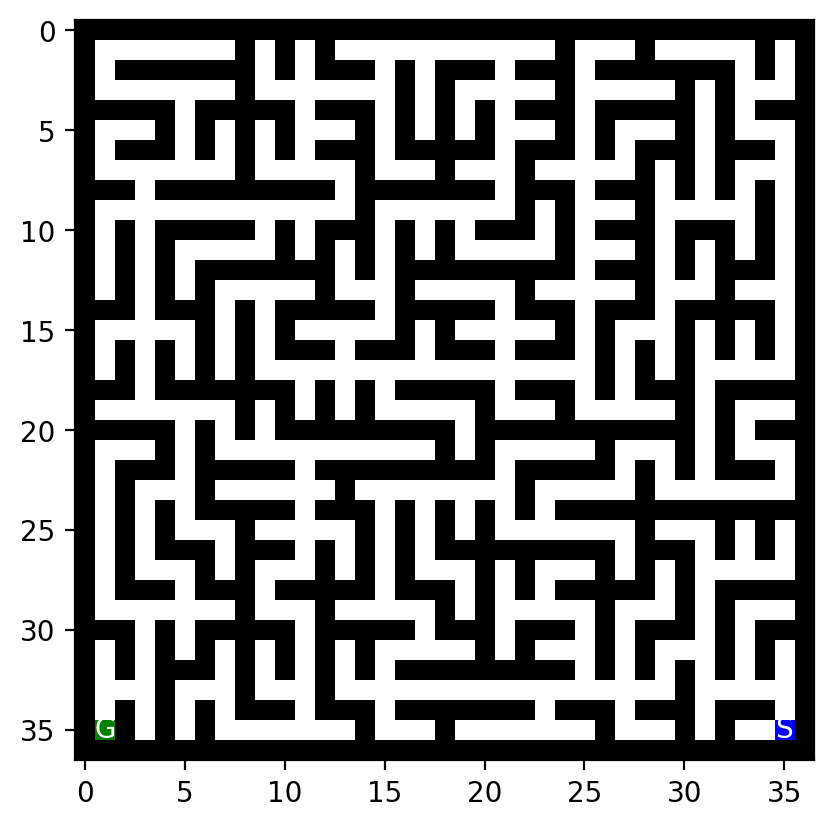

The Maximum Frontier Size is 22
The Maximum Depth of the tree is 210
The cost for the Path is 210
The Maximum tree size is 485
The maximum Branching Factor is  463
Path from origin to target:
(35, 35)
(34, 35)
(33, 35)
(33, 34)
(33, 33)
(33, 32)
(33, 31)
(32, 31)
(31, 31)
(31, 30)
(31, 29)
(32, 29)
(33, 29)
(33, 28)
(33, 27)
(33, 26)
(33, 25)
(33, 24)
(33, 23)
(33, 22)
(33, 21)
(33, 20)
(33, 19)
(33, 18)
(33, 17)
(33, 16)
(33, 15)
(32, 15)
(31, 15)
(31, 16)
(31, 17)
(30, 17)
(29, 17)
(29, 16)
(29, 15)
(28, 15)
(27, 15)
(26, 15)
(25, 15)
(24, 15)
(23, 15)
(23, 16)
(23, 17)
(23, 18)
(23, 19)
(23, 20)
(23, 21)
(24, 21)
(25, 21)
(25, 22)
(25, 23)
(24, 23)
(23, 23)
(23, 24)
(23, 25)
(23, 26)
(23, 27)
(22, 27)
(21, 27)
(21, 28)
(21, 29)
(22, 29)
(23, 29)
(23, 30)
(23, 31)
(22, 31)
(21, 31)
(20, 31)
(19, 31)
(18, 31)
(17, 31)
(17, 32)
(17, 33)
(17, 34)
(17, 35)
(16, 35)
(15, 35)
(14, 35)
(13, 35)
(12, 35)
(11, 35)
(10, 35)
(9, 35)
(8, 35)
(7, 35)
(7, 34)
(7, 33)
(8, 33)
(9, 33)
(9, 32)
(9, 31

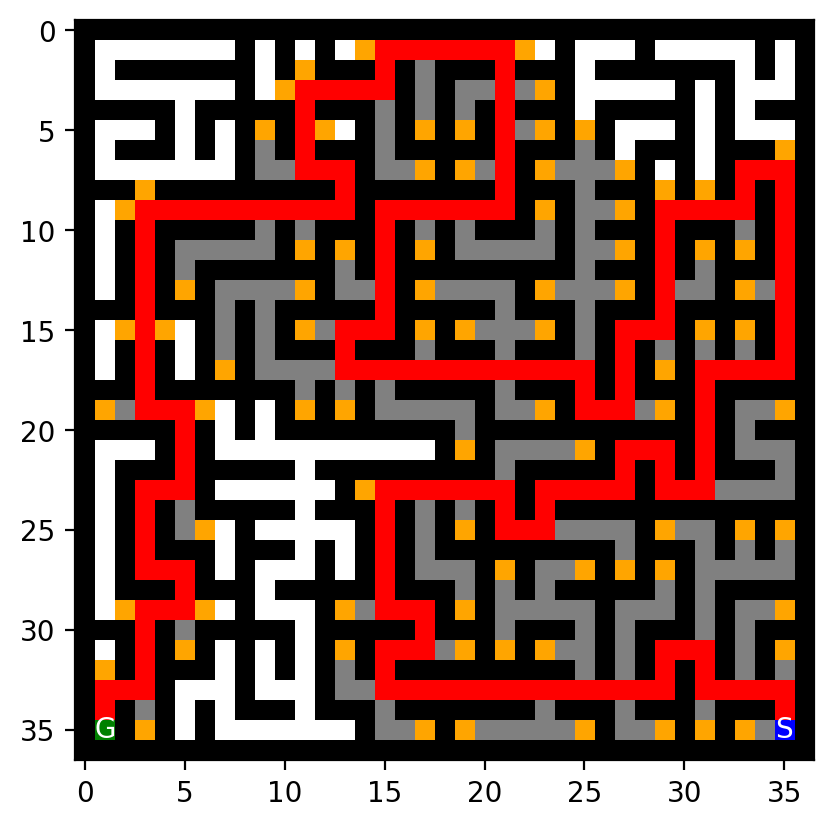

XXXXXXXXXXXX
XG         X
X        X X
XXXXXXXX X X
X      X X X
X    X X X X
X    X X   X
X    X X X X
X    X X X X
XXXX X X X X
XS         X
XXXXXXXXXXXX



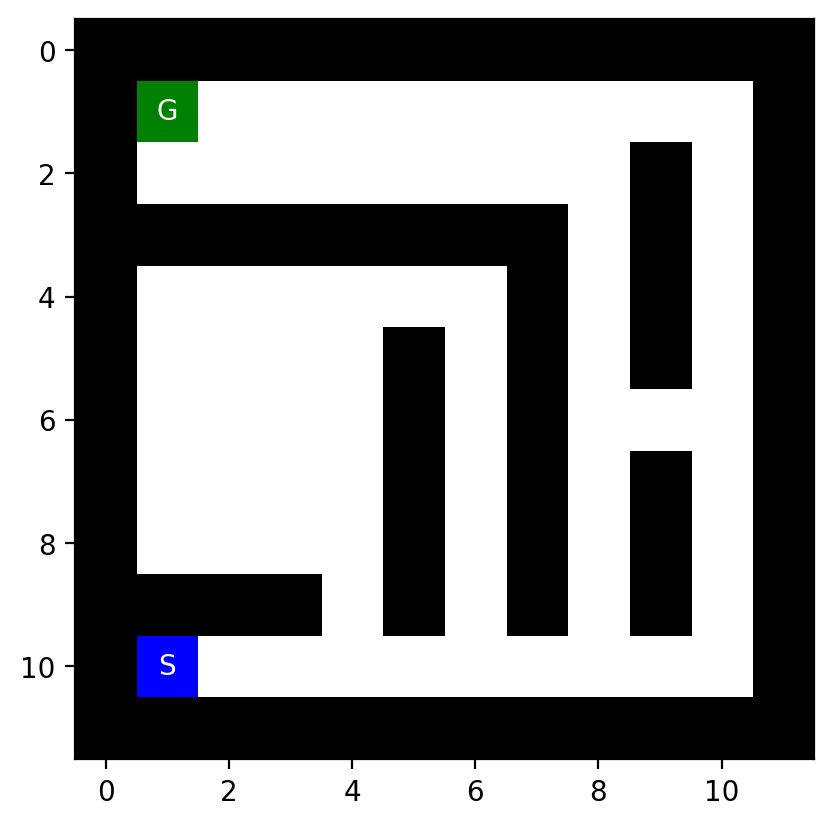

The Maximum Frontier Size is 21
The Maximum Depth of the tree is 23
The cost for the Path is 23
The Maximum tree size is 115
The maximum Branching Factor is  103
Path from origin to target:
(10, 1)
(10, 2)
(10, 3)
(10, 4)
(10, 5)
(10, 6)
(10, 7)
(10, 8)
(9, 8)
(8, 8)
(7, 8)
(6, 8)
(5, 8)
(4, 8)
(3, 8)
(2, 8)
(1, 8)
(1, 7)
(1, 6)
(1, 5)
(1, 4)
(1, 3)
(1, 2)
(1, 1)
Cost: 23


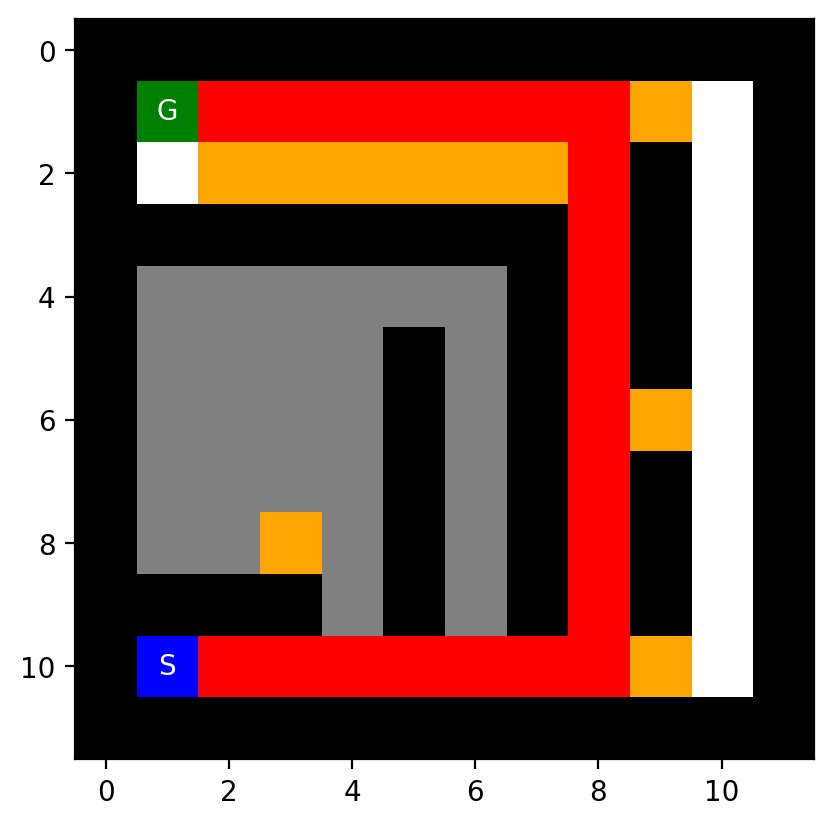

XXXXXXXXXXXX
X          X
X        G X
X          X
X   XXXX   X
X      X   X
X      X   X
X      X   X
X          X
X S        X
X          X
XXXXXXXXXXXX



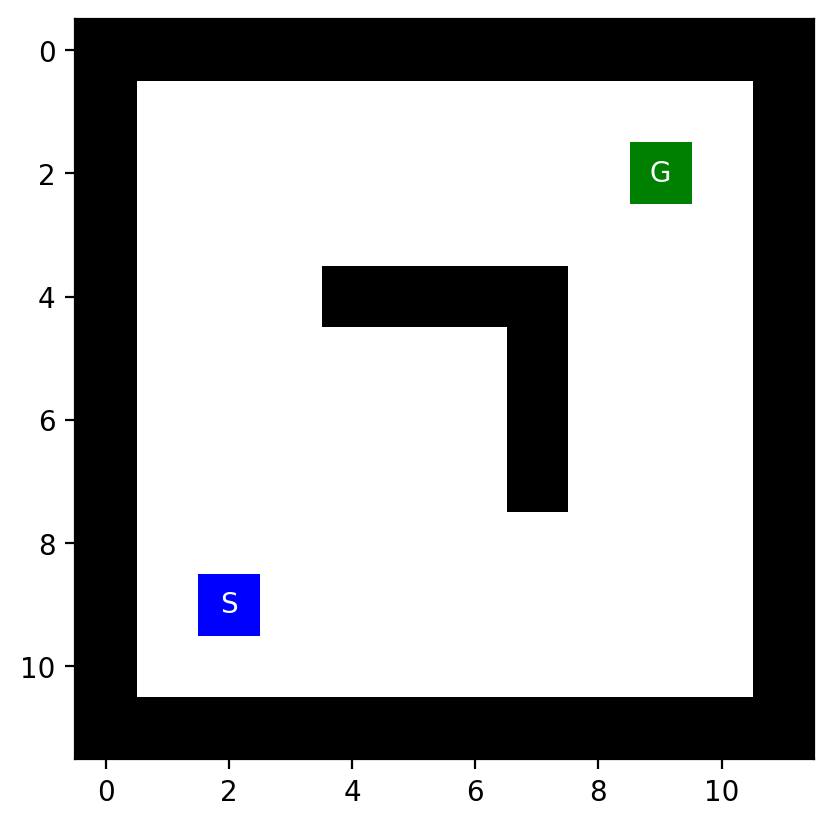

The Maximum Frontier Size is 30
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 44
The maximum Branching Factor is  14
Path from origin to target:
(9, 2)
(8, 2)
(7, 2)
(6, 2)
(5, 2)
(4, 2)
(3, 2)
(2, 2)
(2, 3)
(2, 4)
(2, 5)
(2, 6)
(2, 7)
(2, 8)
(2, 9)
Cost: 14


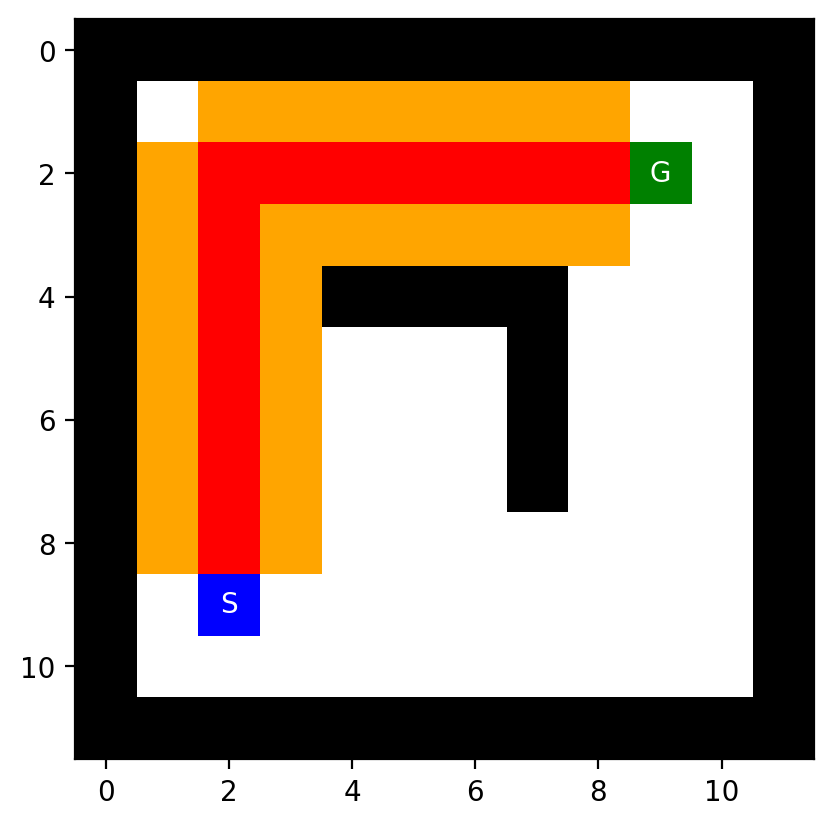

XXXXXXXXXXXX
X          X
X        G X
X          X
X          X
X          X
X          X
X          X
X          X
X S        X
X          X
XXXXXXXXXXXX



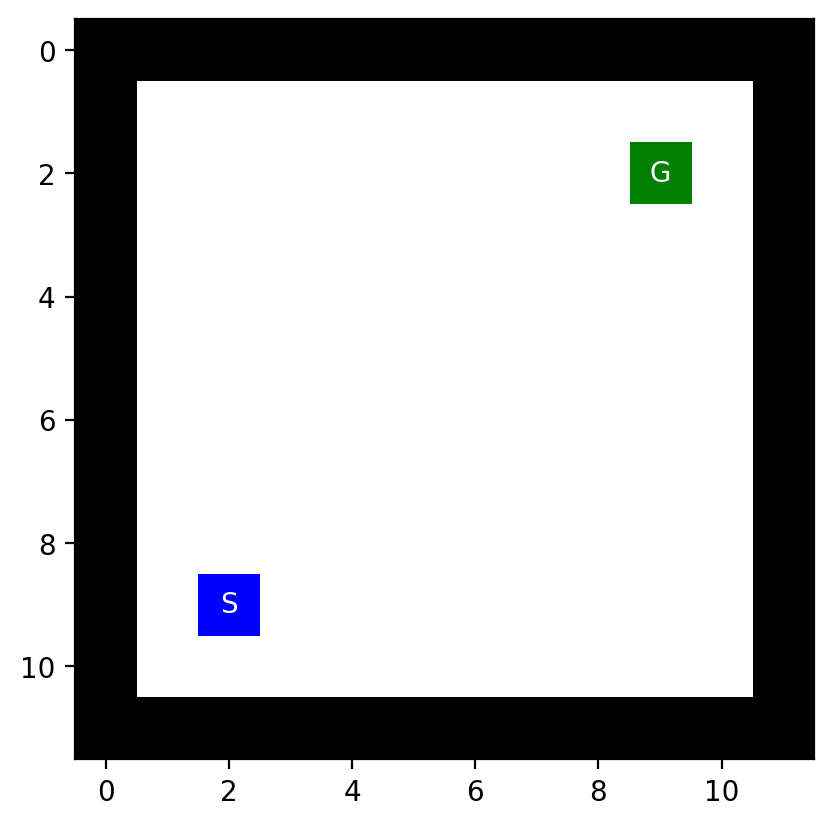

The Maximum Frontier Size is 30
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 44
The maximum Branching Factor is  14
Path from origin to target:
(9, 2)
(8, 2)
(7, 2)
(6, 2)
(5, 2)
(4, 2)
(3, 2)
(2, 2)
(2, 3)
(2, 4)
(2, 5)
(2, 6)
(2, 7)
(2, 8)
(2, 9)
Cost: 14


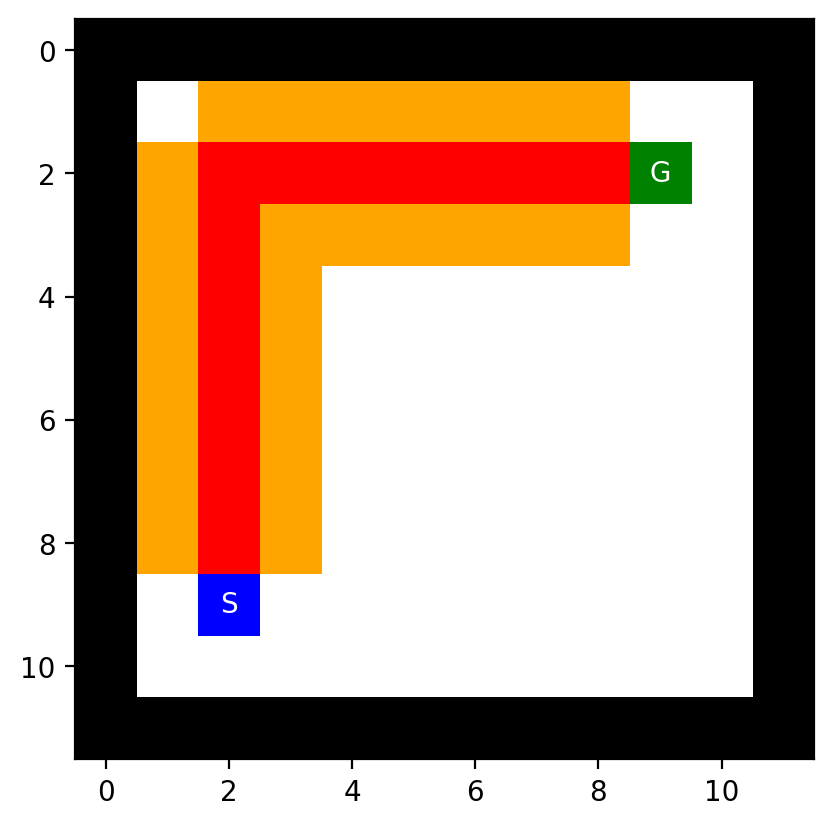

XXXXXXXXXXXX
X          X
X        S X
X          X
X          X
X          X
X          X
X          X
X          X
X G        X
X          X
XXXXXXXXXXXX



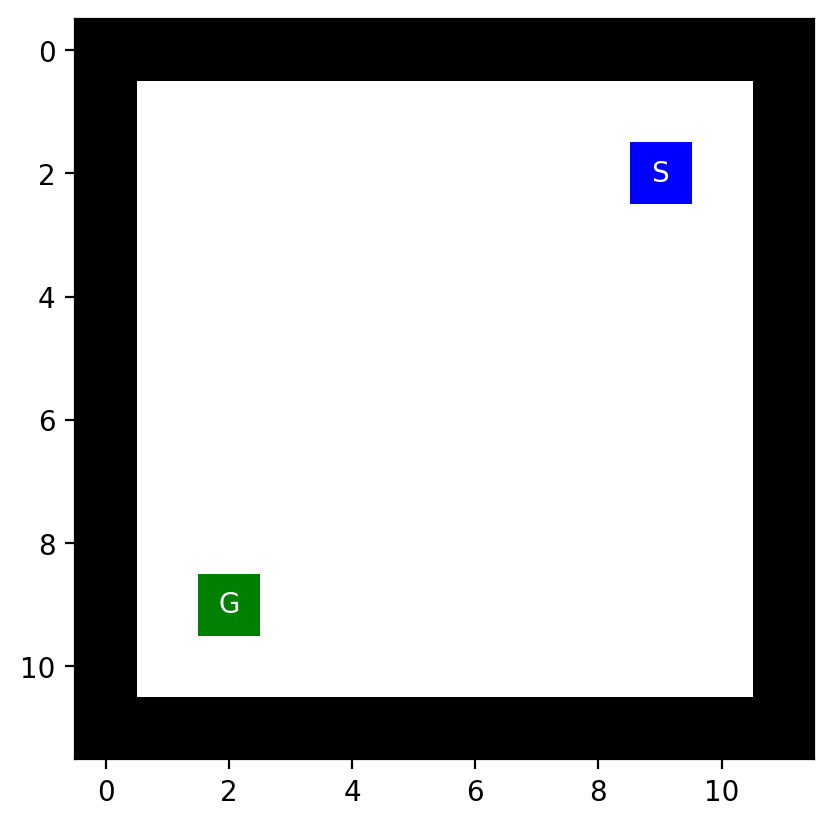

The Maximum Frontier Size is 30
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 44
The maximum Branching Factor is  14
Path from origin to target:
(2, 9)
(3, 9)
(4, 9)
(5, 9)
(6, 9)
(7, 9)
(8, 9)
(9, 9)
(9, 8)
(9, 7)
(9, 6)
(9, 5)
(9, 4)
(9, 3)
(9, 2)
Cost: 14


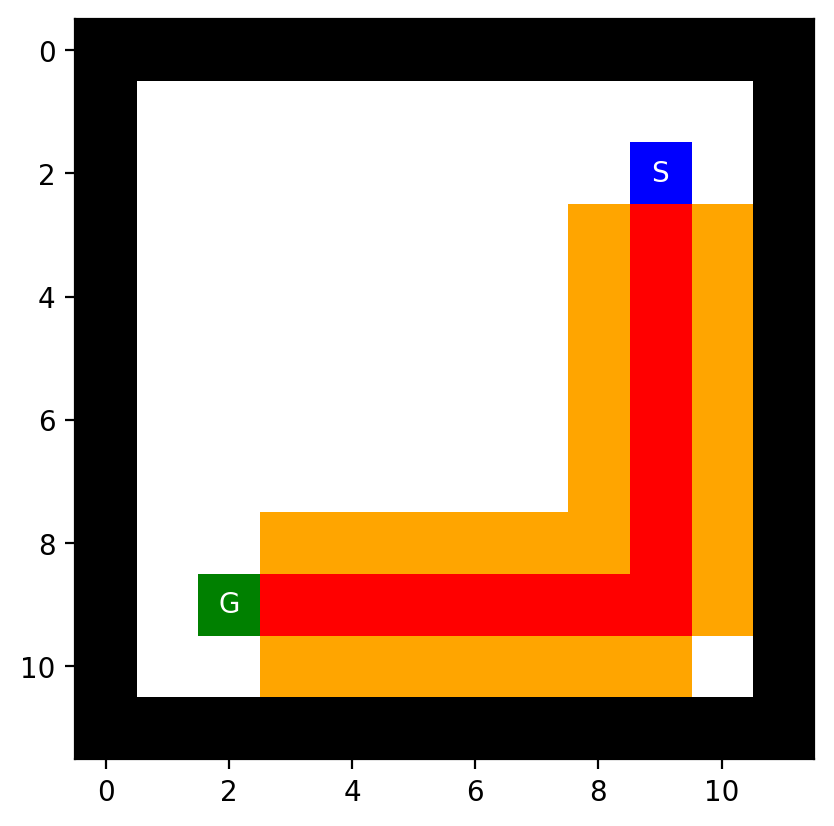

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X                                  SX
X            X                      X
X            X                      X
X            X                      X
X            X                      X
X            X                      X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
XXXXXXXXXXXXXX      XXXXXXXXXXXXXXXXX
X            X                      X
X            X                      X
X            X                      X
X                                   X
X                                   X
X                                   X
XG                                  X
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX



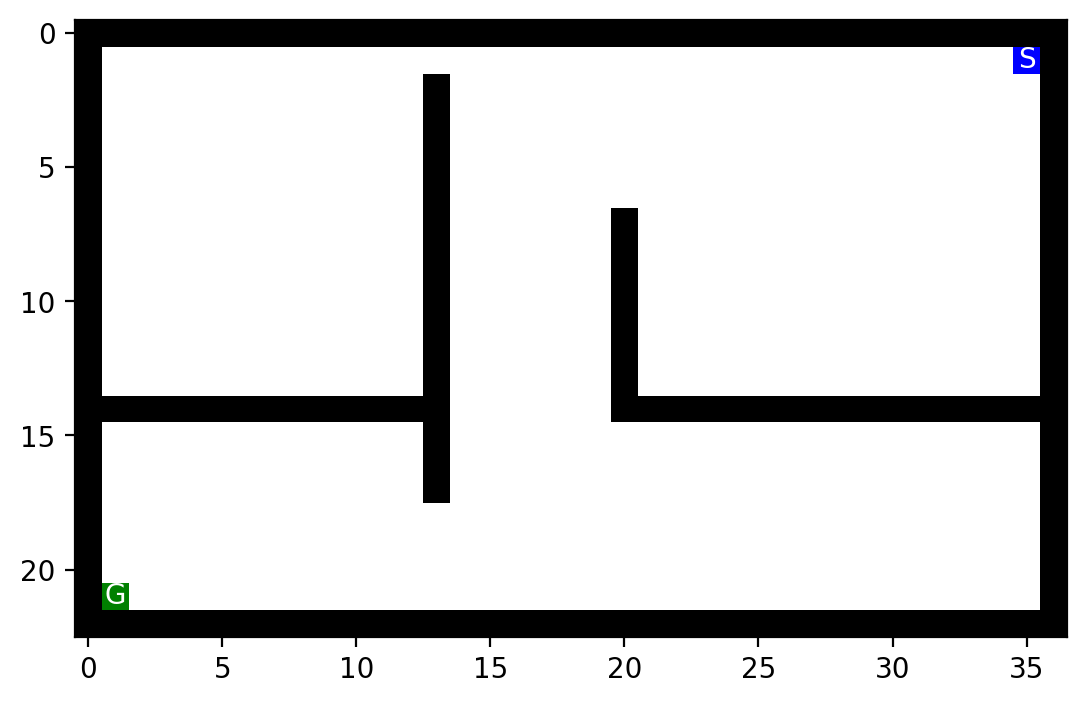

The Maximum Frontier Size is 203
The Maximum Depth of the tree is 68
The cost for the Path is 68
The Maximum tree size is 399
The maximum Branching Factor is  196
Path from origin to target:
(1, 35)
(2, 35)
(3, 35)
(4, 35)
(5, 35)
(6, 35)
(7, 35)
(8, 35)
(9, 35)
(10, 35)
(11, 35)
(12, 35)
(13, 35)
(13, 34)
(13, 33)
(13, 32)
(13, 31)
(13, 30)
(13, 29)
(13, 28)
(13, 27)
(13, 26)
(13, 25)
(13, 24)
(13, 23)
(13, 22)
(13, 21)
(12, 21)
(11, 21)
(10, 21)
(9, 21)
(8, 21)
(7, 21)
(6, 21)
(6, 20)
(6, 19)
(7, 19)
(8, 19)
(9, 19)
(10, 19)
(11, 19)
(12, 19)
(13, 19)
(14, 19)
(15, 19)
(16, 19)
(17, 19)
(18, 19)
(19, 19)
(20, 19)
(21, 19)
(21, 18)
(21, 17)
(21, 16)
(21, 15)
(21, 14)
(21, 13)
(21, 12)
(21, 11)
(21, 10)
(21, 9)
(21, 8)
(21, 7)
(21, 6)
(21, 5)
(21, 4)
(21, 3)
(21, 2)
(21, 1)
Cost: 68


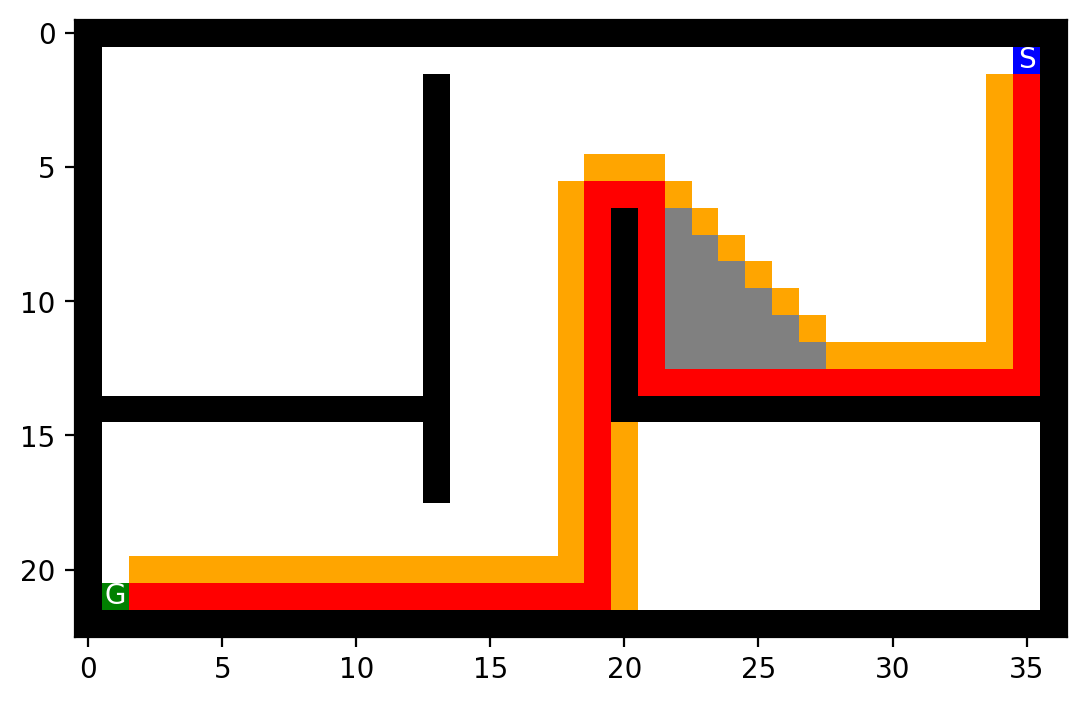

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



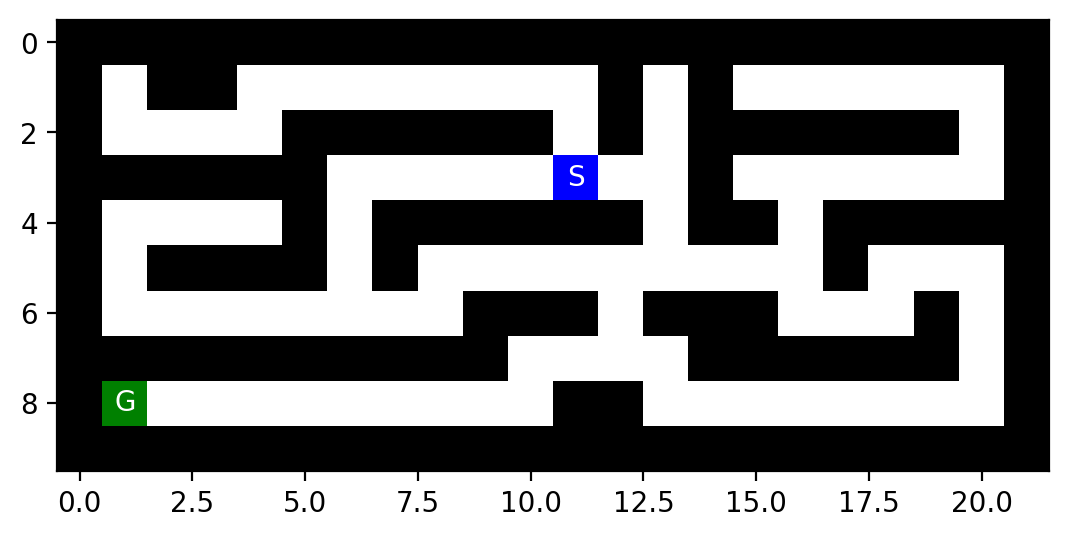

The Maximum Frontier Size is 8
The Maximum Depth of the tree is 19
The cost for the Path is 19
The Maximum tree size is 57
The maximum Branching Factor is  49
Path from origin to target:
(3, 11)
(3, 12)
(3, 13)
(4, 13)
(5, 13)
(5, 12)
(6, 12)
(7, 12)
(7, 11)
(7, 10)
(8, 10)
(8, 9)
(8, 8)
(8, 7)
(8, 6)
(8, 5)
(8, 4)
(8, 3)
(8, 2)
(8, 1)
Cost: 19


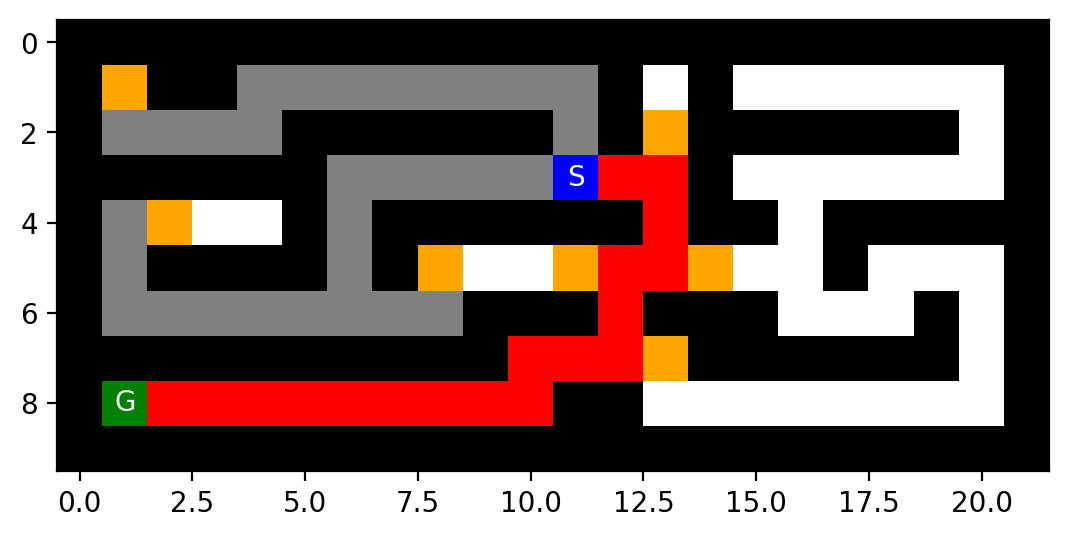

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X                                 SX
X XXXXXXXXXXXXXXXXXXXXXXX XXXXXXXX X
X XX   X   X      XXXXXXX   XX     X
X XX X X X X XXXX XXXXXXXXX XX XXXXX
X XX X X X X             XX XX     X
X XX X X X X X XXXX  XXX    XXXXXX X
X X  X X X   X    XX XXXXXXXX      X
X XX X X XXXXXXXX XX        XX XXXXX
X XX X   XX       XXXXXXXXX XX     X
X    XXXXXX XXXXXXX      XX XXXXXX X
XXXXXX      X       XXXX XX X      X
X      XXXXXX XXXXX X    XX XX XXXXX
X XXXXXX      X       XXXXX XX     X
X        XXXXXX XXXXXXXXXXX XX  XX X
XXXXXXXXXX                  XXXXXX X
XG         XXXXXXXXXXXXXXXX        X
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX




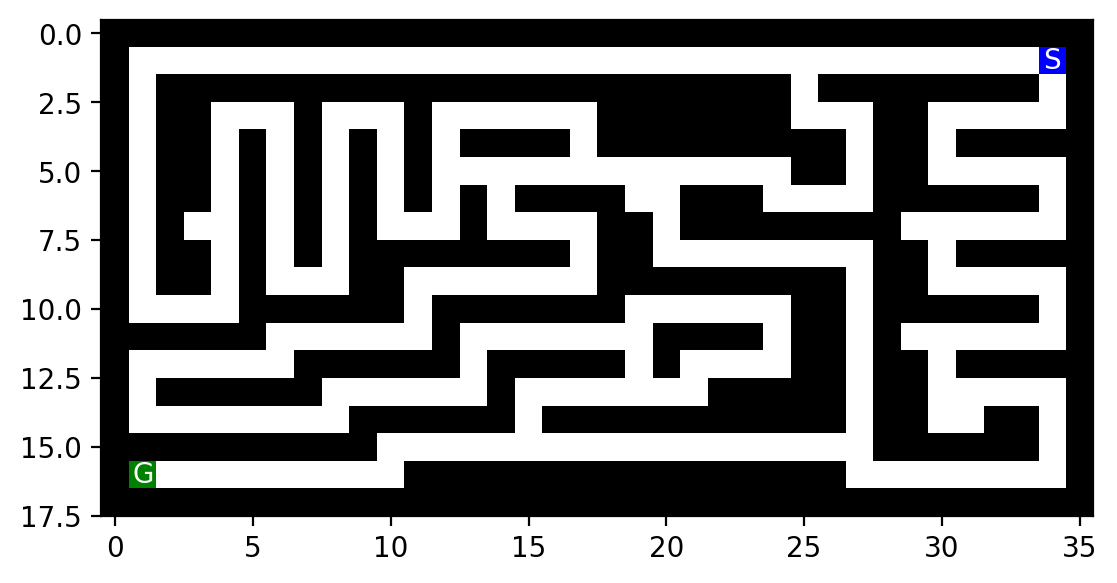

The Maximum Frontier Size is 8
The Maximum Depth of the tree is 68
The cost for the Path is 68
The Maximum tree size is 232
The maximum Branching Factor is  224
Path from origin to target:
(1, 34)
(1, 33)
(1, 32)
(1, 31)
(1, 30)
(1, 29)
(1, 28)
(1, 27)
(1, 26)
(1, 25)
(2, 25)
(3, 25)
(3, 26)
(3, 27)
(4, 27)
(5, 27)
(6, 27)
(6, 26)
(6, 25)
(6, 24)
(5, 24)
(5, 23)
(5, 22)
(5, 21)
(5, 20)
(6, 20)
(7, 20)
(8, 20)
(8, 21)
(8, 22)
(8, 23)
(8, 24)
(8, 25)
(8, 26)
(8, 27)
(9, 27)
(10, 27)
(11, 27)
(12, 27)
(13, 27)
(14, 27)
(15, 27)
(15, 26)
(15, 25)
(15, 24)
(15, 23)
(15, 22)
(15, 21)
(15, 20)
(15, 19)
(15, 18)
(15, 17)
(15, 16)
(15, 15)
(15, 14)
(15, 13)
(15, 12)
(15, 11)
(15, 10)
(16, 10)
(16, 9)
(16, 8)
(16, 7)
(16, 6)
(16, 5)
(16, 4)
(16, 3)
(16, 2)
(16, 1)
Cost: 68


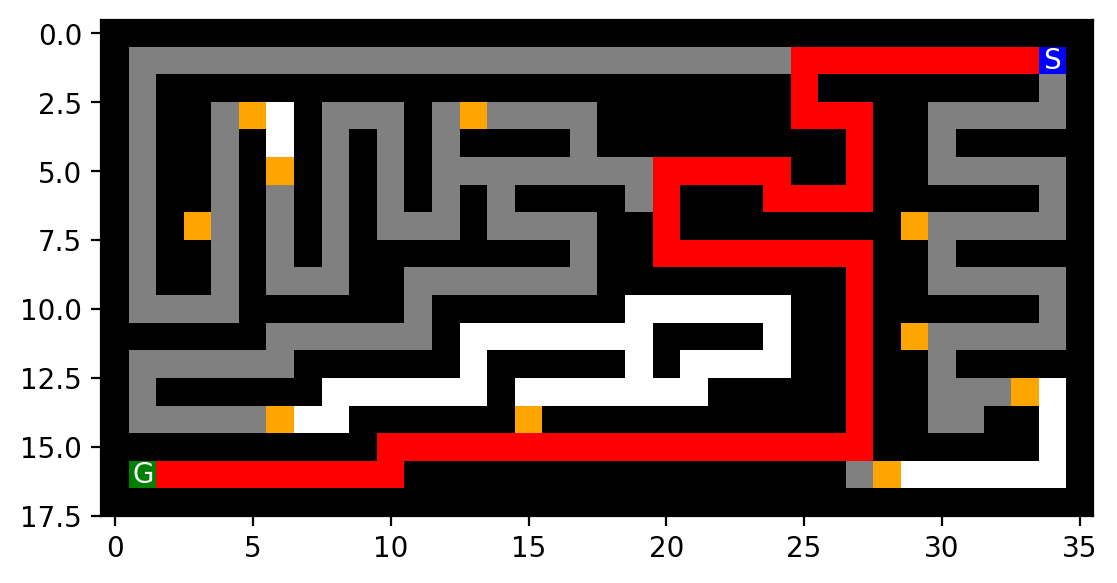

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X       X X X           X   X     X X
X XXXXXXX X XXX X XXX XXX XXXXXXX X X
X       X       X X     X     X X   X
XXXXX XXXXX XXX X X X XXX XXXXX X XXX
X   X X X X   X X X X   X X   X X   X
X XXX X X X XXX XXXXX XXX X XXX XXX X
X       X     X   X   X     X X X   X
XXX XXXXXXXXX XXXXXXX XXX XXX X X X X
X             X       X X   X     X X
X X XXXXX X XXX X X XXX X XXX XXX X X
X X X     X X X X X     X   X X X X X
X X X XXXXXXX X XXXXXXXXX XXX X XXX X
X X X X     X   X     X     X   X   X
XXX XXX X XXXXX XXXXX XXX XXX XXXXX X
X     X X X     X X     X X   X X X X
X X X X X XXX XXX XXX XXX X X X X X X
X X X X X                 X X X     X
XXX XXXXXXX X X XXXXX XXX X XXX XXXXX
X       X X X X     X   X     X X   X
XXXXX X X XXXXXXXXX XXXXXXXXXXX X XXX
X   X X           X X     X   X X   X
X XXX XXXXX XXXXXXXXX XXXXX X X XXX X
X X   X      X        X     X       X
X X X XXXXX XXX X X X X XXXXXXXXXXXXX
X X X   X     X X X X       X   X X X
X X XXX XXX 

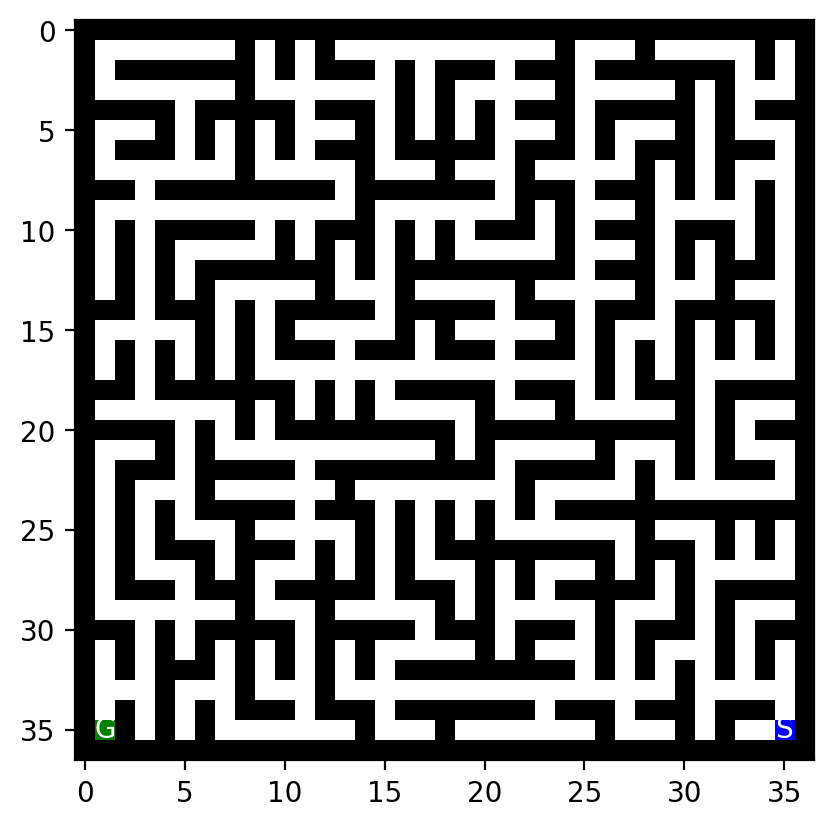

The Maximum Frontier Size is 13
The Maximum Depth of the tree is 210
The cost for the Path is 210
The Maximum tree size is 547
The maximum Branching Factor is  539
Path from origin to target:
(35, 35)
(34, 35)
(33, 35)
(33, 34)
(33, 33)
(33, 32)
(33, 31)
(32, 31)
(31, 31)
(31, 30)
(31, 29)
(32, 29)
(33, 29)
(33, 28)
(33, 27)
(33, 26)
(33, 25)
(33, 24)
(33, 23)
(33, 22)
(33, 21)
(33, 20)
(33, 19)
(33, 18)
(33, 17)
(33, 16)
(33, 15)
(32, 15)
(31, 15)
(31, 16)
(31, 17)
(30, 17)
(29, 17)
(29, 16)
(29, 15)
(28, 15)
(27, 15)
(26, 15)
(25, 15)
(24, 15)
(23, 15)
(23, 16)
(23, 17)
(23, 18)
(23, 19)
(23, 20)
(23, 21)
(24, 21)
(25, 21)
(25, 22)
(25, 23)
(24, 23)
(23, 23)
(23, 24)
(23, 25)
(23, 26)
(23, 27)
(22, 27)
(21, 27)
(21, 28)
(21, 29)
(22, 29)
(23, 29)
(23, 30)
(23, 31)
(22, 31)
(21, 31)
(20, 31)
(19, 31)
(18, 31)
(17, 31)
(17, 32)
(17, 33)
(17, 34)
(17, 35)
(16, 35)
(15, 35)
(14, 35)
(13, 35)
(12, 35)
(11, 35)
(10, 35)
(9, 35)
(8, 35)
(7, 35)
(7, 34)
(7, 33)
(8, 33)
(9, 33)
(9, 32)
(9, 31

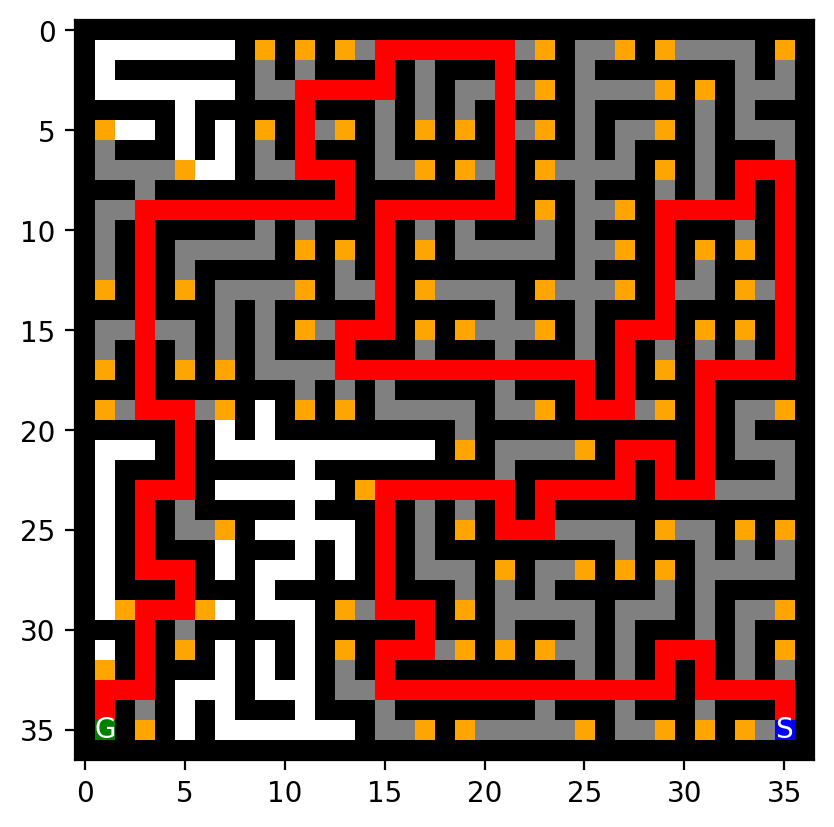

XXXXXXXXXXXX
XG         X
X        X X
XXXXXXXX X X
X      X X X
X    X X X X
X    X X   X
X    X X X X
X    X X X X
XXXX X X X X
XS         X
XXXXXXXXXXXX



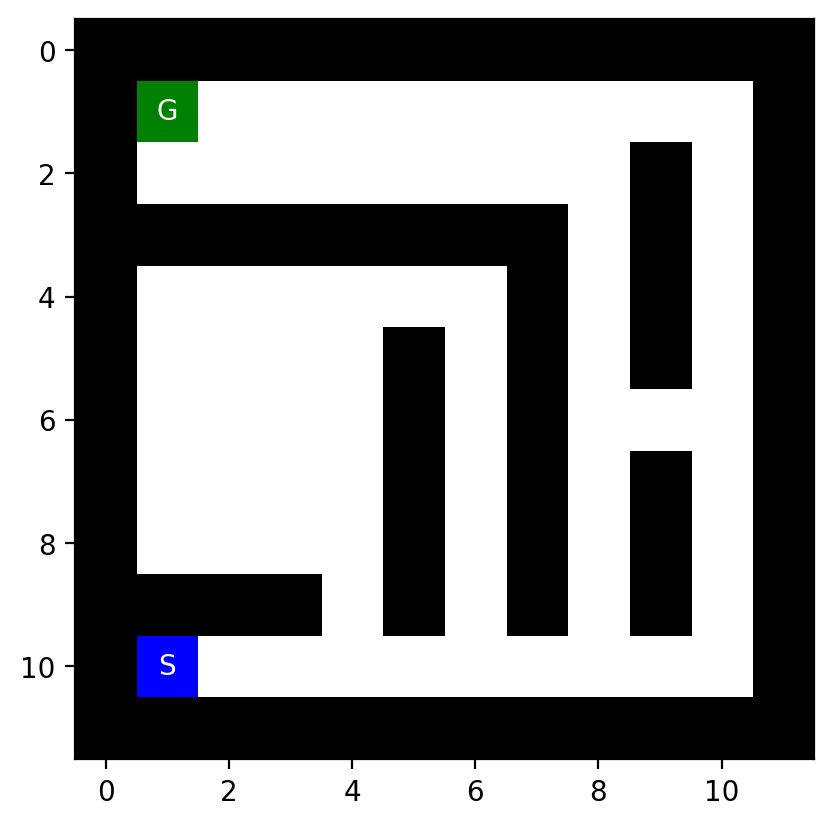

The Maximum Frontier Size is 15
The Maximum Depth of the tree is 23
The cost for the Path is 23
The Maximum tree size is 75
The maximum Branching Factor is  64
Path from origin to target:
(10, 1)
(10, 2)
(10, 3)
(10, 4)
(10, 5)
(10, 6)
(10, 7)
(10, 8)
(9, 8)
(8, 8)
(7, 8)
(6, 8)
(5, 8)
(4, 8)
(3, 8)
(2, 8)
(1, 8)
(1, 7)
(1, 6)
(1, 5)
(1, 4)
(1, 3)
(1, 2)
(1, 1)
Cost: 23


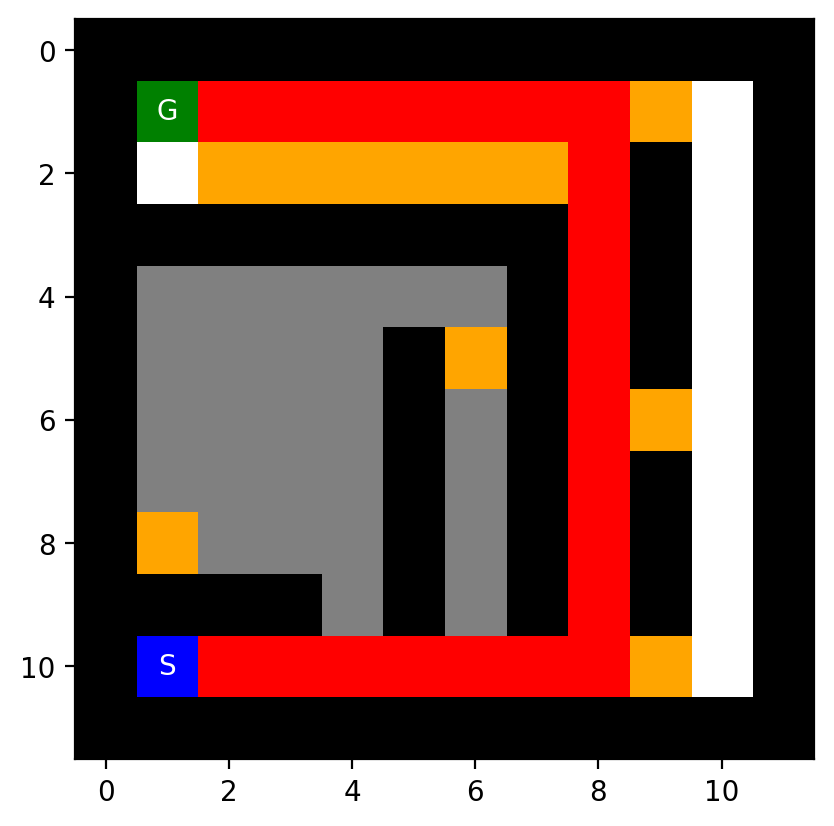

XXXXXXXXXXXX
X          X
X        G X
X          X
X   XXXX   X
X      X   X
X      X   X
X      X   X
X          X
X S        X
X          X
XXXXXXXXXXXX



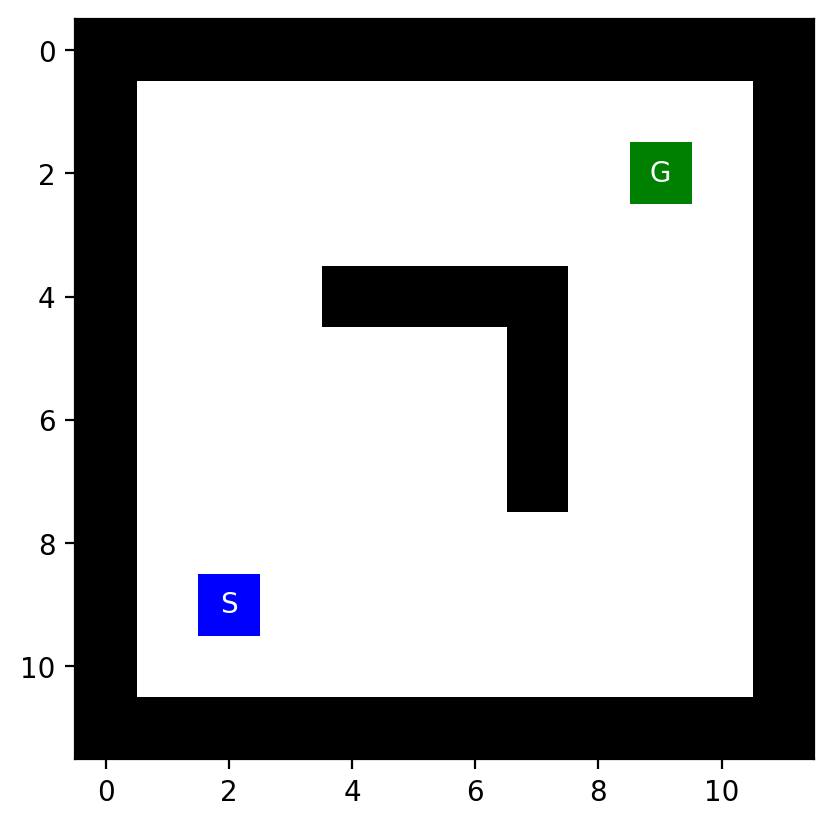

The Maximum Frontier Size is 30
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 44
The maximum Branching Factor is  14
Path from origin to target:
(9, 2)
(8, 2)
(7, 2)
(6, 2)
(5, 2)
(4, 2)
(3, 2)
(2, 2)
(2, 3)
(2, 4)
(2, 5)
(2, 6)
(2, 7)
(2, 8)
(2, 9)
Cost: 14


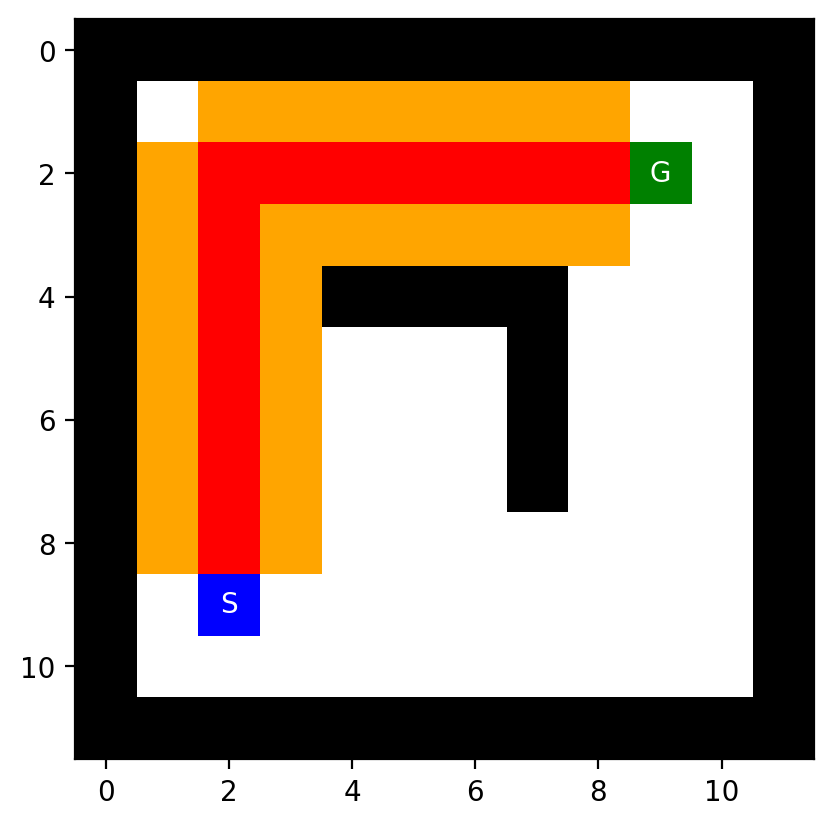

XXXXXXXXXXXX
X          X
X        G X
X          X
X          X
X          X
X          X
X          X
X          X
X S        X
X          X
XXXXXXXXXXXX



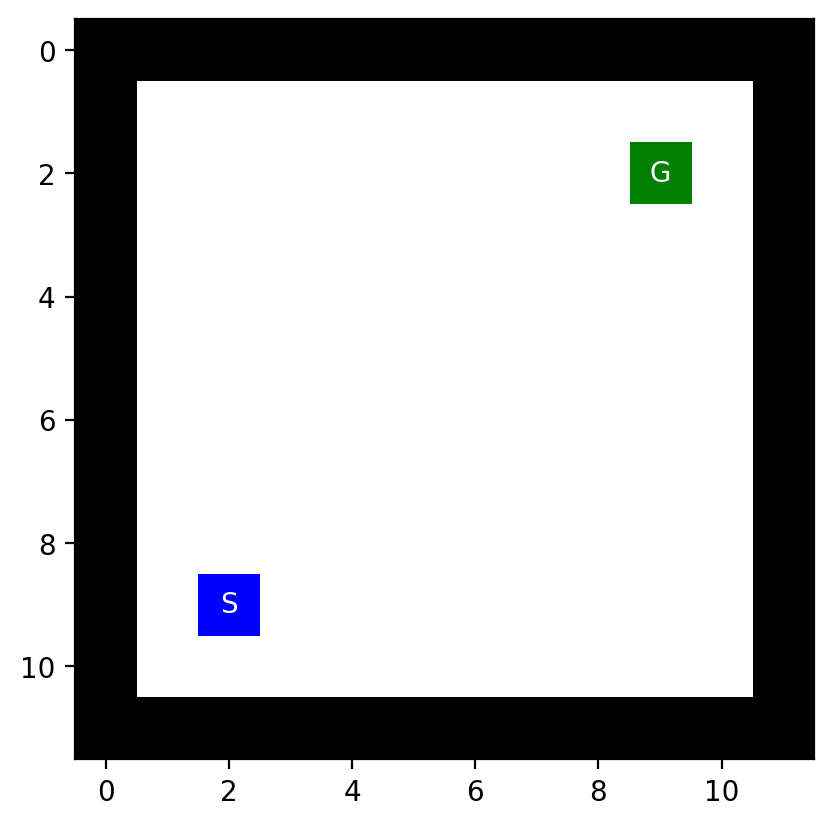

The Maximum Frontier Size is 30
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 44
The maximum Branching Factor is  14
Path from origin to target:
(9, 2)
(8, 2)
(7, 2)
(6, 2)
(5, 2)
(4, 2)
(3, 2)
(2, 2)
(2, 3)
(2, 4)
(2, 5)
(2, 6)
(2, 7)
(2, 8)
(2, 9)
Cost: 14


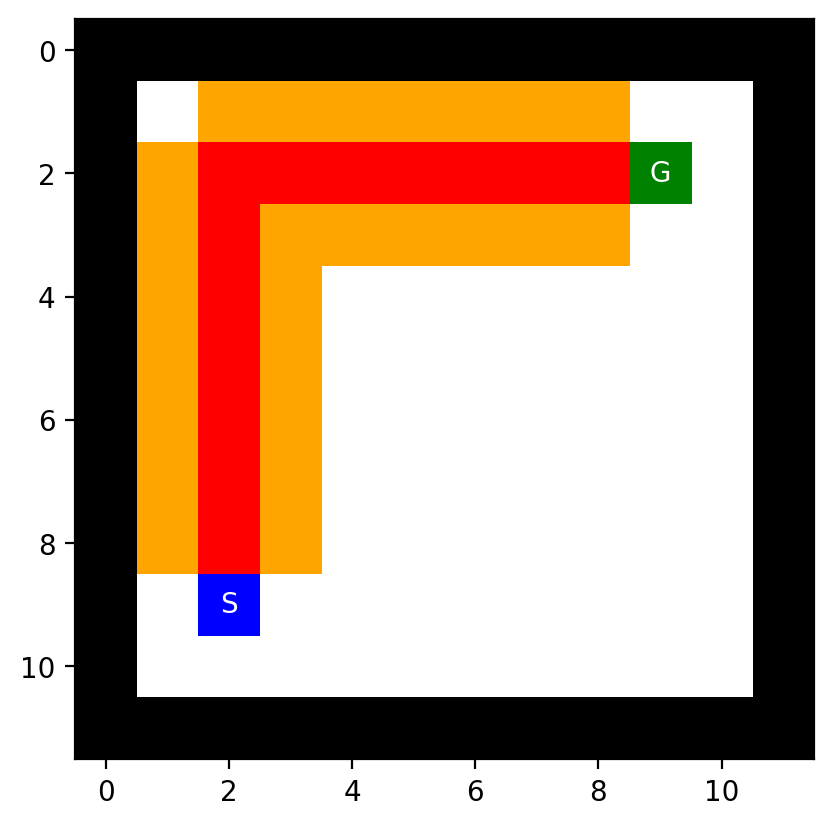

XXXXXXXXXXXX
X          X
X        S X
X          X
X          X
X          X
X          X
X          X
X          X
X G        X
X          X
XXXXXXXXXXXX



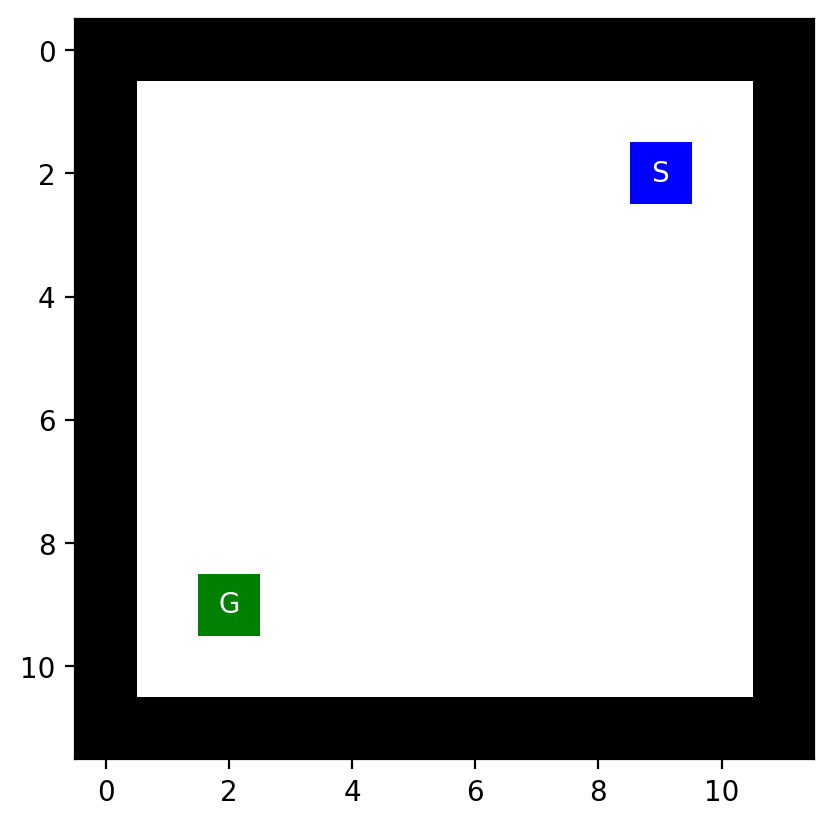

The Maximum Frontier Size is 30
The Maximum Depth of the tree is 14
The cost for the Path is 14
The Maximum tree size is 44
The maximum Branching Factor is  14
Path from origin to target:
(2, 9)
(3, 9)
(4, 9)
(5, 9)
(6, 9)
(7, 9)
(8, 9)
(9, 9)
(9, 8)
(9, 7)
(9, 6)
(9, 5)
(9, 4)
(9, 3)
(9, 2)
Cost: 14


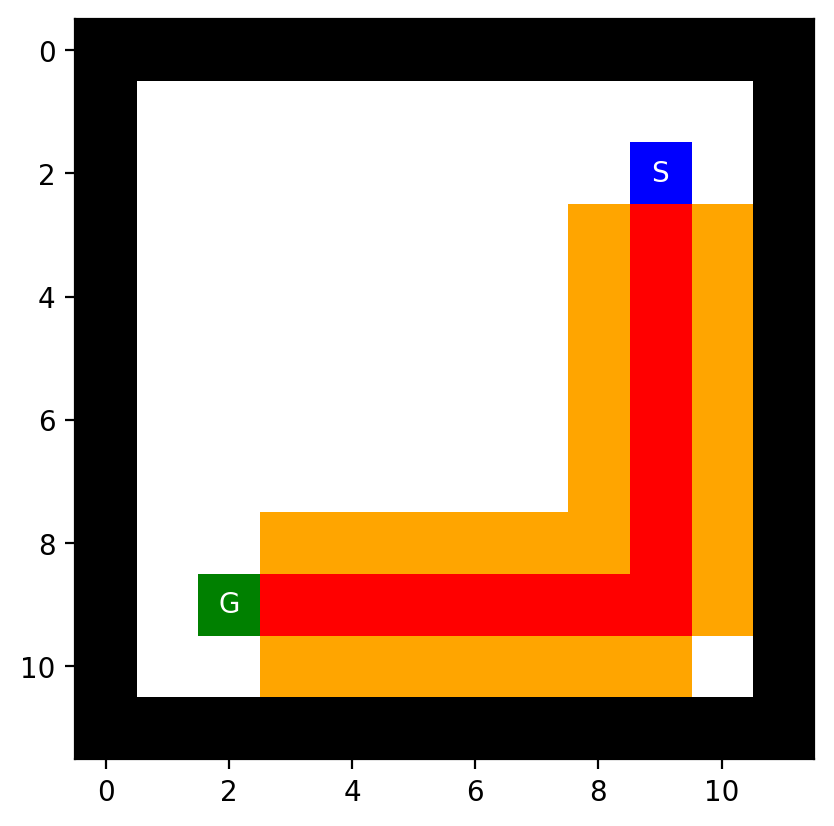

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X                                  SX
X            X                      X
X            X                      X
X            X                      X
X            X                      X
X            X                      X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
X            X      X               X
XXXXXXXXXXXXXX      XXXXXXXXXXXXXXXXX
X            X                      X
X            X                      X
X            X                      X
X                                   X
X                                   X
X                                   X
XG                                  X
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX



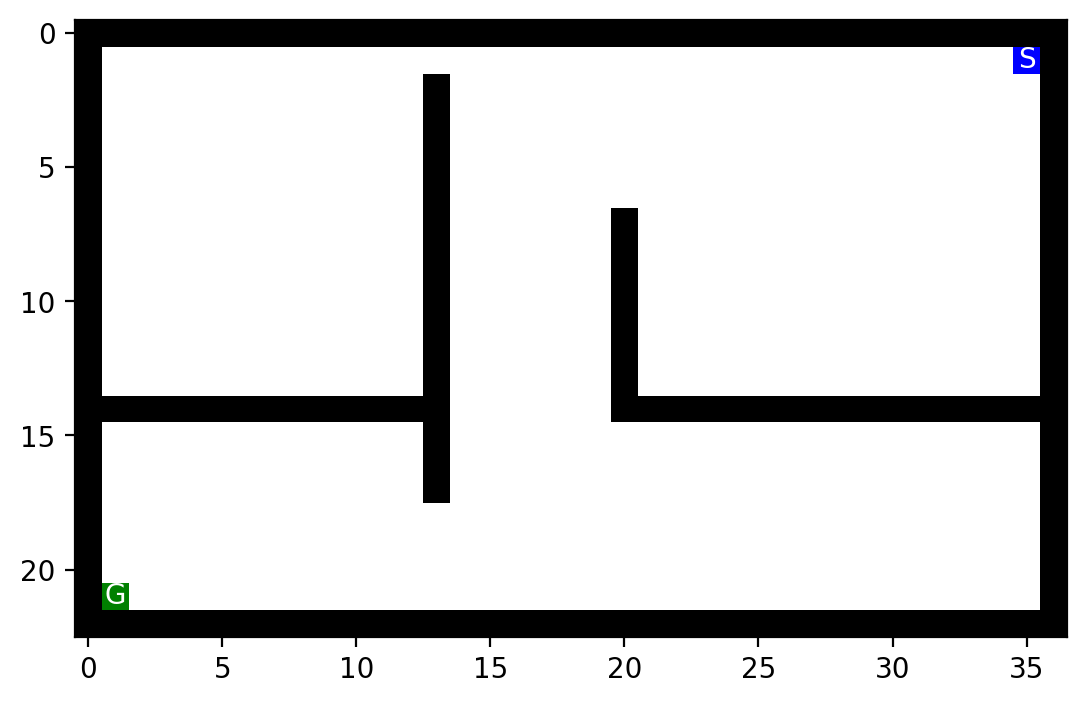

The Maximum Frontier Size is 159
The Maximum Depth of the tree is 54
The cost for the Path is 54
The Maximum tree size is 318
The maximum Branching Factor is  159
Path from origin to target:
(1, 35)
(2, 35)
(3, 35)
(4, 35)
(5, 35)
(6, 35)
(6, 34)
(6, 33)
(6, 32)
(6, 31)
(6, 30)
(6, 29)
(6, 28)
(6, 27)
(6, 26)
(6, 25)
(6, 24)
(6, 23)
(6, 22)
(6, 21)
(6, 20)
(6, 19)
(7, 19)
(8, 19)
(9, 19)
(10, 19)
(11, 19)
(12, 19)
(13, 19)
(14, 19)
(15, 19)
(16, 19)
(17, 19)
(18, 19)
(19, 19)
(20, 19)
(21, 19)
(21, 18)
(21, 17)
(21, 16)
(21, 15)
(21, 14)
(21, 13)
(21, 12)
(21, 11)
(21, 10)
(21, 9)
(21, 8)
(21, 7)
(21, 6)
(21, 5)
(21, 4)
(21, 3)
(21, 2)
(21, 1)
Cost: 54


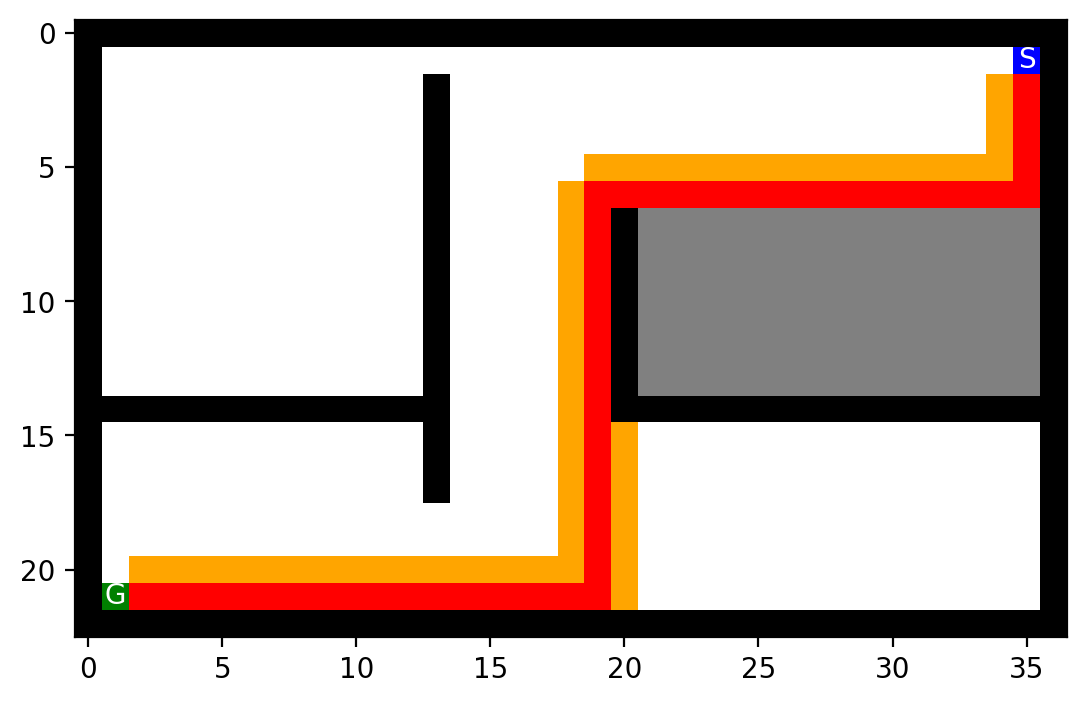

In [23]:
# Your code goes here
# This method gets the vertices for the possible moves available
# vertex contains the vertex for which the adjacent vertices are required
# grid_structure contains the blueprint of the labyrinth/board with all the information
# target contains the coordinates of the target
# possible_moves contains the possible moves that can be performed
def find_adjacent_vertices(vertex, grid_structure, target, possible_moves):
    current_location = vertex.location
    adjacents = []

    # Adding adjacent vertices (north, south, east, west) based on available moves
    for direction in possible_moves.values():
        adjacent_location = (current_location[0] + direction[0], current_location[1] + direction[1])
        if maze_util.look(grid_structure, adjacent_location) != "X":
            adjacents.append(LabyrinthPathVertex(adjacent_location, vertex, direction, vertex.path_length + 1, target=target))

    return adjacents

# This method performs the greedy best-first-search algorithm to find the target.
# labyrinth variable contains the 2d array of a labyrinth-like structure which is referenced in traversing.
# origin contains the origin coordinates, that is, the location to start from.
# destination contains the target coordinates, that is, the location to reach for.
# directions contain the possible moves that an agent/piece can perform.
def greedy_best_first_search(labyrinth, origin, destination, directions):
    # explored contains all the locations that the agent/piece has already covered.
    explored = set()

    # Priority queue is used to arrange the vertices in the queue based on priority metrics
    expansion_priority_queue = PriorityQueue()
    origin_vertex = LabyrinthPathVertex(origin, None, None, 0, target=destination)

    # Estimate variable in the vertex contains the distance of that particular vertex from target and is used to set priority.
    expansion_priority_queue.put((origin_vertex.estimate, origin_vertex))
    steps = 0
    vertex_count = 1
    maximum_depth = 0
    max_branching = 0
    frontier_max_size = expansion_priority_queue.qsize()

    # while the priority queue is not empty, that is, the target is not reached the loop will keep on running.
    while expansion_priority_queue:
        if frontier_max_size < expansion_priority_queue.qsize():
            frontier_max_size = expansion_priority_queue.qsize()

        current_vertex = expansion_priority_queue.get()[1]
        current_location = current_vertex.location

        if current_vertex.path_length > maximum_depth:
            maximum_depth = current_vertex.path_length

        # When the target is reached the loop is forced to end.
        if current_location == destination:
            log_search_metrics(frontier_max_size, maximum_depth, current_vertex.path_length, vertex_count, steps, 'GBFS')
            return current_vertex

        explored.add(current_location)

        # Getting possible moves to perform
        adjacent_vertices = find_adjacent_vertices(current_vertex, labyrinth, destination, directions)

        for adjacent in adjacent_vertices:
            branch_count = 0
            new_location = adjacent.location

            if new_location not in explored:
                expansion_priority_queue.put((adjacent.estimate, adjacent))

                if current_location != origin and current_location != destination and new_location != destination:
                    labyrinth[new_location[0]][new_location[1]] = "F"
                    labyrinth[current_location[0]][current_location[1]] = "."

                vertex_count += 1
                branch_count += 1

                # Tracking maximum branching factor
                if max_branching < branch_count:
                    max_branching = branch_count

        # Printing frame by frame for every step
        # maze_util.show_maze(labyrinth)
        steps = steps + 1

    return None

# This method performs the A* search algorithm to find the target.
# labyrinth variable contains the 2d array of a labyrinth-like structure which is referenced in traversing.
# origin contains the origin coordinates, that is, the location to start from.
# destination contains the target coordinates, that is, the location to reach for.
# directions contain the possible moves that an agent/piece can perform.
def a_star_search(labyrinth, origin, destination, directions):
    # explored contains all the locations that the agent/piece has already covered.
    explored = set()

    # Priority queue is used to arrange the vertices in the queue based on priority metrics
    expansion_priority_queue = PriorityQueue()
    origin_vertex = LabyrinthPathVertex(origin, None, None, 0, target=destination)

    # Estimate variable in the vertex contains the distance of that particular vertex from target and
    # the combination of the estimate and the path_length from the origin vertex is used to set priority.
    expansion_priority_queue.put((origin_vertex.estimate + 0, origin_vertex))

    steps = 0
    vertex_count = 1
    maximum_depth = 0
    max_branching = 0
    frontier_max_size = expansion_priority_queue.qsize()

    # while the priority queue is not empty, that is, the target is not reached the loop will keep on running.
    while expansion_priority_queue:
        if frontier_max_size < expansion_priority_queue.qsize():
            frontier_max_size = expansion_priority_queue.qsize()

        current_vertex = expansion_priority_queue.get()[1]
        current_location = current_vertex.location

        if current_vertex.path_length > maximum_depth:
            maximum_depth = current_vertex.path_length

        # When the target is reached the loop is forced to end.
        if current_location == destination:
            log_search_metrics(frontier_max_size, maximum_depth, current_vertex.path_length, vertex_count, steps, 'ASTAR')
            return current_vertex

        explored.add(current_location)

        # Getting possible moves to perform
        adjacent_vertices = find_adjacent_vertices(current_vertex, labyrinth, destination, directions)

        for adjacent in adjacent_vertices:
            branch_count = 0
            new_location = adjacent.location

            if new_location not in explored:
                expansion_priority_queue.put((adjacent.estimate + adjacent.path_length, adjacent))

                if current_location != origin and current_location != destination and new_location != destination:
                    labyrinth[new_location[0]][new_location[1]] = "F"
                    labyrinth[current_location[0]][current_location[1]] = "."

                vertex_count += 1
                branch_count += 1

                # Tracking maximum branching factor
                if max_branching < branch_count:
                    max_branching = branch_count

        steps = steps + 1
        # maze_util.show_maze(labyrinth)

    return None

def run_all_advanced_labyrinths():
    global current_labyrinth

    labyrinth_files = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "loops_maze.txt",
                      "wall_maze.txt", "empty_maze.txt", "empty_2_maze.txt", "open_maze.txt"]

    # Run Greedy Best-First Search on all labyrinths
    for maze_file in labyrinth_files:
        current_labyrinth = maze_file[:maze_file.find(".")]

        # Getting the text file and parsing the labyrinth from it as a 2d matrix
        with open(maze_file, "r") as file:
            labyrinth_str = file.read()
            print(labyrinth_str)

            parsed_labyrinth = maze_util.parse_maze(labyrinth_str)
            maze_util.show_maze(parsed_labyrinth)
            execute_search_algorithm(parsed_labyrinth, "GBFS")

    # Run A* Search on all labyrinths
    for maze_file in labyrinth_files:
        current_labyrinth = maze_file[:maze_file.find(".")]

        # Getting the text file and parsing the labyrinth from it as a 2d matrix
        with open(maze_file, "r") as file:
            labyrinth_str = file.read()
            print(labyrinth_str)

            parsed_labyrinth = maze_util.parse_maze(labyrinth_str)
            maze_util.show_maze(parsed_labyrinth)
            execute_search_algorithm(parsed_labyrinth, "ASTAR")

# Start the execution of advanced search algorithms
run_all_advanced_labyrinths()

Are your implementations complete and optimal? What is the time and space complexity?

In [25]:
# # Discussion
# The A* algorithm provides both completeness and optimality guarantees, while greedy best-first search ensures completeness but cannot guarantee optimal solutions.

# For both algorithms, the worst-case space and time complexities are O(N), as they selectively evaluate which locations to explore and incorporate only viable vertices into the search tree.

## Task 4: Comparison and discussion [20 Points]

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [24]:
# Add code
def display_metrics_summary():
    global result_collection

    results_dataframe = pd.DataFrame(result_collection, columns=[
        'labyrinth',
        'search_algorithm',
        'frontier_max_size',
        'maximum_tree_depth',
        'solution_path_length',
        'total_vertices_explored',
        'exploration_steps'
    ])

    display(results_dataframe.groupby(['search_algorithm', 'labyrinth']).mean())
    # display(results_dataframe)

    return results_dataframe

analysis_results = display_metrics_summary()

frontier_max_size  maximum_tree_depth  \
search_algorithm labyrinth                                             
ASTAR            empty_2_maze               30.0                14.0   
                 empty_maze                 30.0                14.0   
                 large_maze                 13.0               210.0   
                 loops_maze                 15.0                23.0   
                 medium_maze                 8.0                68.0   
                 open_maze                 159.0                54.0   
                 small_maze                  8.0                19.0   
                 wall_maze                  30.0                14.0   
BFS              empty_2_maze             9438.0                14.0   
                 empty_maze               9438.0                14.0   
                 large_maze                  8.0               210.0   
                 loops_maze                 39.0                23.0   
                 medium_maze                 9.0                68.0   
                 small_maze                  9.0                19.0   
                 wall_maze                 422.0                14.0   
DFS              empty_2_maze               75.0                70.0   
                 empty_maze                 74.0                74.0   
                 large_maze                 38.0               222.0   
                 loops_maze                 12.0                27.0   
                 medium_maze                 9.0               130.0   
                 open_maze                 330.0               298.0   
                 small_maze                  7.0                49.0   
                 wall_maze                  59.0                70.0   
GBFS             empty_2_maze               30.0                14.0   
                 empty_maze                 30.0                14.0   
                 large_maze                 22.0               210.0   
                 loops_maze                 21.0                23.0   
                 medium_maze                 5.0                74.0   
                 open_maze                 203.0                68.0   
                 small_maze                  5.0                29.0   
                 wall_maze                  30.0                14.0   

                               solution_path_length  total_vertices_explored  \
search_algorithm labyrinth                                                     
ASTAR            empty_2_maze                  14.0                     44.0   
                 empty_maze                    14.0                     44.0   
                 large_maze                   210.0                    547.0   
                 loops_maze                    23.0                     75.0   
                 medium_maze                   68.0                    232.0   
                 open_maze                     54.0                    318.0   
                 small_maze                    19.0                     57.0   
                 wall_maze                     14.0                     44.0   
BFS              empty_2_maze                  14.0                  22978.0   
                 empty_maze                    14.0                  22978.0   
                 large_maze                   210.0                    623.0   
                 loops_maze                    23.0                    213.0   
                 medium_maze                   68.0                    278.0   
                 small_maze                    19.0                     96.0   
                 wall_maze                     14.0                   1726.0   
DFS              empty_2_maze                  70.0                    145.0   
                 empty_maze                    74.0                    155.0   
                 large_maze                   210.0                    428.0   
                 loops_maze                    27.0   

Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |           |                |                |               |                   |
| DFS       |           |                |                |               |                   |
| GBS       |           |                |                |               |                   |
| A*        |           |                |                |               |                   |

__Medium Maze__

...

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)).

<ipython-input-26-b8318c7af6fd>:8: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  visualization = sns.barplot(


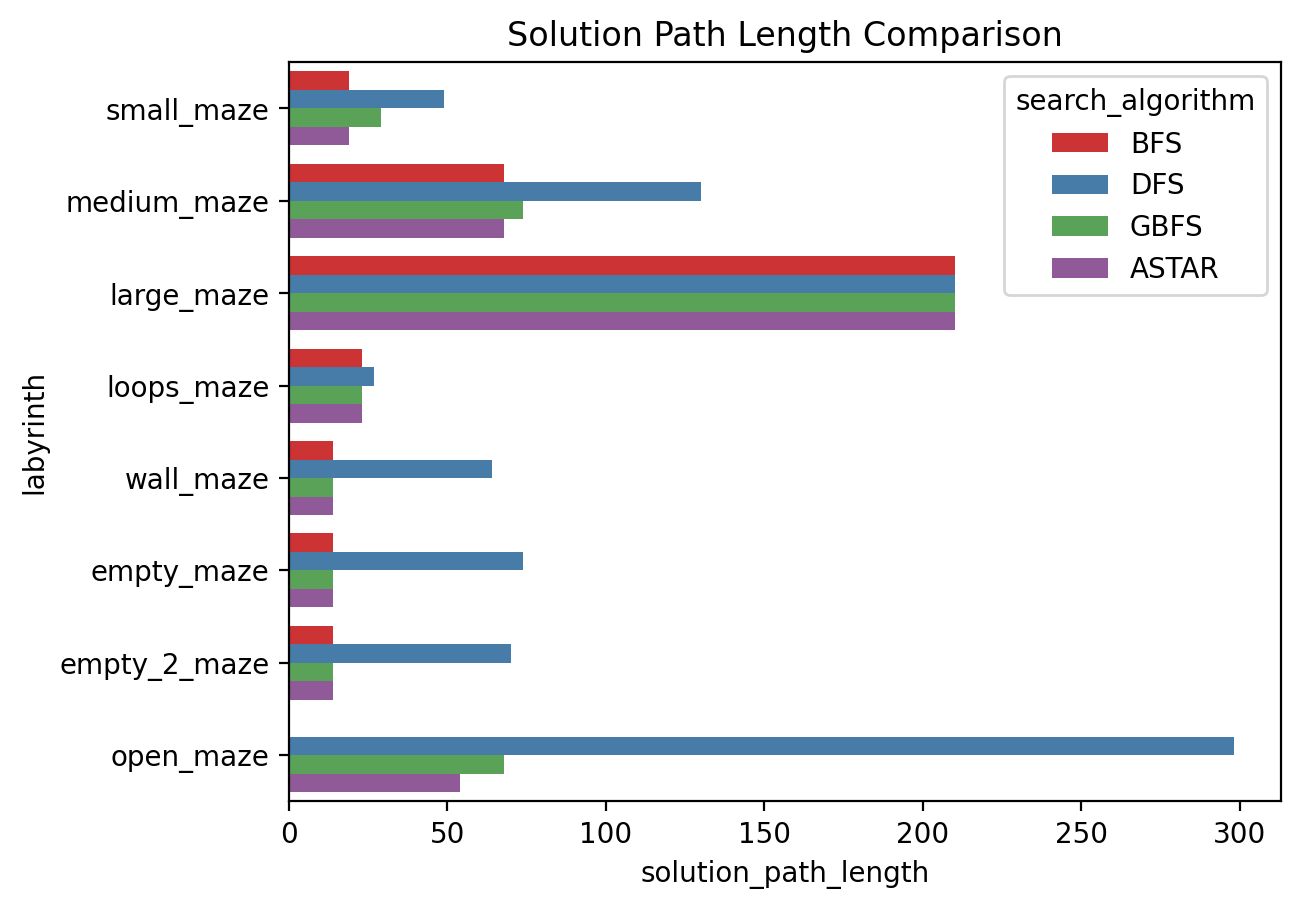

In [26]:
# Add charts
# Add visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Create horizontal bar chart comparing solution paths across labyrinths
# plt.figure(figsize=(20, 5))
visualization = sns.barplot(
    x="solution_path_length",
    y="labyrinth",
    data=analysis_results,
    hue='search_algorithm',
    palette=sns.color_palette("Set1"),
    orient='h'
)
visualization.set_title('Solution Path Length Comparison')
plt.show()

<ipython-input-28-768076a828be>:8: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  visualization = sns.barplot(


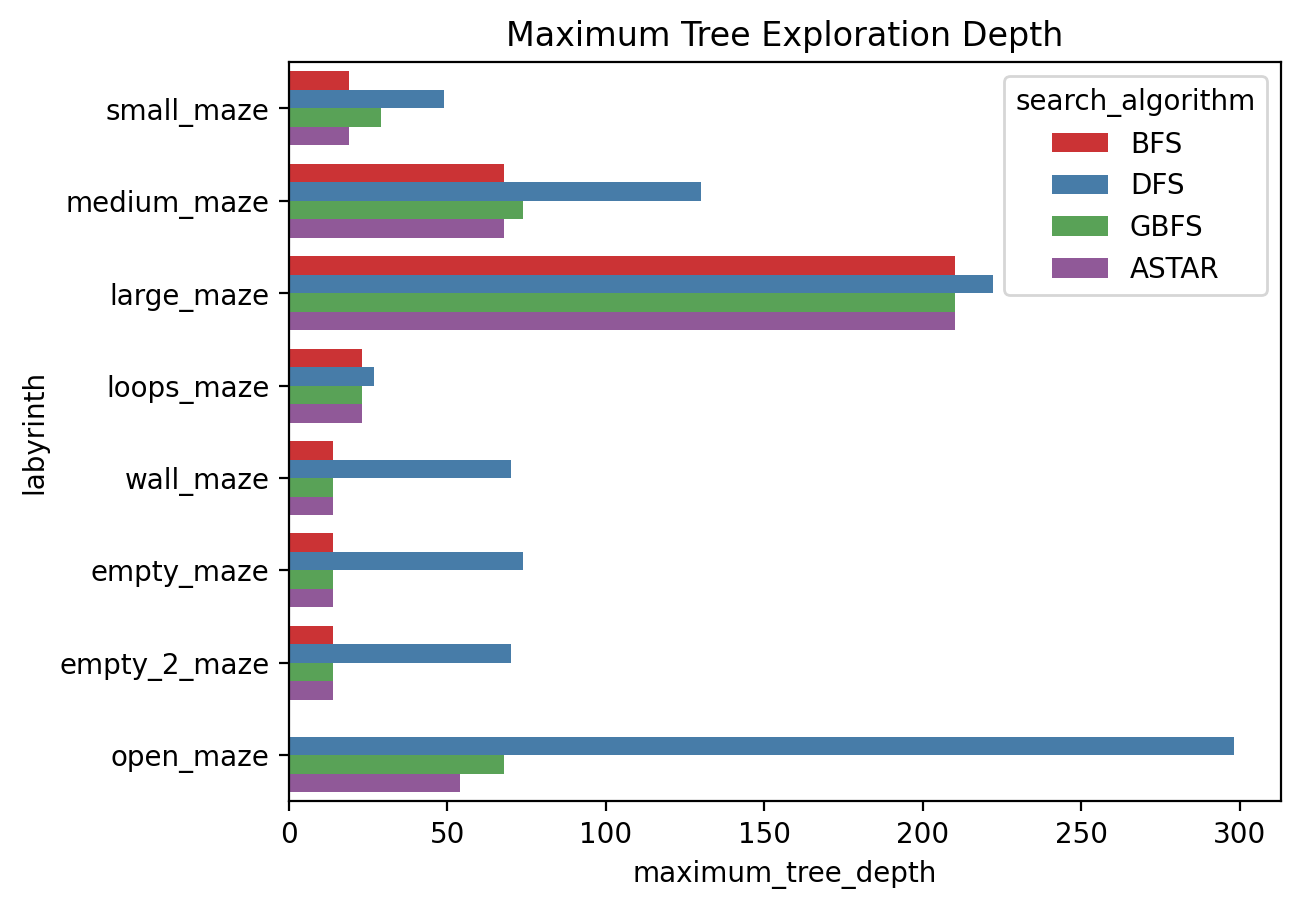

In [28]:
# Add discussion
# Add visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Create horizontal bar chart comparing maximum tree depths across labyrinths
# plt.figure(figsize=(20, 5))
visualization = sns.barplot(
    x="maximum_tree_depth",
    y="labyrinth",
    data=analysis_results,
    hue='search_algorithm',
    palette=sns.color_palette("Set1"),
    orient='h'
)
visualization.set_title('Maximum Tree Exploration Depth')
plt.show()

<ipython-input-29-ad818893ebba>:6: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  visualization = sns.barplot(


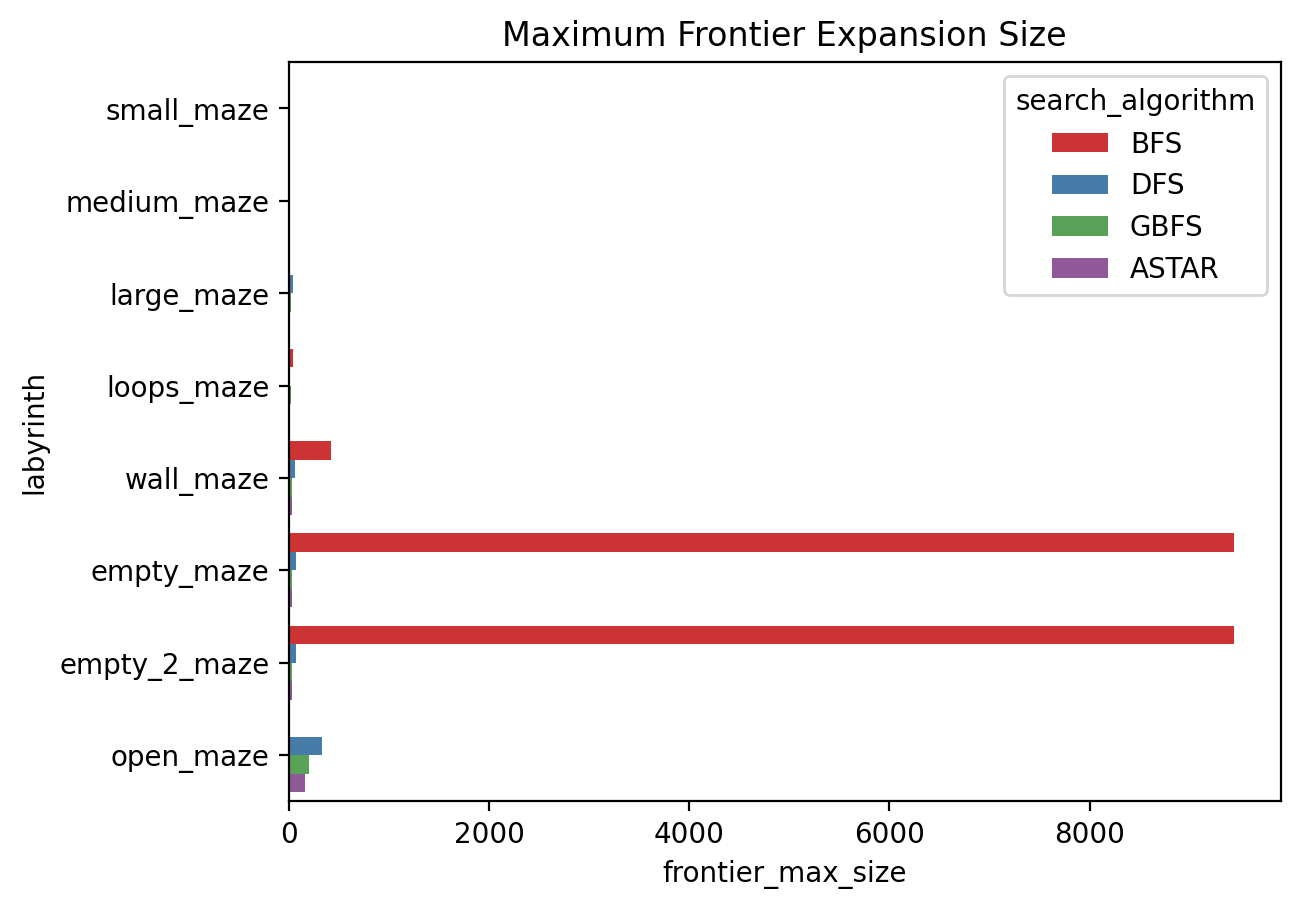

In [29]:
# Add visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Create horizontal bar chart comparing maximum frontier sizes across labyrinths
visualization = sns.barplot(
    x="frontier_max_size",
    y="labyrinth",
    data=analysis_results,
    hue='search_algorithm',
    palette=sns.color_palette("Set1"),
    orient='h'
)
visualization.set_title('Maximum Frontier Expansion Size')
plt.show()

Discuss the most important lessons you have learned from implementing the different search strategies.

In [ ]:
# All these traversal algorithms demonstrate systematic approaches to navigating through complex problem spaces.
# While the A* algorithm appears to provide optimal solutions,
# Other strategies maintain their value and effectiveness in different application contexts and should not be considered inferior.

## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issus, then report and discuss what causes the problems.

In [ ]:
# Your code/answer goes here
# The following pseudocode outline is commented to ensure successful execution of the main program:
# To manage multiple targets within a labyrinth, an array of all target locations can be implemented
#def locate_targets(labyrinth):
#    destinations = []
#    while "G" in labyrinth:
#        coordinate = maze_util.find_pos(labyrinth, what = "G")
#        labyrinth[coordinate[0]][coordinate[1]] = "."
#        destinations.append(coordinate)
#    for location in destinations:
#        labyrinth[location[0]][location[1]] = "G"

# For breadth-first traversal with multiple targets, two strategies are viable:
# First approach: Allow the algorithm to explore the entire labyrinth until all accessible spaces are examined
# and then derive paths based on the destinations list and visualize accordingly.
# Second approach: Modify the target location and execute the algorithms repeatedly as outlined below:

#def multi_target_breadth_first_search(labyrinth, origin, destinations, possible_moves, origin_vertex):
#    # Here destinations will be the array of targets
#    solution_vertex_collection = []
#    for destination in destinations:
#        # All initializations would be placed here
#        # while expansion_queue:
#            # current_vertex = expansion_queue.pop()
#            # if current_vertex.location == destination.location:
#                # solution_vertex_collection.append(destination)
#            # explored.add(current_vertex)
#            # for direction in possible_moves:
#                # Code implementing breadth-first search logic
#
#    # The solution_vertex_collection would then be used to trace paths to all targets
#    # A similar approach would apply to depth-first search with appropriate modifications

# Due to time constraints, this pseudocode framework is what can be provided. With adequate development time and implementation, this approach would function effectively

### Multiple Goals
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

In [ ]:
# # Your code/answer goes here
# # Finding the Optimal Path to One of Multiple Goals: Comparing BFS, DFS, and IDS

# To solve this problem, I would implement the following approach:

# ## 1. Creating Multi-Goal Mazes

# First, I would modify the medium maze by adding additional goal markers:

# ```python
# def create_multi_goal_maze(maze_file="medium_maze.txt", num_additional_goals=2):
#     with open(maze_file, "r") as f:
#         maze_str = f.read()

#     maze = maze_util.parse_maze(maze_str)
#     original_goal = maze_util.find_pos(maze, what="G")

#     # Find empty spaces that are not too close to the original goal
#     empty_spaces = []
#     for i in range(len(maze)):
#         for j in range(len(maze[0])):
#             if maze[i][j] == " " and manhattan_distance((i, j), original_goal) > 5:
#                 empty_spaces.append((i, j))

#     # Randomly select locations for additional goals
#     import random
#     additional_goals = random.sample(empty_spaces, min(num_additional_goals, len(empty_spaces)))

#     # Place additional goals
#     for goal_pos in additional_goals:
#         maze[goal_pos[0]][goal_pos[1]] = "G"

#     return maze, [original_goal] + additional_goals
# ```

# ## 2. Modifying Search Algorithms

# For BFS, DFS, and implementing IDS, I would modify the goal check to terminate when any goal is found:

# ### BFS Modification

# ```python
# def maze_bfs_multi_goal(labyrinth, origin, possible_moves, origin_vertex):
#     explored = set()
#     expansion_queue = [origin_vertex]
#     # ... initialization code ...

#     while expansion_queue:
#         current_vertex = expansion_queue.pop(0)
#         current_location = current_vertex.location

#         # Check if any goal is reached
#         if maze_util.look(labyrinth, current_location) == "G":
#             log_search_metrics(frontier_max_size, maximum_depth, current_vertex.path_length,
#                              vertex_count, steps, 'BFS-MultiGoal')
#             return current_vertex

#         # ... rest of BFS implementation ...
# ```

# ### DFS Modification

# ```python
# def maze_dfs_multi_goal(labyrinth, origin, possible_moves, origin_vertex):
#     explored = set()
#     expansion_stack = [origin_vertex]
#     # ... initialization code ...

#     while expansion_stack:
#         current_vertex = expansion_stack.pop()
#         current_location = current_vertex.location

#         # Check if any goal is reached
#         if maze_util.look(labyrinth, current_location) == "G":
#             log_search_metrics(frontier_max_size, maximum_depth, current_vertex.path_length,
#                              vertex_count, steps, 'DFS-MultiGoal')
#             return current_vertex

#         # ... rest of DFS implementation ...
# ```

# ### Implement IDS (Iterative Deepening Search)

# ```python
# def maze_ids_multi_goal(labyrinth, origin, possible_moves, origin_vertex):
#     max_depth = 0
#     vertex_count = 0
#     frontier_max_size = 0
#     steps = 0

#     # Iteratively increase depth limit
#     while True:
#         result, metrics = depth_limited_search(labyrinth, origin, possible_moves,
#                                              origin_vertex, depth_limit=max_depth)

#         vertex_count += metrics['vertices']
#         frontier_max_size = max(frontier_max_size, metrics['frontier'])
#         steps += metrics['steps']

#         if result is not None:  # Goal found
#             log_search_metrics(frontier_max_size, max_depth, result.path_length,
#                              vertex_count, steps, 'IDS-MultiGoal')
#             return result

#         max_depth += 1
# ```

# ## 3. Running Experiments

# I would run each algorithm on the multi-goal mazes and compare metrics like:
# - Path length (to determine optimality)
# - Number of nodes explored
# - Maximum frontier size
# - Time taken

# ## 4. Analysis of Results

# ### Expected Results:

# 1. **BFS**:
#    - Will find the closest goal as it explores level by level
#    - Guarantees optimal solution (shortest path to any goal)
#    - Higher memory usage due to frontier size

# 2. **DFS**:
#    - May find a goal quickly if it happens to search in the right direction first
#    - Not guaranteed to find the closest goal
#    - Solution may be far from optimal
#    - Lower memory requirements

# 3. **IDS**:
#    - Combines advantages of DFS (low memory) and BFS (optimality)
#    - Will find the closest goal (like BFS)
#    - Revisits nodes multiple times, increasing computation time
#    - Guarantees optimal solution with lower memory requirements than BFS

# ### Discussion:

# BFS will consistently find the optimal solution because it explores nodes in order of their distance from the starting point. When dealing with multiple goals, it ensures that the first goal encountered is the closest one.

# DFS often performs poorly in terms of optimality when searching for the closest goal. Since it explores deeply along each path before backtracking, it could find a distant goal before discovering a much closer one.

# IDS combines the benefits of both approaches. It will find the optimal solution like BFS, but with lower memory requirements. It does this by running a series of depth-limited DFS searches with increasing depth limits. This ensures that shallow goals are found before deeper ones.

# The trade-off is that IDS will reexplore nodes multiple times, potentially increasing the overall computation time. However, in scenarios with limited memory or where the closest goal is expected to be relatively near, IDS can be the most efficient choice.

# In maze environments with sparse goals, BFS would likely be the preferred algorithm due to its guaranteed optimality and efficiency in finding the closest goal. However, in very large mazes with memory constraints, IDS would be more appropriate despite its potential computational overhead.

## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment.

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [ ]:
# # Your code/answer goes here
# To make BFS and iterative deepening search (IDS) optimal when using intersections as states with varying path lengths between them, we need to modify how these algorithms handle path costs.

# ## The Intersection-as-States Approach

# When we define only intersections as states:
# 1. We significantly reduce the state space (fewer nodes to explore)
# 2. But the edges between intersections have varying costs (different path lengths)

# ## Making BFS and IDS Optimal

# The key insight is that BFS and IDS are only optimal when all edge costs are uniform. When path lengths between intersections vary, we need to adapt these algorithms:

# ### For BFS:
# BFS is no longer automatically optimal because it expands nodes in order of their depth (number of edges from start), not their path cost. To make BFS optimal:

# 1. Replace the standard queue with a priority queue
# 2. Sort by cumulative path length rather than by depth
# 3. This effectively transforms BFS into Uniform Cost Search (UCS)

# ```python
# def intersection_bfs(maze, start, goal):
#     # Priority queue ordered by path length, not just depth
#     frontier = PriorityQueue()
#     frontier.put((0, IntersectionNode(start, None, None, 0)))
#     explored = set()

#     while not frontier.empty():
#         path_length, current = frontier.get()

#         if current.position == goal:
#             return current  # Goal found

#         if current.position not in explored:
#             explored.add(current.position)

#             # For each neighbor intersection
#             for neighbor, segment_length in get_adjacent_intersections(maze, current.position):
#                 if neighbor not in explored:
#                     # Add total path length to get there
#                     new_path_length = current.path_length + segment_length
#                     new_node = IntersectionNode(neighbor, current, None, new_path_length)
#                     frontier.put((new_path_length, new_node))
# ```

# ### For IDS:
# IDS needs to be modified to consider path length, not just depth:

# 1. Implement a depth-limited search that tracks path length
# 2. Iteratively increase the path length limit (not just depth limit)
# 3. This becomes an Iterative Lengthening Search instead

# ```python
# def intersection_ids(maze, start, goal):
#     max_path_length = 0

#     while True:
#         result = length_limited_search(maze, start, goal, max_path_length)
#         if result:
#             return result
#         max_path_length += 1  # Increase path length limit

# def length_limited_search(maze, start, goal, max_path_length):
#     stack = [(IntersectionNode(start, None, None, 0))]
#     explored = set()

#     while stack:
#         current = stack.pop()

#         if current.position == goal:
#             return current

#         if current.position not in explored:
#             explored.add(current.position)

#             # Only explore if path length would remain under limit
#             if current.path_length < max_path_length:
#                 neighbors = []
#                 for neighbor, segment_length in get_adjacent_intersections(maze, current.position):
#                     if neighbor not in explored:
#                         new_path_length = current.path_length + segment_length
#                         if new_path_length <= max_path_length:
#                             neighbors.append((neighbor, segment_length))

#                 # Add neighbors in reverse order for DFS
#                 for neighbor, segment_length in reversed(neighbors):
#                     new_node = IntersectionNode(neighbor, current, None, current.path_length + segment_length)
#                     stack.append(new_node)

#     return None  # No path found within limit
# ```

# ### Helper Function to Find Intersection Paths

# We also need to identify intersections and calculate path lengths between them:

# ```python
# def get_adjacent_intersections(maze, position):
#     # An intersection is a position with more than 2 available directions
#     # Returns list of (adjacent_intersection_position, path_length)

#     directions = [(0,1), (1,0), (0,-1), (-1,0)]  # E, S, W, N
#     adjacent_intersections = []

#     for direction in directions:
#         # Follow corridor until reaching an intersection or dead end
#         current = position
#         path_length = 0

#         while True:
#             next_pos = (current[0] + direction[0], current[1] + direction[1])

#             # Check if valid move
#             if maze[next_pos[0]][next_pos[1]] == "X":  # Wall
#                 break

#             current = next_pos
#             path_length += 1

#             # Count available directions at current position
#             available_directions = sum(1 for d in directions
#                               if maze[current[0] + d[0]][current[1] + d[1]] != "X")

#             # If intersection found, add to list and stop following this path
#             if available_directions > 2 or available_directions == 1:
#                 adjacent_intersections.append((current, path_length))
#                 break

#     return adjacent_intersections
# ```

# ## Why This Works

# With these changes:
# - BFS becomes Uniform Cost Search, which is optimal when costs are non-negative
# - IDS becomes Iterative Lengthening Search, which is optimal because it finds the lowest-cost path before considering longer ones
# - Both algorithms consider the true path length rather than just the number of intersections

# The key insight is that we're changing what these algorithms prioritize. Instead of expanding based on the number of edges (intersections) from the start, we expand based on the total path length, which makes them optimal even with varying edge costs.

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [ ]:
# Your code/answer goes here
# Incorporating weighted edges or pre-established transition costs into the A* algorithm would significantly impact its heuristic calculations and consequently alter the resulting solution paths
# This occurs because the transition costs serve as the primary decision factors for A* when determining which adjacent location to explore next

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [ ]:
# Your code/answer goes here
# The autonomous entity would rely on its obstacle detection system and proceed in any accessible direction, even if that particular location has been previously explored
# Since it lacks comprehensive knowledge of the environment's structure or dimensions, it will continue its exploration sequence until either the destination is discovered or its energy reserves are depleted